In [6]:
import os
import math
import logging
import pickle

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely import wkt
from shapely.geometry import Point

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM  # Assuming these might be used later from original imports
from peft import PeftModel


In [2]:
gdf = gpd.read_parquet("POI_encoded_embeddings.parquet")

In [3]:
gdf

,label_pair,z,geometry,cat_name,cat_count,weight,hex_id
0,Activities Related to Real Estate[sep]Resident...,"[61.499184, 25.730932, 28.544409, 16.33576, 38...",POINT (-82.52482 27.94908),Activities Related to Real Estate,24,576,33561
1,Offices of Real Estate Agents and Brokers[sep]...,"[10.239435, 8.276576, 44.785103, 72.61034, 19....",POINT (-81.38077 30.19916),Offices of Real Estate Agents and Brokers,107,11449,52159
2,"Sporting Goods, Hobby, and Musical Instrument ...","[23.133112, 20.673256, 16.964842, 24.288828, 2...",POINT (-81.76929 24.5666),"Sporting Goods, Hobby, and Musical Instrument ...",7,49,44888
3,Offices of Dentists[sep]Offices of Dentists,"[21.774567, 62.81708, 77.10956, 94.822975, 61....",POINT (-81.68255 30.20312),Offices of Dentists,70,4900,46628
4,"Museums, Historical Sites, and Similar Institu...","[48.68053, 51.811516, -0.24616693, 46.184406, ...",POINT (-81.84711 26.64202),"Museums, Historical Sites, and Similar Institu...",8,64,43514
...,...,...,...,...,...,...,...
1548012,Home Furnishings Stores[sep]All Other Home Fur...,"[33.14433, -0.046613265, 46.66763, 36.16918, 2...",POINT (-81.42641 29.78401),Home Furnishings Stores,1,1,51477
1548013,Urban Transit Systems[sep]Bus and Other Motor ...,"[10.560505, 53.101013, 18.382906, 5.375622, 64...",POINT (-81.07024 29.21795),Urban Transit Systems,16,256,56590
1548014,Urban Transit Systems[sep]Bus and Other Motor ...,"[5.115786, 64.99983, 25.311647, 19.811197, 78....",POINT (-81.32279 29.04255),Urban Transit Systems,8,64,52995
1548015,Urban Transit Systems[sep]Bus and Other Motor ...,"[13.166652, 72.90378, 16.78043, -0.050964173, ...",POINT (-81.01938 29.24983),Urban Transit Systems,30,900,57118


In [7]:

# 2) Expand the `z` list/array into its own DataFrame of shape (N, D)
#    so each dimension becomes a column z0, z1, ..., z{D-1}
z_expanded = pd.DataFrame(
    gdf["z"].tolist(),
    index=gdf.index
)
z_expanded.columns = [f"z{i}" for i in range(z_expanded.shape[1])]

# 3) Combine back with the labels
df_expanded = pd.concat([gdf["label_pair"], z_expanded], axis=1)

# 4) Group by label_pair and take the mean → this is your “center” per class
centers_df = df_expanded.groupby("label_pair").mean()

In [8]:

CONFIG = {
    # File Paths
    "HEX_FILE_PATH": "Hex_tesse_raw.parquet",
    "POI_FILE_PATH": "Hull_FL_poi_vec_subset.csv",
    "CHECKPOINT_PATH": "bottleneck_mlp_newdata.pth",
    "OUTPUT_PATH": "POI_encoded_embeddings.parquet",
    
    # Coordinate Reference Systems
    "CRS_GEOGRAPHIC": "EPSG:4326",
    "CRS_PROJECTED": "EPSG:5070",  # Using an equal-area projection for the US
    
    # Model Hyperparameters
    "LATENT_DIM": 64,
    "HIDDEN_DIM": 256,
    
    # Training Hyperparameters
    "BATCH_SIZE": 128,
    "LEARNING_RATE": 1e-4,
    "EPOCHS": 40,
    
    # System Configuration
    "DEVICE": torch.cuda,
    "NUM_WORKERS": 4,
}

# ─── PyTorch Model Definition ────────────────────────────────────────────────

class BottleneckMLP(nn.Module):
    """A Bottleneck Multi-Layer Perceptron for dimensionality reduction and classification."""
    def __init__(self, in_dim, hid_dim, lat_dim, n_cls):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(hid_dim, lat_dim),
            nn.LeakyReLU(0.01, inplace=True)
        )
        self.head = nn.Linear(lat_dim, n_cls)

    def forward(self, x):
        z = self.encoder(x)
        logits = self.head(z)
        return z, logits

# ─── Data Loading and Preprocessing Functions ────────────────────────────────

def load_hexagon_data(file_path, crs):
    """Loads and preprocesses the hexagon GeoDataFrame."""
    logging.info(f"Loading hexagon data from {file_path}...")
    hex_gdf = pd.read_parquet(file_path)
    hex_gdf = hex_gdf.reset_index(drop=True)
    hex_gdf["hex_id"] = hex_gdf.index.astype(str)
    hex_gdf["geometry"] = gpd.GeoSeries.from_wkb(hex_gdf["geometry"])
    hex_gdf = gpd.GeoDataFrame(hex_gdf, geometry="geometry", crs=crs)
    logging.info(f"Hexagon data loaded with {len(hex_gdf)} hexagons.")
    return hex_gdf

def load_poi_data(file_path, crs):
    """Loads and preprocesses the POI GeoDataFrame."""
    logging.info(f"Loading POI data from {file_path}...")
    table = pv.read_csv(
        file_path,
        read_options=ReadOptions(block_size=1 << 20),
        parse_options=ParseOptions(delimiter=",", quote_char='"', newlines_in_values=True)
    )
    df = table.to_pandas()
    df["geometry"] = df["geometry"].apply(wkt.loads)
    poi_gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=crs)
    logging.info(f"POI data loaded with {len(poi_gdf)} points.")
    return poi_gdf

def parse_vector_column(series: pd.Series) -> np.ndarray:
    """Parses a string representation of vectors into a stacked NumPy array."""
    logging.info("Parsing string vectors into NumPy array...")
    def parse_vec(s: str) -> np.ndarray:
        if isinstance(s, (list, np.ndarray)):
            return np.array(s, dtype=np.float32)
        return np.fromstring(s.strip("[]"), sep=" ", dtype=np.float32)
    
    vecs = np.stack(series.map(parse_vec).values)
    return vecs

# ─── Model Training and Inference Functions ──────────────────────────────────

def train_or_load_model(config, loader, n_classes, class_labels):
    """Instantiates the model and optimizer, then loads from checkpoint or trains."""
    logging.info("Initializing model, optimizer, and criterion...")
    model = BottleneckMLP(
        in_dim=loader.dataset.tensors[0].shape[1],
        hid_dim=config["HIDDEN_DIM"],
        lat_dim=config["LATENT_DIM"],
        n_cls=n_classes
    ).to(config["DEVICE"])

    optimizer = torch.optim.Adam(model.parameters(), lr=config["LEARNING_RATE"])
    criterion = nn.CrossEntropyLoss()

    if os.path.exists(config["CHECKPOINT_PATH"]):
        logging.info(f"Loading pretrained model from {config['CHECKPOINT_PATH']}")
        ckpt = torch.load(config["CHECKPOINT_PATH"], map_location=config["DEVICE"])
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    else:
        logging.info("No checkpoint found—starting training from scratch.")
        for epoch in range(1, config["EPOCHS"] + 1):
            model.train()
            loop = tqdm(loader, desc=f"Epoch {epoch}/{config['EPOCHS']}", unit="batch")
            total_loss = 0.0
            for xb, yb in loop:
                xb, yb = xb.to(config["DEVICE"]), yb.to(config["DEVICE"])
                optimizer.zero_grad()
                _, logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * xb.size(0)
                loop.set_postfix(loss=loss.item())
            avg_loss = total_loss / len(loader.dataset)
            print(f"→ Epoch {epoch:2d}: avg loss = {avg_loss:.4f}")
        
        logging.info(f"Training complete—saving checkpoint to {config['CHECKPOINT_PATH']}")
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "classes": class_labels
        }, config["CHECKPOINT_PATH"])
    
    return model

def encode_features(model, loader, device):
    """Runs inference to generate latent embeddings for the input data."""
    logging.info("Encoding features to generate latent vectors (Z)...")
    model.eval()
    all_z = []
    with torch.no_grad():
        for xb, _ in tqdm(loader, desc="Encoding"):
            xb = xb.to(device)
            z = model.encoder(xb)
            all_z.append(z.cpu().numpy())
    
    return np.vstack(all_z)

# ─── Geospatial Processing Function ──────────────────────────────────────────

def assign_pois_to_hexagons(poi_gdf, hex_gdf):
    """Reprojects and performs a nearest-neighbor join to assign POIs to hexagons."""
    logging.info("Reprojecting GeoDataFrames to equal-area CRS for accurate nearest-neighbor search...")
    poi_proj = poi_gdf.to_crs(epsg=CONFIG["CRS_PROJECTED"])
    hex_proj = hex_gdf.to_crs(epsg=CONFIG["CRS_PROJECTED"])

    logging.info("Assigning POIs to nearest hexagon...")
    joined_gdf = gpd.sjoin_nearest(
        poi_proj,
        hex_proj[["hex_id", "geometry"]],
        how="left"
    )

    logging.info(f"Join completed. Matched points: {joined_gdf['hex_id'].notna().sum()}/{len(poi_gdf)}")
    
    # Reproject final result back to geographic coordinates
    joined_gdf = joined_gdf.to_crs(epsg=CONFIG["CRS_GEOGRAPHIC"])
    return joined_gdf

In [9]:
hex_gdf = load_hexagon_data("Hex_tesse_raw.parquet","epsg:4326")

In [10]:
try:
    hex_gdf = hex_gdf.drop(columns="hexid")
except Exception as e:
    print("deleted")
hex_gdf

,geometry,hex_id
0,"POLYGON ((-88.55028 30.36403, -88.54055 30.359...",0
1,"POLYGON ((-88.55028 30.37372, -88.55028 30.364...",1
2,"POLYGON ((-88.55028 30.3931, -88.54055 30.3882...",2
3,"POLYGON ((-88.55028 30.40278, -88.55028 30.393...",3
4,"POLYGON ((-88.55028 30.42215, -88.54055 30.417...",4
...,...,...
67963,"POLYGON ((-79.95377 26.33337, -79.95377 26.343...",67963
67964,"POLYGON ((-79.95377 26.36356, -79.95377 26.373...",67964
67965,"POLYGON ((-79.94405 26.37865, -79.94405 26.388...",67965
67966,"POLYGON ((-79.94405 26.38871, -79.95377 26.393...",67966


import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 1) Load your hex‐grid GeoDataFrame
# 2) (Optional) reproject to Web Mercator if you want to add a basemap
#hex_gdf_plot = hex_gdf.to_crs(epsg=3857)

# 3) Create the main figure
fig, ax = plt.subplots(figsize=(10, 10))
hex_gdf.boundary.plot(ax=ax, linewidth=0.5, edgecolor="gray")

states = gpd.read_file('cb_2018_us_state_500k.shp')
#state_plot = states.to_crs(epsg=3857)
states[states.STUSPS == "FL"].boundary.plot(
    ax=ax, linewidth=1, color="black"
)
# 5) Define your zoom window (minx, miny, maxx, maxy)
xmin, ymin, xmax, ymax = (-84.2, 30, -84, 30.2)  # example in EPSG:3857 coords

# 6) Create an inset axes for the zoom
axins = inset_axes(ax, width="25%", height="25%", loc="lower left", borderpad=1)
hex_gdf.boundary.plot(ax=axins, linewidth=0.5, edgecolor="gray")
#ctx.add_basemap(axins, source=ctx.providers.Stamen.TonerLite)

# 7) Apply the zoom limits
axins.set_xlim(xmin, xmax)
axins.set_ylim(ymin, ymax)
axins.set_xticks([]); axins.set_yticks([])

# 8) Draw a rectangle on the main ax to show the zoomed region
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="red", lw=1)

plt.show()


import math
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon as ShapelyPolygon

def make_hexagon(cx: float, cy: float, size: float) -> ShapelyPolygon:
    angles = np.linspace(0, 2*math.pi, 7)[:-1]+math.pi/6
    pts = [(cx + size * math.cos(a), cy + size * math.sin(a)) for a in angles]
    return ShapelyPolygon(pts)

def create_hex_grid(region, size: float,
                    region_crs: str = "EPSG:4326",
                    project_crs: int = 3857) -> gpd.GeoDataFrame:
    """
    region: shapely Polygon | GeoSeries | GeoDataFrame
    size: hexagon radius (same units as projected CRS)
    region_crs: CRS of the input polygon (if not already a GeoDataFrame)
    project_crs: CRS to do the tiling in (must be projected)
    """
    # 1) Wrap into GeoDataFrame if needed
    if isinstance(region, ShapelyPolygon):
        region = gpd.GeoDataFrame(geometry=[region], crs=region_crs)
    elif isinstance(region, gpd.GeoSeries):
        region = gpd.GeoDataFrame(geometry=region, crs=region.crs)
    else:
        region = region.copy()  # assume it's already a GeoDataFrame
    
    # 2) Project to a metric CRS for correct sizing
    region_proj = region.to_crs(epsg=project_crs)
    
    # 3) Compute hex spacing
    minx, miny, maxx, maxy = region_proj.total_bounds
    dx = math.sqrt(3) * size
    dy = 1.5 * size
    
    # 4) Tile the bounding box
    cols = int((maxx - minx) // dx) + 3
    rows = int((maxy - miny) // dy) + 3
    hexes = []
    for col in range(cols):
        for row in range(rows):
            cx = minx + col * dx + (row % 2) * (dx / 2)
            cy = miny + row * dy
            hexes.append(make_hexagon(cx, cy, size))
    grid = gpd.GeoDataFrame(geometry=hexes, crs=region_proj.crs)
    
    # 5) Clip to your region
    clipped = gpd.overlay(grid, region_proj, how="intersection")
    
    # 6) Back to your original CRS
    return clipped.to_crs(region.crs)


hexgrid = create_hex_grid(study_poly, size = 1.25e3)

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from shapely.geometry import box

# 0) Reproject everything to WebMercator
hex_3857    = hex_gdf.to_crs(epsg=3857)
pts_3857    = point_gdf.to_crs(epsg=3857)
states_3857 = states.to_crs(epsg=3857)

# 1) Build FL polygon and filter hexes to those that intersect it
fl_poly = states_3857[states_3857.STUSPS=='FL'].geometry.unary_union
hex_in_fl = hex_3857[ hex_3857.intersects(fl_poly) ].copy()

# 2) Spatial-join and count as before
joined = gpd.sjoin(pts_3857, hex_in_fl[['hex_id','geometry']],
                   how='inner', predicate='within')
joined = joined.rename(columns={"hex_id_left":"hex_id"})
counts = joined.groupby('hex_id').size().rename('count').reset_index()
hex_ct = hex_in_fl.merge(counts, on='hex_id', how='left').fillna({'count':0})

# 3) Compute log1p and clip zeros so LogNorm is happy
hex_ct['log_count'] = np.log1p(hex_ct['count'])
hex_ct['log_count_clipped'] = hex_ct['log_count'].clip(lower=1e-3)

# 4) Plot
fig, ax = plt.subplots(1,1, figsize=(8,8))

# — a) the hexes, colored by log_count
cax = hex_ct.plot(
    column='log_count_clipped',
    cmap='Blues',
    norm=LogNorm(vmin=hex_ct['log_count_clipped'].min(),
                 vmax=hex_ct['log_count_clipped'].max()),
    legend=True,
    legend_kwds={
        'label': "log₁₊(point count)",
        'orientation': 'vertical',
        'shrink': 0.75
    },
    ax=ax,
    zorder=3,
    edgecolor='lightgrey',
    linewidth=0.2
)

# — b) the FL state boundary, with a legend label
states_3857[states_3857.STUSPS=='FL']\
    .boundary.plot(ax=ax,
                   color='black',
                   linewidth=2,
                   zorder=1,
                   label='FL state boundary')

# — c) pull out the legend for that boundary
ax.legend(loc='upper left',
          title='Map features',
          frameon=True,
          facecolor='white')

# — d) optional basemap underneath
ctx.add_basemap(
    ax,
    source="https://basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}.png",
    attribution="© OpenStreetMap contributors, CC-BY-SA / CartoDB, CC-BY-3.0",
    zorder=2,
    alpha=0.4
)
ax.set_axis_off()
#ax.set_title("Point Counts per Hexagon (log scale)\nOnly hexes intersecting FL", pad=20)


# 5) Inset zoom
#    define your lon/lat box, convert to 3857
bbox_ll = box(-82, 27, -81, 28.3)
xmin, ymin, xmax, ymax = (
    gpd.GeoSeries([bbox_ll], crs="EPSG:4326")
       .to_crs(epsg=3857)
       .total_bounds
)

axins = inset_axes(ax,
                   width="45%", height="45%",
                   loc='lower left', borderpad=3)

# re-plot just the clipped hexes & boundary in the inset
hex_ct.plot(column='log_count_clipped',
            cmap='Blues',
            norm=LogNorm(vmin=hex_ct['log_count_clipped'].min(),
                         vmax=hex_ct['log_count_clipped'].max()),
            legend=False,
            ax=axins,
            edgecolor='lightgrey',
            linewidth=0.2)

states_3857[states_3857.STUSPS=='FL']\
    .boundary.plot(ax=axins,
                   color='black',
                   linewidth=1)
#ctx.add_basemap(axins, source=ctx.providers.CartoDB.Positron)
# zoom window and box
axins.set_xlim(xmin, xmax)
axins.set_ylim(ymin, ymax)
axins.set_xticks([]); axins.set_yticks([])
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="red", lw=1,zorder=4)

plt.tight_layout()
plt.savefig("Point_visualization_highdef.png",dpi=450)
plt.show()


import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from shapely.geometry import box

# 0) Reproject everything to WebMercator
hex_3857    = hex_gdf.to_crs(epsg=3857)
pts_3857    = gdf.to_crs(epsg=3857)
states_3857 = states.to_crs(epsg=3857)

# 1) Build FL polygon and filter hexes to those that intersect it
fl_poly = states_3857[states_3857.STUSPS=='FL'].geometry.unary_union
hex_in_fl = hex_3857[ hex_3857.intersects(fl_poly) ].copy()

# 2) Spatial-join and count as before
joined = gpd.sjoin(pts_3857, hex_in_fl[['hex_id','geometry']],
                   how='inner', predicate='within')
joined=joined.rename(columns={"hex_id_left":"hex_id"})
counts = joined.groupby('hex_id').size().rename('count').reset_index()
hex_ct = hex_in_fl.merge(counts, on='hex_id', how='left').fillna({'count':0})

# 3) Compute log1p and clip zeros so LogNorm is happy
hex_ct['log_count'] = np.log1p(hex_ct['count'])
hex_ct['log_count_clipped'] = hex_ct['log_count'].clip(lower=1e-3)

# 4) Plot
fig, ax = plt.subplots(1,1, figsize=(8,8))

# — a) the hexes, colored by log_count
cax = hex_ct.plot(
    column='log_count_clipped',
    cmap='Blues',
    norm=LogNorm(vmin=hex_ct['log_count_clipped'].min(),
                 vmax=hex_ct['log_count_clipped'].max()),
    legend=True,
    legend_kwds={
        'label': "log₁₊(point count)",
        'orientation': 'vertical',
        'shrink': 0.75
    },
    ax=ax,
    zorder=3,
    edgecolor='lightgrey',
    linewidth=0.2
)

# — b) the FL state boundary, with a legend label
states_3857[states_3857.STUSPS=='FL']\
    .boundary.plot(ax=ax,
                   color='black',
                   linewidth=2,
                   zorder=1,
                   label='FL state boundary')

# — c) pull out the legend for that boundary
ax.legend(loc='upper left',
          title='Map features',
          frameon=True,
          facecolor='white')

# — d) optional basemap underneath
ctx.add_basemap(
    ax,
    source="https://basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}.png",
    attribution="© OpenStreetMap contributors, CC-BY-SA / CartoDB, CC-BY-3.0",
    zorder=2,
    alpha=0.4
)
ax.set_axis_off()
#ax.set_title("Point Counts per Hexagon (log scale)\nOnly hexes intersecting FL", pad=20)


# 5) Inset zoom
#    define your lon/lat box, convert to 3857
bbox_ll = box(-82, 27, -81, 28.3)
xmin, ymin, xmax, ymax = (
    gpd.GeoSeries([bbox_ll], crs="EPSG:4326")
       .to_crs(epsg=3857)
       .total_bounds
)

axins = inset_axes(ax,
                   width="45%", height="45%",
                   loc='lower left', borderpad=3)

# re-plot just the clipped hexes & boundary in the inset
hex_ct.plot(column='log_count_clipped',
            cmap='Blues',
            norm=LogNorm(vmin=hex_ct['log_count_clipped'].min(),
                         vmax=hex_ct['log_count_clipped'].max()),
            legend=False,
            ax=axins,
            edgecolor='lightgrey',
            linewidth=0.2)

states_3857[states_3857.STUSPS=='FL']\
    .boundary.plot(ax=axins,
                   color='black',
                   linewidth=1)
#ctx.add_basemap(axins, source=ctx.providers.CartoDB.Positron)
# zoom window and box
axins.set_xlim(xmin, xmax)
axins.set_ylim(ymin, ymax)
axins.set_xticks([]); axins.set_yticks([])
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="red", lw=1,zorder=4)

plt.tight_layout()
plt.savefig("POI_visualization_highdef.png",dpi=300)
plt.show()


In [72]:
hex_gdf

,geometry,hex_id
0,"POLYGON ((-88.55589 30.36274, -88.54466 30.362...",0
1,"POLYGON ((-88.55439 30.37727, -88.54877 30.368...",1
2,"POLYGON ((-88.55589 30.3918, -88.54466 30.3918...",2
3,"POLYGON ((-88.55439 30.40633, -88.54877 30.397...",3
4,"POLYGON ((-88.55589 30.42085, -88.54466 30.420...",4
...,...,...
67969,"POLYGON ((-79.95528 26.3384, -79.94966 26.3471...",67969
67970,"POLYGON ((-79.94966 26.35988, -79.95528 26.368...",67970
67971,"POLYGON ((-79.94555 26.38368, -79.94229 26.388...",67971
67972,"POLYGON ((-79.94966 26.39006, -79.95528 26.398...",67972


In [8]:


mean_vecs = (
    gdf
    .groupby('hex_id')['z']
    .agg(lambda arrs: np.mean(np.stack(arrs.values), axis=0))
)
# mean_vecs is a Series: index=hex_id, value=np.ndarray(1152,)

# 2a) merge into hex_gdf
hex_gdf = hex_gdf.merge(
    mean_vecs.rename('vec_mean'),
    left_on='hex_id',
    right_index=True,
    how='left'
)



In [9]:
import numpy as np

# 1) extract just the category name (before “[sep]”)
gdf = gdf.copy()
gdf['cat_name'] = gdf['label_pair'].str.split(r'\[sep\]').str[0]

# 2) compute the count per (hex_id, cat_name) and square it
gdf['cat_count'] = gdf.groupby(['hex_id','cat_name'])['z'].transform('count')
gdf['weight']    = gdf['cat_count'] ** 2

# 3) weighted‐sum of your 1152-dim vectors per hex

# 4) (optional) weighted‐average instead of sum
weighted_avg = (
    gdf
      .groupby('hex_id')
      .apply(lambda df:
          (np.stack(df['z'].values) * df['weight'].values[:, None]).sum(axis=0)
          / df['weight'].sum()
      )
)

# 5) merge back into your hex_gdf
hex_gdf = hex_gdf.merge(
    weighted_sum.rename('vec_weighted_sum'),
    left_on='hex_id', right_index=True, how='left'
).merge(
    weighted_avg.rename('vec_weighted_avg'),
    left_on='hex_id', right_index=True, how='left'
)


/tmp/362913.tmpdir/ipykernel_74/1928016831.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df:
/tmp/362913.tmpdir/ipykernel_74/1928016831.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df:


In [10]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
# 4) Move to GPU/CPU and set eval mode:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 1) Where you saved your LoRA adapters after training:
CHECKPOINT = "/storage1/fs1/nlin/Active/sizhe/FO_DATA/checkpoint-dir/checkpoint-551"

# 2) Load the tokenizer from that folder (it contains tokenizer.json + vocab.txt)
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

base_name = "google/gemma-3-1b-it"     # <— exactly what you passed in your training script
base = AutoModelForCausalLM.from_pretrained(
    "google/gemma-3-1b-it",
    attn_implementation="eager"
).to(device)

# 3) Now graft the adapter weights:
llm_model = PeftModel.from_pretrained(base, CHECKPOINT)


llm_model.to(device).eval()



/storage1/fs1/nlin/Active/sizhe/sizhe/envs/geospatial/lib/python3.12/site-packages/peft/peft_model.py:565: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.k_proj.lora_A.default.weight', 'base_mo

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma3ForCausalLM(
      (model): Gemma3TextModel(
        (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
        (layers): ModuleList(
          (0-25): 26 x Gemma3DecoderLayer(
            (self_attn): Gemma3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1152, out_features=1024, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1152, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=1024, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
         

In [11]:
def embed_texts(texts: list[str]) -> torch.Tensor:
    """
    texts: a Python list of strings (each may contain literal "[sep]").
    example: ["[Museums, Historical Sites,...<sep>Museums, Historical Sites<sep>Natural History museum]",...]
    In the format of [<category><sep><subcategory><sep><name>]
    Returns: a GPU tensor of shape (len(texts), hidden_size) containing the
             final‐token embedding for each string.
    """
    # 2.1) Clean & force everything to str, replacing None/NaN with ""
    clean_texts=[]
    for t in texts:
        if t is None:
            clean_texts.append("")
        else:
            clean_texts.append(str(t))
    sep = tokenizer.sep_token  # e.g. "[SEP]" for BERT‐style; whatever your tokenizer.sep_token is
    clean_texts = [t.replace("[sep]", sep) for t in clean_texts]
    
    # 2.3) Batch‐tokenize all strings onto GPU
    enc = tokenizer(
        clean_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
        return_token_type_ids=False,
    ).to(device)
    #print("Batch input_ids are on:", enc.input_ids.device)
    # Now enc.input_ids and enc.attention_mask live on GPU.

    # 2.4) Forward‐pass (no gradients) to get hidden states
    with torch.no_grad():
        outputs = llm_model.base_model(
            input_ids=enc.input_ids,
            attention_mask=enc.attention_mask,
            output_hidden_states=True
        )
        # `outputs.hidden_states` is a tuple of length (num_layers+1);
        # each element has shape (batch_size, seq_len, hidden_size).
        last_hidden = outputs.hidden_states[-1]  # (batch_size, seq_len, hidden_size) on GPU

    # 2.5) For each sequence, pick out the final non‐pad token embedding
    seq_lens = enc.attention_mask.sum(dim=1) - 1  # (batch_size,) on GPU, index of last non-pad
    batch_size, hidden_size = last_hidden.size(0), last_hidden.size(2)

    # Gather the embedding at position (i, seq_lens[i], :)
    final_embs = last_hidden[torch.arange(batch_size), seq_lens, :]  # (batch_size, hidden_size) on GPU
    #print((final_embs))
    return final_embs


In [12]:
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
null_emb   = embed_texts(["<null_val>[sep]<null_val>"]) 
# null_emb is already a tensor
print(type(null_emb), null_emb.shape, null_emb.device)

# add the batch‐dim, cast & move to DEVICE
null_tensor = null_emb.float().unsqueeze(0).to(DEVICE)
print(null_tensor, null_tensor.device)

<class 'torch.Tensor'> torch.Size([1, 1152]) cuda:0
tensor([[[ 1.4538, -8.0599,  0.6345,  ..., -0.2421,  0.9947,  0.2485]]],
       device='cuda:0') cuda:0


In [13]:

ckpt = torch.load("bottleneck_mlp_newdata.pth",map_location = "cuda",weights_only=False)

raw_classes = ckpt.get("classes", None)
# Determine number of classes
n_old = len(raw_classes) if raw_classes is not None else ckpt["model_state_dict"]["head.bias"].shape[0]

# Convert classes to Python list
if raw_classes is None:
    classes = [f"class_{{i}}" for i in range(n_old)]
elif isinstance(raw_classes, np.ndarray):
    classes = raw_classes.tolist()
else:
    classes = list(raw_classes)
# Recreate and load your original BottleneckMLP
class BottleneckMLP(nn.Module):
    def __init__(self, in_dim, hid_dim, lat_dim, n_cls):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, lat_dim),
            nn.ReLU()
        )
        self.head = nn.Linear(lat_dim, n_cls)

    def forward(self, x):
        z = self.encoder(x)
        logits = self.head(z)
        return z, logits

# Extract dims from checkpoint
in_dim     = ckpt["model_state_dict"]["encoder.0.weight"].shape[1]
hid_dim    = ckpt["model_state_dict"]["encoder.0.weight"].shape[0]
lat_dim    = ckpt["model_state_dict"]["encoder.2.weight"].shape[0]

# Instantiate and load weights
bottleneck_model = BottleneckMLP(in_dim, hid_dim, lat_dim, n_old).to(device)
bottleneck_model.load_state_dict(ckpt["model_state_dict"])
bottleneck_model.eval()



BottleneckMLP(
  (encoder): Sequential(
    (0): Linear(in_features=1152, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
  )
  (head): Linear(in_features=64, out_features=751, bias=True)
)

In [14]:
bottleneck_model.eval()
with torch.no_grad():
    # Option A: get both z and logits
    z_null, logits_null = bottleneck_model(null_tensor)

    # Option B: just run the encoder if you don’t care about the head
    # z_null = model.encoder(null_tensor)

# 3) Pull back to numpy and squeeze off the batch‐dim
z_null = z_null.cpu().numpy().squeeze(0)  # shape: (LATENT_DIM,)

print("Null bottleneck code:", z_null)
null_label = "<null_val>[sep]<null_val>"
centers_df.loc[null_label] = z_null[0]

Null bottleneck code: [[  0.         12.700647   47.651257   66.52407    24.006102    1.296096
    0.          0.          7.9494076  85.64789    40.38713    69.084435
   38.75026   127.5442     29.369228   36.508415   63.713703   24.525366
    0.         58.351707   29.544384   66.118355   44.221233    0.
   65.13873   116.61834    82.30747    91.20707    65.97595    47.44527
   17.986979   44.931305   13.504261    0.         20.502945    8.2769
   26.23781    42.675663  151.97281     0.          0.         38.064827
   58.02574    23.736341   61.642185  112.67966     0.        154.26202
   31.802727    0.         70.91482    43.32689     0.         69.77493
   68.97989    41.14164    53.122627   71.48492    20.942825   24.69298
    9.73867    30.967611   46.18281    47.502865 ]]


In [15]:
idx = 0

# 2) grab the weight‐row (and optional bias)
with torch.no_grad():
    w_cls = bottleneck_model.head.weight[idx]     # torch.Tensor of shape (latent_dim,)
    b_cls = bottleneck_model.head.bias[idx]       # scalar


In [16]:
def fill_vec(x):
    # detect the NaN (it's a float)
    if isinstance(x, float) and pd.isna(x):
        return (w_cls+b_cls).cpu().detach().numpy()
    else:
        return x

hex_gdf['vec_mean'] = hex_gdf['vec_mean'].apply(fill_vec)
hex_gdf['vec_weighted_avg'] = hex_gdf['vec_weighted_avg'].apply(fill_vec)

#hex_gdf['vec_max'] = hex_gdf['vec_max'].apply(fill_vec)

In [17]:
X_hex  = np.stack(hex_gdf["vec_mean"].values).astype(np.float32)
X_t    = torch.from_numpy(X_hex).to(device)
print(X_t.shape)
with torch.no_grad():
    logits = bottleneck_model.head(X_t)           # skip model.encoder altogether
    probs  = torch.softmax(logits, dim=1)

# then proceed with top-k exactly as before:
topk_vals, topk_idx = probs.topk(5, dim=1)

torch.Size([67968, 64])


In [18]:
raw_classes[:10]

array(['<null_val>[sep]<null_val>',
       'Accounting, Tax Preparation, Bookkeeping, and Payroll Services[sep]<null_val>',
       'Accounting, Tax Preparation, Bookkeeping, and Payroll Services[sep]Accounting, Tax Preparation, Bookkeeping, and Payroll Services',
       'Accounting, Tax Preparation, Bookkeeping, and Payroll Services[sep]Offices of Certified Public Accountants',
       'Accounting, Tax Preparation, Bookkeeping, and Payroll Services[sep]Other Accounting Services',
       'Accounting, Tax Preparation, Bookkeeping, and Payroll Services[sep]Payroll Services',
       'Accounting, Tax Preparation, Bookkeeping, and Payroll Services[sep]Tax Preparation Services',
       'Activities Related to Credit Intermediation[sep]<null_val>',
       'Activities Related to Credit Intermediation[sep]Financial Transactions Processing, Reserve, and Clearinghouse Activities',
       'Activities Related to Credit Intermediation[sep]Mortgage and Nonmortgage Loan Brokers'],
      dtype=object)

In [19]:
import torch
import torch.nn as nn
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Load checkpoint (and map to correct device)

# 2) Reconstruct the class list & number of classes
raw_classes = ckpt.get("classes", None)
if raw_classes is None:
    n_old = ckpt["model_state_dict"]["head.bias"].shape[0]
    classes = [f"class_{i}" for i in range(n_old)]
elif isinstance(raw_classes, np.ndarray):
    classes = raw_classes.tolist()
    n_old = len(classes)
else:
    classes = list(raw_classes)
    n_old = len(classes)

# 3) Define your model exactly as before
class BottleneckMLP(nn.Module):
    def __init__(self, in_dim, hid_dim, lat_dim, n_cls):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, lat_dim),
            nn.ReLU()
        )
        self.head = nn.Linear(lat_dim, n_cls)

    def forward(self, x):
        z = self.encoder(x)
        logits = self.head(z)
        return z, logits

# 4) Extract dimensions from the saved state_dict
sd = ckpt["model_state_dict"]
in_dim  = sd["encoder.0.weight"].shape[1]
hid_dim = sd["encoder.0.weight"].shape[0]
lat_dim = sd["encoder.2.weight"].shape[0]

# 5) Instantiate, load, and eval
bottleneck_model = BottleneckMLP(in_dim, hid_dim, lat_dim, n_old).to(device)
bottleneck_model.load_state_dict(sd)
bottleneck_model.classes = classes    # optional, but convenient!
bottleneck_model.eval()



BottleneckMLP(
  (encoder): Sequential(
    (0): Linear(in_features=1152, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
  )
  (head): Linear(in_features=64, out_features=751, bias=True)
)

In [20]:
import torch
import numpy as np
import pandas as pd

# ─── 0) make sure `counts` exists ──────────────────────────────────────────
counts = (
    gdf[['hex_id','label_pair']]
       .groupby(['hex_id','label_pair'])
       .size()
       .reset_index(name='cnt')
)

# ─── 1) Load your trained model + class list ────────────────────────────────
bottleneck_model.eval()

# ─── 3) Load your hex embeddings & predict top-N ────────────────────────────
N = 3# how many preds you want
X_hex = np.stack(hex_gdf["vec_weighted_avg"].values).astype(np.float32)
X_t   = torch.from_numpy(X_hex).to(device)

with torch.no_grad():
    logits = bottleneck_model.head(X_t)                  # skip the encoder
    probs  = torch.softmax(logits, dim=1)

topk_vals, topk_idx = probs.topk(N, dim=1)
topk_vals = topk_vals.cpu().numpy()
topk_idx  = topk_idx.cpu().numpy()

# ─── 4) Build preds DataFrame ───────────────────────────────────────────────
preds = {"hex_id": hex_gdf["hex_id"].tolist()}
for r in range(N):
    preds[f"pred_{r+1}"] = [classes[i] for i in topk_idx[:, r]]
    preds[f"conf_{r+1}"] = topk_vals[:, r]

pred_df = pd.DataFrame(preds)

# — assume null_label = "<null_val>[sep]<null_val>"
null_label = "<null_val>[sep]<null_val>"
# ─── 5) Compute raw true top‐N per hex ────────────────────────────────────
counts_sorted = counts.sort_values(['hex_id','cnt'], ascending=[True, False])
topN_true = (
    counts_sorted
      .groupby('hex_id')
      .head(N)                                        # top‐N instead of top‐3
      .groupby('hex_id')['label_pair']
      .apply(list)
      .reset_index(name=f'true_top{N}')
)

# ─── 6a) Ensure every hex_id appears ────────────────────────────────────
all_hex = pd.DataFrame({'hex_id': hex_gdf['hex_id'].unique()})
true_topN_full = all_hex.merge(topN_true, on='hex_id', how='left')

# ─── 6b) Fill empties with [null_label] ─────────────────────────────────
true_topN_full[f'true_top{N}'] = true_topN_full[f'true_top{N}'].apply(
    lambda x: x if isinstance(x, list) else [null_label]
)

# ─── 6c) Pack your predicted top‐N list ────────────────────────────────
pred_cols = [f'pred_{i+1}' for i in range(N)]
pred_df[f'pred_top{N}'] = pred_df[pred_cols].values.tolist()

# ─── 6d) Merge true vs. pred ────────────────────────────────────────────
evalN = true_topN_full.merge(
    pred_df[['hex_id', f'pred_top{N}']],
    on='hex_id',
    how='left'
)

# ─── 7) Compute match counts and hit‐rates ───────────────────────────────
evalN['n_match'] = evalN.apply(
    lambda r: len(set(r[f'true_top{N}']).intersection(r[f'pred_top{N}'])),
    axis=1
)
evalN['hit_any']     = evalN['n_match'] >= 1
evalN['true_len']   = evalN[f'true_top{N}'].apply(len)
evalN['hit_perfect'] = evalN['n_match'] == evalN['true_len']

print(f"Any‐of‐{N} accuracy:  ", evalN['hit_any'].mean())
print(f"Perfect top‐{N} match:", evalN['hit_perfect'].mean())
# 1) Identify non‐empty hexes by checking the true list isn’t just null
mask_nonzero = evalN[f'true_top{N}'].apply(lambda lst: lst != [null_label])

# 2) Subset
eval_nonzero = evalN[mask_nonzero]

# 3) Compute metrics only on that subset
any_acc     = eval_nonzero['hit_any'].mean()
perfect_acc = eval_nonzero['hit_perfect'].mean()

print(f"Any‐of‐{N} accuracy (nonzero hexes only):   {any_acc:.4f}")
print(f"Perfect top‐{N} match (nonzero hexes only): {perfect_acc:.4f}")



Any‐of‐3 accuracy:   0.981314736346516
Perfect top‐3 match: 0.7725400188323918
Any‐of‐3 accuracy (nonzero hexes only):   0.9459
Perfect top‐3 match (nonzero hexes only): 0.3416


In [37]:
counts[counts["hex_id"] == "0"]

,hex_id,label_pair,cnt
0,0,Activities Related to Credit Intermediation[se...,1
1,0,Activities Related to Real Estate[sep]Resident...,1
2,0,"Agencies, Brokerages, and Other Insurance Rela...",6
3,0,Automobile Dealers[sep]Used Car Dealers,1
4,0,Automotive Repair and Maintenance[sep]<null_val>,3
...,...,...,...
76,0,Specialty Food Stores[sep]All Other Specialty ...,1
77,0,"Sporting Goods, Hobby, and Musical Instrument ...",2
78,0,Taxi and Limousine Service[sep]Taxi Service,1
79,0,Used Merchandise Stores[sep]Used Merchandise S...,1


In [20]:
A = gdf[['label_pair']].groupby(['label_pair']).size().sort_values()
print(A)

label_pair
Spectator Sports[sep]<null_val>                                                                                                         1
Basic Chemical Manufacturing[sep]Other Basic Inorganic Chemical Manufacturing                                                           1
Beverage Manufacturing[sep]<null_val>                                                                                                   1
Boiler, Tank, and Shipping Container Manufacturing[sep]Metal Can Manufacturing                                                          1
Lumber and Other Construction Materials Merchant Wholesalers[sep]Lumber, Plywood, Millwork, and Wood Panel Merchant Wholesalers         1
                                                                                                                                    ...  
Urban Transit Systems[sep]Bus and Other Motor Vehicle Transit Systems                                                               57122
Restaurants and Other E

In [23]:
# 1) helper to strip off everything after the first [sep]
def to_category(lst):
    return [lbl.split('[sep]')[0] for lbl in lst]

# 2) create category‐only columns
evalN[f'true_cat_top{N}'] = evalN[f'true_top{N}'].apply(to_category)
evalN[f'pred_cat_top{N}'] = evalN[f'pred_top{N}'].apply(to_category)

# 3) compute overlaps at the category level
evalN['n_match_cat'] = evalN.apply(
    lambda r: len(set(r[f'true_cat_top{N}']) & set(r[f'pred_cat_top{N}'])),
    axis=1
)
evalN['hit_cat_any']     = evalN['n_match_cat'] >= 1
evalN['hit_cat_perfect'] = evalN.apply(
    lambda r: set(r[f'true_cat_top{N}']).issubset(set(r[f'pred_cat_top{N}'])),
    axis=1
)

# 4) report
print(f"Any‐of‐{N} category accuracy:      ", evalN['hit_cat_any'].mean())
print(f"Perfect top‐{N} category match:   ", evalN['hit_cat_perfect'].mean())


Any‐of‐3 category accuracy:       0.9866260593220338
Perfect top‐3 category match:    0.7780573210922788


In [24]:
hex_gdf

,geometry,hex_id,vec_mean,vec_weighted_sum,vec_weighted_avg
0,"POLYGON ((-88.55028 30.36403, -88.54055 30.359...",0,"[41.225506, 38.606277, 28.88008, 39.63215, 37....","[617913.2561974898, 661996.8768632002, 430925....","[43.77396260962665, 46.896916751431014, 30.527..."
1,"POLYGON ((-88.55028 30.37372, -88.55028 30.364...",1,"[39.189426, 31.19667, 27.493528, 44.87887, 34....","[9240654.802517327, 5427824.711210014, 4106444...","[45.19232177449126, 26.54530508137961, 20.0829..."
2,"POLYGON ((-88.55028 30.3931, -88.54055 30.3882...",2,"[36.958874, 33.608376, 15.919687, 46.304207, 3...","[1610.6301383040845, 1580.298620223999, 689.70...","[32.870002822532335, 32.25099224946937, 14.075..."
3,"POLYGON ((-88.55028 30.40278, -88.55028 30.393...",3,"[12.487397, 34.760582, 8.50343, 25.398619, 46....","[24.97479359060526, 69.52116394042969, 17.0068...","[12.48739679530263, 34.760581970214844, 8.5034..."
4,"POLYGON ((-88.55028 30.42215, -88.54055 30.417...",4,"[36.519222, 41.818134, 14.578922, 27.759317, 4...","[34371.15016165376, 57130.985966563225, 4886.6...","[32.54843765308121, 54.10131246833639, 4.62750..."
...,...,...,...,...,...
67963,"POLYGON ((-79.95377 26.33337, -79.95377 26.343...",67963,"[0.032331817, -0.039739344, 0.082292676, -0.01...",NaN,"[0.032331817, -0.039739344, 0.082292676, -0.01..."
67964,"POLYGON ((-79.95377 26.36356, -79.95377 26.373...",67964,"[0.032331817, -0.039739344, 0.082292676, -0.01...",NaN,"[0.032331817, -0.039739344, 0.082292676, -0.01..."
67965,"POLYGON ((-79.94405 26.37865, -79.94405 26.388...",67965,"[0.032331817, -0.039739344, 0.082292676, -0.01...",NaN,"[0.032331817, -0.039739344, 0.082292676, -0.01..."
67966,"POLYGON ((-79.94405 26.38871, -79.95377 26.393...",67966,"[0.032331817, -0.039739344, 0.082292676, -0.01...",NaN,"[0.032331817, -0.039739344, 0.082292676, -0.01..."


In [21]:
with open("point_gdf_raw.pickle","rb") as f:
    point_gdf = pickle.load(f)

In [22]:
point_buffer = point_gdf.to_crs(epsg=5070)
hex_gdf_buffer = hex_gdf.to_crs(epsg=5070)
hex_gdf_buffer["centroid"] = hex_gdf_buffer.centroid
hex_gdf = hex_gdf_buffer.to_crs(epsg=4326)
centroids_aea = gpd.GeoSeries(
    hex_gdf['centroid'].values,
    crs="EPSG:5070"
)

# 2) Reproject that GeoSeries to EPSG:4326
centroids_wgs = centroids_aea.to_crs(epsg=4326)

# 3) Overwrite the old column (or make a new one)
hex_gdf['centroid'] = centroids_wgs.values


In [27]:
hex_gdf.to_csv("Treated_hex_gdf.csv")

In [28]:
hex_gdf = pd.read_csv("Treated_hex_gdf.csv")

In [24]:
from sklearn.neighbors import KDTree
import networkx as nx
hex_proj = hex_gdf
hex_proj["centroid_x"] = hex_gdf.centroid.x
hex_proj["centroid_y"] = hex_gdf.centroid.y
coords = np.vstack([
    hex_proj["centroid_x"].values,
    hex_proj["centroid_y"].values
]).T   # shape = (M, 2)

# (5) Construct a KDTree for fast Euclidean nearest‐neighbor in meters
tree = KDTree(coords, metric="euclidean")

# (6) Query k=7 neighbors (index 0 is the hex itself, distance=0)
distances, indices = tree.query(coords, k=9)

M = coords.shape[0]
hex_ids = hex_proj["hex_id"].tolist()

# Build a raw adjacency list (with possible “far” neighbors for boundary hexes)
raw_edge_list = []
raw_distances = []  # to keep track of each edge’s distance
for i in range(M):
    src_id = hex_ids[i]
    for pos in range(1, 7):   # the six closest (excluding itself at index 0)
        j = indices[i, pos]
        dst_id = hex_ids[j]
        raw_edge_list.append((src_id, dst_id))
        raw_distances.append(distances[i, pos])

print("Built raw 6‐NN edge candidates (including very far neighbors).")

first_neighbor_distances = distances[:, 6]  # shape = (M,), these are all > 0
print(len(first_neighbor_distances))
typical_dist = np.median(first_neighbor_distances)
plt.hist((first_neighbor_distances+1e-4),bins=30)
plt.show()
threshold = typical_dist * 1.02
print(f"Typical centroid‐to‐face‐neighbor distance ≈ {typical_dist} m")
print(f"Filtering edges above threshold = {threshold} m")


# (7) Build a filtered edge list
filtered_edges = []
for (u_v, d) in zip(raw_edge_list, raw_distances):
    src_id, dst_id = u_v
    if d <= threshold:
        filtered_edges.append((src_id, dst_id))

print(f"Filtered edges count (unduplicated) = {len(filtered_edges)}")

# (8) Now build the final NetworkX graph (it will dedupe automatically)
G = nx.Graph()
G.add_nodes_from(hex_ids)
G.add_edges_from(filtered_edges)

print("Graph G after distance filtering:")
print("  # nodes =", G.number_of_nodes())
print("  # edges =", G.number_of_edges())

# Check degrees for a few hexes (boundary ones will have <6)
degrees = dict(G.degree())
deg_values = [degrees[h] for h in hex_ids[:10]]  # sample first 10
print("Sample degrees (first 10 hexes):", deg_values)
# (9) Detect which hexes have zero neighbors
isolated_hexes = [h for h, deg in G.degree() if deg == 0]
print(f"Number of isolated hexes: {len(isolated_hexes)}")

/tmp/338340.tmpdir/ipykernel_69/3106109794.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hex_proj["centroid_x"] = hex_gdf.centroid.x
/tmp/338340.tmpdir/ipykernel_69/3106109794.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hex_proj["centroid_y"] = hex_gdf.centroid.y


Built raw 6‐NN edge candidates (including very far neighbors).
67968


NameError: name 'plt' is not defined

In [128]:
for h in isolated_hexes:
    # Find the index i of this hex in hex_ids
    i = hex_ids.index(h)
    # indices[i,1] is the integer‐index of the nearest neighbor (in coords)
    j = indices[i, 1]  
    neighbor_id = hex_ids[j]
    G.add_edge(h, neighbor_id)
    # Optionally, print/log
    print(f"  Connected island hex {h} → nearest {neighbor_id}")

print("After island‐fallback, # edges =", G.number_of_edges())
print("Isolated hexes now (should be 0):", [h for h, d in G.degree() if d == 0])

iteration = 0
while True:
    iteration += 1
    print(f"\nIteration {iteration}:")

    # 1) Find all connected components
    comps = list(nx.connected_components(G))
    comps.sort(key=len, reverse=True)  # sort largest first
    ncomp = len(comps)
    print(f"  Number of connected components: {ncomp}")

    # 2) If only one component remains, we are done
    if ncomp == 1:
        print("  Graph is fully connected. Stopping recursion.")
        break

    # 3) Otherwise, label the largest component as main_comp
    main_comp = comps[0]
    print(f"  Size of main component: {len(main_comp)}")

    # 4) Build a KDTree on main_comp’s centroids for fast lookup
    #    (Reuse the helper function or inline for speed)
    main_ids    = list(main_comp)
    main_coords = np.array([
        (hex_proj.loc[hex_proj.hex_id == h, "centroid_x"].values[0],
         hex_proj.loc[hex_proj.hex_id == h, "centroid_y"].values[0])
        for h in main_ids
    ])
    main_tree   = KDTree(main_coords, metric="euclidean")

    # 5) For each of the *other* components (comps[1:]), find the closest pair to main_comp
    for comp in comps[1:]:
        # comp is a set of hex_ids that is currently disconnected from main_comp
        print(f"  └ Processing component of size {len(comp)}")

        # Find the single best (a, b) pair between comp and main_comp:
        best_a, best_b, best_d = find_closest_pair(comp, main_comp, hex_proj)

        # Add that edge to G, thus merging comp into main_comp
        G.add_edge(best_a, best_b)

After island‐fallback, # edges = 201630
Isolated hexes now (should be 0): []

Iteration 1:
  Number of connected components: 1
  Graph is fully connected. Stopping recursion.


In [32]:
hex_gdf

,Unnamed: 0,geometry,hex_id,vec_mean,vec_weighted_sum,vec_weighted_avg,centroid
0,0,POLYGON ((-88.55027462267057 30.36403692721041...,0,[41.225506 38.606277 28.88008 39.63215 ...,[ 617913.25619749 661996.8768632 430925.298...,[43.77396261 46.89691675 30.52743682 47.430021...,POINT (-88.55008491871291 30.355534728265365)
1,1,POLYGON ((-88.55027461075217 30.37372512744169...,1,[39.189426 31.19667 27.493528 44.87887 3...,[ 9240654.80251733 5427824.71121001 4106444....,[45.19232177 26.54530508 20.08296793 53.187787...,POINT (-88.55550168149371 30.368813466118873)
2,2,"POLYGON ((-88.550274586919 30.39309864768015, ...",2,[36.958874 33.608376 15.919687 46.304207 3...,[1610.6301383 1580.29862022 689.70035744 210...,[32.87000282 32.25099225 14.0755175 42.858433...,POINT (-88.55009559662653 30.383407045781276)
3,3,POLYGON ((-88.55027457500425 30.40278396732414...,3,[12.487397 34.760582 8.50343 25.398619...,[ 24.97479359 69.52116394 17.00686032 50.79...,[12.4873968 34.76058197 8.50343016 25.398618...,POINT (-88.5552310361554 30.397874228098843)
4,4,POLYGON ((-88.55027455117836 30.42215172475381...,4,[36.519222 41.818134 14.578922 27.759317 4...,[ 34371.15016165 57130.98596656 4886.645425...,[ 32.54843765 54.10131247 4.62750514 15.60...,POINT (-88.5499348484642 30.412462180826015)
...,...,...,...,...,...,...,...
67963,67963,POLYGON ((-79.95377483575028 26.33337225400605...,67963,[ 3.23318169e-02 -3.97393443e-02 8.22926760e-...,NaN,[ 3.23318169e-02 -3.97393443e-02 8.22926760e-...,POINT (-79.95209315649305 26.33967332008935)
67964,67964,POLYGON ((-79.95377483575028 26.36355939708264...,67964,[ 3.23318169e-02 -3.97393443e-02 8.22926760e-...,NaN,[ 3.23318169e-02 -3.97393443e-02 8.22926760e-...,POINT (-79.94825389576111 26.369482019969432)
67965,67965,POLYGON ((-79.94405028754208 26.37865001385626...,67965,[ 3.23318169e-02 -3.97393443e-02 8.22926760e-...,NaN,[ 3.23318169e-02 -3.97393443e-02 8.22926760e-...,POINT (-79.94272350589772 26.38331772483489)
67966,67966,POLYGON ((-79.94405028754208 26.38870933014511...,67966,[ 3.23318169e-02 -3.97393443e-02 8.22926760e-...,NaN,[ 3.23318169e-02 -3.97393443e-02 8.22926760e-...,POINT (-79.94853794307959 26.397832124390717)


In [30]:
if not G:
    print("1")

In [132]:
import pickle
if G is
with open("graph_store_raw.pickle", 'wb') as f:
    pickle.dump(G,f)

In [23]:
with open("graph_store_raw.pickle", 'rb') as f:
    G = pickle.load(f)

In [194]:
EMBEDDING_FILENAME = "models/word2vec_embeddings.emb"
EMBEDDING_MODEL_FILENAME = "models/word2vec_embeddings.model"
# Load model after Node2Vec.save
from node2vec import Node2Vec
from gensim.models import Word2Vec

node2vec = Node2Vec(G, dimensions=64, walk_length=128, num_walks=16, workers=10)  # Use temp_folder for big graphs
model = node2vec.fit(vector_size=64, window=16, min_count=3, workers=8)  # Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)
model.wv.save_word2vec_format(EMBEDDING_FILENAME)

# Save model for later use
model.save(EMBEDDING_MODEL_FILENAME)

Computing transition probabilities:   0%|          | 0/67968 [00:00<?, ?it/s]

Generating walks (CPU: 6): 100%|██████████| 2/2 [00:53<00:00, 26.82s/it]


In [24]:
import pandas as pd
EMBEDDING_FILENAME = "models/word2vec_embeddings.emb"
EMBEDDING_MODEL_FILENAME = "models/word2vec_embeddings.model"
# Load model after Node2Vec.save
from node2vec import Node2Vec
from gensim.models import Word2Vec
vec_model = Word2Vec.load(EMBEDDING_MODEL_FILENAME)
embeddings = {node: vec_model.wv[node] for node in G.nodes()}
emb_dataframe = pd.DataFrame.from_dict(embeddings)

In [25]:
vecs = emb_dataframe.to_numpy().T   # shape (N, D)

# 2) turn each row into a Python list
vec_lists = vecs.tolist()           # [ [float,…,float], … ]

# 3) assign by position (assuming hex_gdf is already sorted by hex_id 0…N-1)
hex_gdf['graph_embedding'] = vec_lists

In [26]:
len(hex_gdf.graph_embedding[0])

64

In [ ]:
hex_gdf["geometry"] = hex_gdf["geometry"].apply(wkt.loads)
hex_gdf = gpd.GeoDataFrame(
    hex_gdf,
    geometry="geometry",      # the name of your geometry column
    crs="EPSG:4326"           # set this to whatever CRS your data is in
)


In [27]:
point_buffer = point_gdf.to_crs(epsg=5070)
hex_gdf_buffer = hex_gdf.to_crs(epsg=5070)
hex_gdf_buffer["centroid"] = hex_gdf_buffer.centroid
hex_gdf = hex_gdf_buffer.to_crs(epsg=4326)
joined_nearest_ll = gpd.sjoin_nearest(
    point_buffer[["traj_id", "pt_idx", "geometry"]],  # keep only the columns we care about
    hex_gdf_buffer[["geometry","vec_weighted_avg","graph_embedding","centroid"]],  
    how="left"           # keep all points; hex attributes will be NaN if a point is unmatche
)
joined_nearest = joined_nearest_ll.to_crs(epsg=4326)
print(joined_nearest)

                                                   traj_id  pt_idx  \
0        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       1   
1        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       3   
2        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       5   
3        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      20   
4        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      21   
...                                                    ...     ...   
1677305  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     130   
1677306  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     133   
1677307  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     134   
1677308  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     140   
1677309  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     141   

                           geometry  index_right  \
0        POINT (-81.79671 24.54831)        44527   
1        POINT (-81.79674 24.54832)        44527   
2  

In [28]:
clean_joined = joined_nearest.drop_duplicates(subset=["traj_id", "pt_idx"])
print(clean_joined.crs)

print(clean_joined)

EPSG:4326
                                                   traj_id  pt_idx  \
0        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       1   
1        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       3   
2        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       5   
3        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      20   
4        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      21   
...                                                    ...     ...   
1677305  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     130   
1677306  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     133   
1677307  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     134   
1677308  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     140   
1677309  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     141   

                           geometry  index_right  \
0        POINT (-81.79671 24.54831)        44527   
1        POINT (-81.79674 24.54832)        44

In [40]:
clean_joined.isna().sum()

traj_id             0
pt_idx              0
geometry            0
index_right         0
vec_weighted_avg    0
graph_embedding     0
centroid            0
dtype: int64

In [44]:
df

,traj_id,pt_idx,geometry,index_right,vec_weighted_avg,graph_embedding,centroid
0,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,1,POINT (-81.79671 24.54831),44527,[44.28927809 41.33188823 24.73638192 47.593303...,"[-0.0035886853002011776, -0.033855654299259186...",POINT (1453880.599 277111.863)
1,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,3,POINT (-81.79674 24.54832),44527,[44.28927809 41.33188823 24.73638192 47.593303...,"[-0.0035886853002011776, -0.033855654299259186...",POINT (1453880.599 277111.863)
2,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,5,POINT (-81.79665 24.54831),44527,[44.28927809 41.33188823 24.73638192 47.593303...,"[-0.0035886853002011776, -0.033855654299259186...",POINT (1453880.599 277111.863)
3,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,20,POINT (-81.94936 26.45101),41785,[55.16116629 53.68230099 33.47832544 55.062924...,"[-0.08191137760877609, 0.5036702156066895, -0....",POINT (1407143.383 482400.593)
4,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,21,POINT (-81.9493 26.45101),41785,[55.16116629 53.68230099 33.47832544 55.062924...,"[-0.08191137760877609, 0.5036702156066895, -0....",POINT (1407143.383 482400.593)
...,...,...,...,...,...,...,...
1677305,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,130,POINT (-81.50477 29.94249),49778,[47.39432637 31.91857012 24.66404986 45.742230...,"[-0.22473017871379852, 0.26678040623664856, -1...",POINT (1392110.31 869780.222)
1677306,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,133,POINT (-81.55 30.08),49090,[63.6326422 24.38189288 15.61378439 56.800301...,"[-0.023178869858384132, -0.46608486771583557, ...",POINT (1385269.936 883468.388)
1677307,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,134,POINT (-81.55 30.08),49090,[63.6326422 24.38189288 15.61378439 56.800301...,"[-0.023178869858384132, -0.46608486771583557, ...",POINT (1385269.936 883468.388)
1677308,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,140,POINT (-81.51031 29.94435),49778,[47.39432637 31.91857012 24.66404986 45.742230...,"[-0.22473017871379852, 0.26678040623664856, -1...",POINT (1392110.31 869780.222)


In [29]:
df = clean_joined.copy()
feature_dict = {}
timeidx_dict = {}
FIXED_LEN=143
for traj_id, group in tqdm(df.groupby('traj_id')):
    grp = group.sort_values('pt_idx')
    embs = np.stack(grp['graph_embedding'].values)    # (L, E)
    vecs = np.stack(grp['vec_weighted_avg'].values)   # (L, V)
    feature_dict[traj_id] = np.concatenate([embs, vecs], axis=1)  # (L, E+V)
    # time indices must be integers in [0..FIXED_LEN-1]
    # if pt_idx is 1-based you may want pt_idx-1; also clamp to FIXED_LEN-1
    times = grp['pt_idx'].to_numpy().astype(int) - 1      
    times = np.clip(times, 0, FIXED_LEN-1)
    timeidx_dict[traj_id] = times


  0%|          | 0/95410 [00:00<?, ?it/s]

In [36]:
len(feature_dict['0000a204849023cd902b8c7dd9edc37b8bbc222edbe6620b26b852a3e24b317c'][0])

128

In [30]:
import pickle

# dump feature_dict to disk
with open("feature_dict.pkl", "wb") as f:
    pickle.dump(feature_dict, f, protocol=pickle.HIGHEST_PROTOCOL)


In [6]:
import pickle
with open("feature_dict.pkl", 'rb') as f:
    feature_dict = pickle.load(f)

In [31]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch.optim as optim

In [32]:
class TrajDatasetWithTimes(Dataset):
    def __init__(self, feature_dict, timeidx_dict):
        self.ids       = list(feature_dict.keys())
        self.features  = feature_dict
        self.times     = timeidx_dict

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        traj_id = self.ids[i]
        feat    = torch.from_numpy(self.features[traj_id]).float()  # (L, D)
        times   = torch.from_numpy(self.times[traj_id]).long()     # (L,)
        return feat, times, i, traj_id

# 3) Custom collate that scatters each sample into its true time slots
def collate_fn_time(batch):
    B = len(batch)
    feats, times_list, idxs = zip(*batch)
    D = feats[0].size(1)

    padded   = torch.zeros(B, FIXED_LEN, D, dtype=torch.float)
    pad_mask = torch.ones (B, FIXED_LEN,    dtype=torch.bool)

    for i, (feat, times) in enumerate(zip(feats, times_list)):
        valid     = times < FIXED_LEN
        t_idx     = times[valid]
        f_vec     = feat[valid]         # shape (L_valid, D)
        padded[i, t_idx]   = f_vec
        pad_mask[i, t_idx] = False

    idxs = torch.tensor(idxs, dtype=torch.long)
    return padded, pad_mask, idxs

# 4) Build loaders


# ─── Positional Encoding ────────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]  # broadcast-add


# ─── DEC Loss Components ───────────────────────────────────────────────────────
def student_t_distribution(z, centers, alpha=1.0):
    diff = z.unsqueeze(1) - centers.unsqueeze(0)
    dist2 = diff.pow(2).sum(-1)
    num = (1 + dist2/alpha).pow(-(alpha+1)/2)
    return num / num.sum(1, keepdim=True)

def target_distribution(q):
    weight = q.pow(2) / q.sum(0, keepdim=True)
    return (weight / weight.sum(1, keepdim=True))

In [33]:
import math
import torch
from torch import nn

# ---- Positional encoding with 24h time-of-day ----
class PositionalEncodingTimeOfDay(nn.Module):
    def __init__(self, d_model: int, max_len: int = 500, hod_harmonics: int = 1):
        """
        d_model: model dimension
        max_len: max sequence length for absolute PE
        hod_harmonics: number of 24h harmonics (1 => sin/cos; 2+ adds higher freq)
        """
        super().__init__()
        # Absolute sinusoidal PE (as you had)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float)
            * (-(torch.log(torch.tensor(10000.0)) / d_model))
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)  # (1, max_len, d_model)

        # 24h cyclic features -> project to d_model, then add
        self.hod_harmonics = int(hod_harmonics)
        self.hod_proj = nn.Linear(2 * self.hod_harmonics, d_model, bias=False)
        # learnable gate so the model can scale this signal
        self.hod_scale = nn.Parameter(torch.tensor(1.0))

    @torch.no_grad()
    def _hours_from_start(self, B, L, device, start_hour):
        idx = torch.arange(L, device=device).view(1, L)  # 0..L-1
        if isinstance(start_hour, int):
            start = torch.full((B, 1), start_hour, device=device, dtype=torch.long)
        else:
            start = torch.as_tensor(start_hour, device=device).view(B, 1).long()
        return (start + idx) % 24  # (B, L)

    def forward(self, x, *, hours: torch.Tensor = None, start_hour=None):
        """
        x: (B, L, d_model)
        hours: optional (B, L) int tensor in [0..23]
        start_hour: optional int or (B,) tensor; used if `hours` is None
        """
        B, L, D = x.shape

        # absolute PE
        out = x + self.pe[:, :L]

        # time-of-day PE
        if hours is None:
            if start_hour is None:
                raise ValueError("Provide `hours` (B,L ints 0..23) or `start_hour` (int or (B,) tensor).")
            hours = self._hours_from_start(B, L, x.device, start_hour)
        else:
            hours = torch.as_tensor(hours, device=x.device).long()
            if hours.shape != (B, L):
                raise ValueError(f"`hours` must be (B, L), got {hours.shape}")

        phase = 2 * math.pi * (hours.float() / 24.0)  # (B, L)
        feats = []
        for m in range(1, self.hod_harmonics + 1):
            feats.append(torch.sin(m * phase))
            feats.append(torch.cos(m * phase))
        hod = torch.stack(feats, dim=-1)              # (B, L, 2*M)
        hod = self.hod_proj(hod) * self.hod_scale     # (B, L, d_model)

        return out + hod


# ---- Your model, modified to accept hours/start_hour and lengths ----
class TrajTransformerAutoencoder(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=16, num_layers=3, dropout=0.1,
                 max_len=500, hod_harmonics=1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)

        # replace with time-of-day aware PE
        self.pos_enc = PositionalEncodingTimeOfDay(d_model, max_len=max_len,
                                                   hod_harmonics=hod_harmonics)

        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=512, batch_first=True, dropout=dropout
        )
        dec_layer = nn.TransformerDecoderLayer(
            d_model, nhead, dim_feedforward=512, batch_first=True, dropout=dropout
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(d_model, input_dim)

    def _make_padding_mask(self, lengths, L, device):
        # True where we want to MASK (i.e., padding positions)
        if lengths is None:
            return None
        lengths = torch.as_tensor(lengths, device=device).long()  # (B,)
        idx = torch.arange(L, device=device).unsqueeze(0)         # (1, L)
        return (idx >= lengths.unsqueeze(1))                      # (B, L) boolean

    def forward(self, x, lengths=None, src_key_padding_mask=None,
                hours: torch.Tensor = None, start_hour=None):
        """
        x: (B, L, D_in)
        lengths: optional (B,) true lengths (for masks)
        hours: optional (B, L) integers 0..23 (time-of-day for each token)
        start_hour: optional int or (B,) if `hours` not provided
        """
        B, L, _ = x.shape
        device = x.device

        # masks
        if src_key_padding_mask is None:
            src_key_padding_mask = self._make_padding_mask(lengths, L, device)

        # ---- Encoder path
        src_emb = self.input_proj(x)  # (B, L, d_model)
        src_emb = self.pos_enc(src_emb, hours=hours, start_hour=start_hour)  # add abs + 24h
        memory = self.encoder(src_emb, src_key_padding_mask=src_key_padding_mask)

        # ---- Decoder input: zeros + SAME positions & hours (we reconstruct x at same steps)
        tgt_emb = torch.zeros(B, L, memory.size(-1), device=device)
        # pass the same hours/start_hour so decoder “knows” positions and day phase, too
        tgt_emb = self.pos_enc(tgt_emb, hours=hours, start_hour=start_hour)

        # If you have padding, use the same mask for tgt and memory padding mask
        output_seq = self.decoder(tgt_emb, memory,
                                  tgt_key_padding_mask=src_key_padding_mask,
                                  memory_key_padding_mask=src_key_padding_mask)

        recon = self.output_layer(output_seq)  # (B, L, input_dim)
        z = memory.mean(dim=1)                 # (B, d_model) latent embedding
        return recon, z


In [34]:
from torch.utils.data import Dataset, DataLoader
import torch

FIXED_LEN = 143

class TrajDatasetWithTimes(Dataset):
    def __init__(self, feature_dict, timeidx_dict):
        self.ids       = list(feature_dict.keys())
        self.features  = feature_dict
        self.times     = timeidx_dict

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        traj_id = self.ids[i]
        feat    = torch.from_numpy(self.features[traj_id]).float()  # (L, D) may contain NaNs
        times   = torch.from_numpy(self.times[traj_id]).long()      # (L,)
        return feat, times, i, traj_id


def make_collate_fn_time(fixed_len=143, start_hour=0, fill_value=0.0):
    def collate_fn_time(batch):
        B = len(batch)
        feats, times_list, idxs, traj_ids = zip(*batch)
        D = feats[0].size(1)

        padded   = torch.full((B, fixed_len, D), fill_value, dtype=torch.float)
        pad_mask = torch.ones (B, fixed_len,      dtype=torch.bool)
        obs_mask = torch.zeros(B, fixed_len, D,   dtype=torch.bool)

        for i, (feat, times) in enumerate(zip(feats, times_list)):
            # 1) keep only indices within range
            valid = (times >= 0) & (times < fixed_len)
            t = times[valid]           # (N,)
            f = feat[valid]            # (N, D)

            if t.numel() == 0:
                continue

            # 2) per-row observed flags and NaN-safe features
            obs_row   = torch.isfinite(f).to(f.dtype)         # (N, D) 1.0 where observed
            f_clean   = torch.nan_to_num(f, nan=0.0)          # (N, D)

            # 3) aggregate duplicates by unique time index
            uniq, inv = torch.unique(t, return_inverse=True)  # uniq: (M,), inv: (N,)
            M = uniq.numel()

            # sum of values per (uniq time, feature)
            sum_feat = torch.zeros(M, D, dtype=f.dtype)
            sum_feat.index_add_(0, inv, f_clean)

            # count of observed entries per (uniq time, feature)
            cnt_feat = torch.zeros(M, D, dtype=f.dtype)
            cnt_feat.index_add_(0, inv, obs_row)

            # mean over observed entries (stay 0 where count==0)
            mean_feat = sum_feat / cnt_feat.clamp_min(1.0)    # (M, D)
            obs_u     = cnt_feat > 0                           # (M, D) bool

            # 4) write once per unique index (no overlapping writes)
            padded[i, uniq]   = mean_feat
            obs_mask[i, uniq] = obs_u
            pad_mask[i, uniq] = False

        # hours-of-day (independent storage; safe even if later modified)
        hours_row = (torch.arange(fixed_len) + int(start_hour)) % 24  # (fixed_len,)
        hours = hours_row.unsqueeze(0).repeat(B, 1).long()            # (B, L)

        idxs = torch.tensor(idxs, dtype=torch.long)
        return padded, pad_mask, obs_mask, hours, idxs, list(traj_ids)
    return collate_fn_time


# ---- Build loader ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset = TrajDatasetWithTimes(feature_dict, timeidx_dict)

collate_fn = make_collate_fn_time(fixed_len=FIXED_LEN, start_hour=0)  # all sequences start at 0–1 AM
train_loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,                 # better for SGD
    collate_fn=collate_fn,
    pin_memory=(DEVICE.type == 'cuda'),
    # num_workers=4,              # enable if your environment supports it
)


In [49]:
df

,traj_id,pt_idx,geometry,index_right,vec_weighted_avg,graph_embedding,centroid
0,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,1,POINT (-81.79671 24.54831),44527,"[44.28927809321741, 41.331888232230746, 24.736...","[-0.0035886853002011776, -0.033855654299259186...",POINT (1453880.599 277111.863)
1,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,3,POINT (-81.79674 24.54832),44527,"[44.28927809321741, 41.331888232230746, 24.736...","[-0.0035886853002011776, -0.033855654299259186...",POINT (1453880.599 277111.863)
2,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,5,POINT (-81.79665 24.54831),44527,"[44.28927809321741, 41.331888232230746, 24.736...","[-0.0035886853002011776, -0.033855654299259186...",POINT (1453880.599 277111.863)
3,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,20,POINT (-81.94936 26.45101),41785,"[55.16116629400964, 53.68230098785649, 33.4783...","[-0.08191137760877609, 0.5036702156066895, -0....",POINT (1407143.383 482400.593)
4,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,21,POINT (-81.9493 26.45101),41785,"[55.16116629400964, 53.68230098785649, 33.4783...","[-0.08191137760877609, 0.5036702156066895, -0....",POINT (1407143.383 482400.593)
...,...,...,...,...,...,...,...
1677305,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,130,POINT (-81.50477 29.94249),49778,"[47.39432636896769, 31.918570121129353, 24.664...","[-0.22473017871379852, 0.26678040623664856, -1...",POINT (1392110.31 869780.222)
1677306,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,133,POINT (-81.55 30.08),49090,"[63.63264219890994, 24.381892876008184, 15.613...","[-0.023178869858384132, -0.46608486771583557, ...",POINT (1385269.936 883468.388)
1677307,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,134,POINT (-81.55 30.08),49090,"[63.63264219890994, 24.381892876008184, 15.613...","[-0.023178869858384132, -0.46608486771583557, ...",POINT (1385269.936 883468.388)
1677308,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,140,POINT (-81.51031 29.94435),49778,"[47.39432636896769, 31.918570121129353, 24.664...","[-0.22473017871379852, 0.26678040623664856, -1...",POINT (1392110.31 869780.222)


In [35]:
import os, numpy as np, torch
from torch import nn, optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Subset, DataLoader
from tqdm.auto import tqdm

# Assumes:
#  - TrajDatasetWithTimes + make_collate_fn_time defined as in your last message
#  - TrajTransformerAutoencoder uses the time-of-day PE (accepts hours=... or start_hour=...)
#  - feature_dict, timeidx_dict already built

# -------------------- SPLIT --------------------
dataset = TrajDatasetWithTimes(feature_dict, timeidx_dict)

rng = np.random.default_rng(42)
all_idx = np.arange(len(dataset))
rng.shuffle(all_idx)

n = len(all_idx)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
idx_train = all_idx[:n_train]
idx_val   = all_idx[n_train:n_train+n_val]
idx_test  = all_idx[n_train+n_val:]

train_ds = Subset(dataset, idx_train)
val_ds   = Subset(dataset, idx_val)
test_ds  = Subset(dataset, idx_test)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
collate_fn = make_collate_fn_time(fixed_len=143, start_hour=0)

BS = 128
train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True,
                          collate_fn=collate_fn, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BS, shuffle=False,
                          collate_fn=collate_fn, pin_memory=(DEVICE.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BS, shuffle=False,
                          collate_fn=collate_fn, pin_memory=(DEVICE.type=='cuda'))

# -------------------- MODEL --------------------
model = TrajTransformerAutoencoder(
    input_dim=128, d_model=64, nhead=16, num_layers=4, dropout=0.1,
    max_len=143, hod_harmonics=1
).to(DEVICE)

# -------------------- TRAINING CONFIG --------------------
num_epochs       = 1000
warmup_epochs    = 100
lambda_l2_target = 1.0
patience         = 30
checkpoint_path  = "./models/best_model_tod.pth"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

opt       = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
use_amp   = (DEVICE.type == "cuda")
scaler    = GradScaler(enabled=use_amp)
max_grad  = 1.0



/tmp/362913.tmpdir/ipykernel_74/727748759.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=use_amp)


In [42]:
# ====== helpers (MSE path) ====================================================
@torch.no_grad()
def estimate_feature_stats(loader, device):
    """Per-feature mean/std over observed, non-padded entries only."""
    sum_, sumsq, count = None, None, None
    for x, pad_mask, obs_mask, *_ in loader:
        x        = x.to(device)                  # (B,L,D)
        pad_mask = pad_mask.to(device).bool()    # (B,L)
        obs_mask = obs_mask.to(device).bool()    # (B,L,D)
        valid = obs_mask & (~pad_mask).unsqueeze(-1)   # (B,L,D)
        v = valid.float()
        if sum_ is None:
            D = x.size(-1)
            sum_  = torch.zeros(D, device=device)
            sumsq = torch.zeros(D, device=device)
            count = torch.zeros(D, device=device)
        sum_  += (x * v).sum(dim=(0,1))
        sumsq += ((x * x) * v).sum(dim=(0,1))
        count += v.sum(dim=(0,1))
    mean = sum_ / count.clamp_min(1.0)
    var  = (sumsq / count.clamp_min(1.0)) - mean.pow(2)
    std  = var.clamp_min(1e-6).sqrt()
    return mean.detach(), std.detach()
def standardize_batch(x, obs_mask, mean, std, pad_mask=None):
    """Return (x_in_for_model, x_std_target) in standardized units."""
    x_std = (x - mean.view(1,1,-1)) / std.view(1,1,-1)
    x_in  = x_std.masked_fill(~obs_mask, 0.0)
    if pad_mask is not None:
        x_in = x_in.masked_fill(pad_mask.unsqueeze(-1), 0.0)
    return x_in, x_std

def masked_mse(recon, x_std_target, pad_mask, obs_mask):
    valid = obs_mask & (~pad_mask).unsqueeze(-1)
    diff  = (recon - x_std_target)[valid]
    return (diff * diff).mean()

def masked_huber(recon, x_std_target, pad_mask, obs_mask, delta=1.0):
    valid = obs_mask & (~pad_mask).unsqueeze(-1)
    diff  = (recon - x_std_target)[valid]
    absd  = diff.abs()
    quad  = torch.minimum(absd, torch.tensor(delta, device=diff.device))
    return (0.5 * quad.pow(2) + delta * (absd - quad)).mean()

@torch.no_grad()
def evaluate(model, loader, device, feat_mean, feat_std):
    """Standardized MSE over observed & non-padded entries."""
    model.eval()
    total_sse, total_n = 0.0, 0.0
    for x, pad_mask, obs_mask, hours, *_ in loader:
        x, pad_mask, obs_mask = x.to(device), pad_mask.to(device).bool(), obs_mask.to(device).bool()
        x_in, x_std_tgt = standardize_batch(x, obs_mask, feat_mean, feat_std, pad_mask)
        recon, _ = model(x_in, src_key_padding_mask=pad_mask, start_hour=0)
        valid = obs_mask & (~pad_mask).unsqueeze(-1)
        diff  = (recon - x_std_tgt)[valid]
        total_sse += float((diff * diff).sum().item())
        total_n   += float(valid.sum().item())
    return total_sse / max(1.0, total_n)

@torch.no_grad()
def evaluate_original_scale(model, loader, device, feat_mean, feat_std):
    """MSE in ORIGINAL units; inputs preprocessed same as training (std + zeros)."""
    model.eval()
    total_sse, total_n = 0.0, 0.0
    for x, pad_mask, obs_mask, hours, *_ in loader:
        x, pad_mask, obs_mask = x.to(device), pad_mask.to(device).bool(), obs_mask.to(device).bool()
        x_in, _ = standardize_batch(x, obs_mask, feat_mean, feat_std, pad_mask)
        recon_std, _ = model(x_in, src_key_padding_mask=pad_mask, start_hour=0)
        recon = recon_std * feat_std.view(1,1,-1) + feat_mean.view(1,1,-1)
        valid = obs_mask & (~pad_mask).unsqueeze(-1)
        diff  = (recon - x)[valid]
        total_sse += float((diff * diff).sum().item())
        total_n   += float(valid.sum().item())
    return total_sse / max(1.0, total_n)

@torch.no_grad()
def evaluate_null_zero(loader, device, feat_mean, feat_std):
    total_sse, total_n = 0.0, 0.0
    for x, pad_mask, obs_mask, *_ in loader:
        x, pad_mask, obs_mask = x.to(device), pad_mask.to(device).bool(), obs_mask.to(device).bool()
        x_std = (x - feat_mean.view(1,1,-1)) / feat_std.view(1,1,-1)
        pred  = torch.zeros_like(x_std)
        valid = obs_mask & (~pad_mask).unsqueeze(-1)
        diff  = (pred - x_std)[valid]
        total_sse += float((diff * diff).sum().item())
        total_n   += float(valid.sum().item())
    return total_sse / max(1.0, total_n)
# ==============================================================================


In [41]:
model = TrajTransformerAutoencoder(
    input_dim=128, d_model=64, nhead=8, num_layers=4, dropout=0.1,
    max_len=143, hod_harmonics=1
).to(DEVICE)
# -------------------- TRAINING CONFIG --------------------
num_epochs       = 1000
warmup_epochs    = 100
lambda_l2_target = 1.0
patience         = 30
checkpoint_path  = "./models/best_model_tod_2.pth"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

opt       = optim.Adam(model.parameters(), lr=5e-4, weight_decay=2e-6)
scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
use_amp   = (DEVICE.type == "cuda")
scaler    = GradScaler(enabled=use_amp)
max_grad  = 1.0


/tmp/362913.tmpdir/ipykernel_74/2827338154.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=use_amp)


In [112]:

# ---- compute train-only stats once ----
feat_mean, feat_std = estimate_feature_stats(train_loader, DEVICE)
feat_mean, feat_std = feat_mean.to(DEVICE), feat_std.to(DEVICE)

# ---- baselines BEFORE training (VAL) ----
null_val_mse = evaluate_null_zero(val_loader, DEVICE, feat_mean, feat_std)
hod_mean     = fit_hour_of_day_mean(train_loader, DEVICE, feat_mean, feat_std, hours_mod=24)
hod_val_mse  = evaluate_hour_of_day_mean(val_loader, DEVICE, feat_mean, feat_std, hod_mean)
print(f"[Baselines] Null zero — val MSE(std): {null_val_mse:.6f}   "
      f"HOD mean — val MSE(std): {hod_val_mse:.6f}")

# -------------------- TRAIN LOOP (MSE / Huber + optional adaptive L2) --------
USE_HUBER      = False      # set True to use Huber instead of MSE
# before training loop
L2_COEFF       = 0.025      # <- your fixed coefficient
warmup_epochs  = 50       # same as before (or 0 to disable warmup)

use_amp        = (DEVICE.type == "cuda")
scaler         = torch.amp.GradScaler('cuda', enabled=use_amp)
from contextlib import nullcontext
amp_ctx = (lambda: torch.amp.autocast('cuda', dtype=torch.float16)) if use_amp else (lambda: nullcontext())

best_val, epochs_no_improve = float("inf"), 0
min_delta, patience = 1e-4, 50
ema_alpha, val_ema  = 0.2, None
max_grad = 1.0  # set to 0 to disable clipping

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    model.train()
    train_sse, train_n, last_l2 = 0.0, 0.0, 0.0

    for x, pad_mask, obs_mask, hours, _, _ in train_loader:
        x, pad_mask, obs_mask = x.to(DEVICE), pad_mask.to(DEVICE).bool(), obs_mask.to(DEVICE).bool()
        x_in, x_std_tgt = standardize_batch(x, obs_mask, feat_mean, feat_std, pad_mask)

        opt.zero_grad(set_to_none=True)
        with amp_ctx():
            recon, z = model(x_in, src_key_padding_mask=pad_mask, start_hour=0)

            # reconstruction loss in standardized space
            recon_loss = masked_huber(recon, x_std_tgt, pad_mask, obs_mask, delta=1.0) if USE_HUBER \
                         else masked_mse  (recon, x_std_tgt, pad_mask, obs_mask)

            # optional adaptive latent L2: keeps l2 ≈ TARGET_L2_RATIO * recon
            eps = 1e-8
            # inside the training step, after you computed recon_loss and z
            latent_l2 = z.pow(2).sum(dim=1).mean()        # E[||z||^2] over the batch
            warm      = min(1.0, (epoch + 1) / max(1, warmup_epochs))
            l2_loss   = L2_COEFF * warm * latent_l2
            
            loss = recon_loss + l2_loss

            # for logging standardized MSE
            valid = obs_mask & (~pad_mask).unsqueeze(-1)
            diff  = (recon - x_std_tgt)[valid]
            sse   = (diff * diff).sum()
            nvalid= valid.sum()

        scaler.scale(loss).backward()
        if max_grad and max_grad > 0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad)
        scaler.step(opt)
        scaler.update()

        train_sse += float(sse.item())
        train_n   += float(nvalid.item())
        last_l2    = float(l2_loss.detach().item())

    scheduler.step()
    train_mse = train_sse / max(1.0, train_n)
    val_mse   = evaluate(model, val_loader, DEVICE, feat_mean, feat_std)

    # EMA smoothing + early stop
    val_ema = val_mse if val_ema is None else (1-ema_alpha)*val_ema + ema_alpha*val_mse
    improved = (best_val - val_ema) > min_delta
    print(f"Epoch {epoch:03d} — train_mse(std): {train_mse:.6f}  val_mse(std): {val_mse:.6f}  "
          f"val_ema: {val_ema:.6f}  last l2: {last_l2:.6f}")

    if improved:
        best_val = val_ema
        epochs_no_improve = 0
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': opt.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_mse':         float(val_mse),
            'feat_mean':            feat_mean,
            'feat_std':             feat_std,
        }, checkpoint_path)
        print("  🔖 Saved new best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"  ⏹ Early stopping after {patience} epochs without meaningful improvement.")
            break



[Baselines] Null zero — val MSE(std): 1.001782   HOD mean — val MSE(std): 1.001570


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 000 — train_mse(std): 0.462197  val_mse(std): 0.205742  val_ema: 0.205742  last l2: 0.000851
  🔖 Saved new best model.
Epoch 001 — train_mse(std): 0.198780  val_mse(std): 0.134269  val_ema: 0.191447  last l2: 0.000770
  🔖 Saved new best model.
Epoch 002 — train_mse(std): 0.149507  val_mse(std): 0.107545  val_ema: 0.174667  last l2: 0.000660
  🔖 Saved new best model.
Epoch 003 — train_mse(std): 0.125050  val_mse(std): 0.090702  val_ema: 0.157874  last l2: 0.000490
  🔖 Saved new best model.
Epoch 004 — train_mse(std): 0.109093  val_mse(std): 0.079577  val_ema: 0.142214  last l2: 0.000445
  🔖 Saved new best model.
Epoch 005 — train_mse(std): 0.098324  val_mse(std): 0.072050  val_ema: 0.128182  last l2: 0.000340
  🔖 Saved new best model.
Epoch 006 — train_mse(std): 0.091327  val_mse(std): 0.068189  val_ema: 0.116183  last l2: 0.000314
  🔖 Saved new best model.
Epoch 007 — train_mse(std): 0.085752  val_mse(std): 0.064334  val_ema: 0.105813  last l2: 0.000255
  🔖 Saved new best model.


KeyboardInterrupt: 

In [114]:

# ---- compute train-only stats once ----
feat_mean, feat_std = estimate_feature_stats(train_loader, DEVICE)
feat_mean, feat_std = feat_mean.to(DEVICE), feat_std.to(DEVICE)

# ---- baselines BEFORE training (VAL) ----
null_val_mse = evaluate_null_zero(val_loader, DEVICE, feat_mean, feat_std)
hod_mean     = fit_hour_of_day_mean(train_loader, DEVICE, feat_mean, feat_std, hours_mod=24)
hod_val_mse  = evaluate_hour_of_day_mean(val_loader, DEVICE, feat_mean, feat_std, hod_mean)
print(f"[Baselines] Null zero — val MSE(std): {null_val_mse:.6f}   "
      f"HOD mean — val MSE(std): {hod_val_mse:.6f}")

# -------------------- TRAIN LOOP (MSE / Huber + optional adaptive L2) --------
USE_HUBER      = False      # set True to use Huber instead of MSE
# before training loop
L2_COEFF       = 0.025      # <- your fixed coefficient
warmup_epochs  = 0       # same as before (or 0 to disable warmup)

use_amp        = (DEVICE.type == "cuda")
scaler         = torch.amp.GradScaler('cuda', enabled=use_amp)
from contextlib import nullcontext
amp_ctx = (lambda: torch.amp.autocast('cuda', dtype=torch.float16)) if use_amp else (lambda: nullcontext())

best_val, epochs_no_improve = float("inf"), 0
min_delta, patience = 1e-4, 50
ema_alpha, val_ema  = 0.2, None
max_grad = 1.0  # set to 0 to disable clipping

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    model.train()
    train_sse, train_n, last_l2 = 0.0, 0.0, 0.0

    for x, pad_mask, obs_mask, hours, _, _ in train_loader:
        x, pad_mask, obs_mask = x.to(DEVICE), pad_mask.to(DEVICE).bool(), obs_mask.to(DEVICE).bool()
        x_in, x_std_tgt = standardize_batch(x, obs_mask, feat_mean, feat_std, pad_mask)

        opt.zero_grad(set_to_none=True)
        with amp_ctx():
            recon, z = model(x_in, src_key_padding_mask=pad_mask, start_hour=0)

            # reconstruction loss in standardized space
            recon_loss = masked_huber(recon, x_std_tgt, pad_mask, obs_mask, delta=1.0) if USE_HUBER \
                         else masked_mse  (recon, x_std_tgt, pad_mask, obs_mask)

            # optional adaptive latent L2: keeps l2 ≈ TARGET_L2_RATIO * recon
            eps = 1e-8
            # inside the training step, after you computed recon_loss and z
            latent_l2 = z.pow(2).sum(dim=1).mean()        # E[||z||^2] over the batch
            warm      = min(1.0, (epoch + 1) / max(1, warmup_epochs))
            l2_loss   = L2_COEFF * warm * latent_l2
            
            loss = recon_loss + l2_loss

            # for logging standardized MSE
            valid = obs_mask & (~pad_mask).unsqueeze(-1)
            diff  = (recon - x_std_tgt)[valid]
            sse   = (diff * diff).sum()
            nvalid= valid.sum()

        scaler.scale(loss).backward()
        if max_grad and max_grad > 0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad)
        scaler.step(opt)
        scaler.update()

        train_sse += float(sse.item())
        train_n   += float(nvalid.item())
        last_l2    = float(l2_loss.detach().item())

    scheduler.step()
    train_mse = train_sse / max(1.0, train_n)
    val_mse   = evaluate(model, val_loader, DEVICE, feat_mean, feat_std)

    # EMA smoothing + early stop
    val_ema = val_mse if val_ema is None else (1-ema_alpha)*val_ema + ema_alpha*val_mse
    improved = (best_val - val_ema) > min_delta
    print(f"Epoch {epoch:03d} — train_mse(std): {train_mse:.6f}  val_mse(std): {val_mse:.6f}  "
          f"val_ema: {val_ema:.6f}  last l2: {last_l2:.6f}")

    if improved:
        best_val = val_ema
        epochs_no_improve = 0
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': opt.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_mse':         float(val_mse),
            'feat_mean':            feat_mean,
            'feat_std':             feat_std,
        }, checkpoint_path)
        print("  🔖 Saved new best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"  ⏹ Early stopping after {patience} epochs without meaningful improvement.")
            break



[Baselines] Null zero — val MSE(std): 1.001783   HOD mean — val MSE(std): 1.001571


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 000 — train_mse(std): 0.053683  val_mse(std): 0.045572  val_ema: 0.045572  last l2: 0.000252
  🔖 Saved new best model.
Epoch 001 — train_mse(std): 0.052929  val_mse(std): 0.045325  val_ema: 0.045523  last l2: 0.000342
Epoch 002 — train_mse(std): 0.052665  val_mse(std): 0.044986  val_ema: 0.045415  last l2: 0.000223
  🔖 Saved new best model.
Epoch 003 — train_mse(std): 0.053725  val_mse(std): 0.044917  val_ema: 0.045316  last l2: 0.000222
Epoch 004 — train_mse(std): 0.052670  val_mse(std): 0.044950  val_ema: 0.045242  last l2: 0.000202
  🔖 Saved new best model.
Epoch 005 — train_mse(std): 0.052484  val_mse(std): 0.045004  val_ema: 0.045195  last l2: 0.000179
Epoch 006 — train_mse(std): 0.052795  val_mse(std): 0.046738  val_ema: 0.045503  last l2: 0.000549
Epoch 007 — train_mse(std): 0.053458  val_mse(std): 0.044988  val_ema: 0.045400  last l2: 0.000260
Epoch 008 — train_mse(std): 0.053226  val_mse(std): 0.049573  val_ema: 0.046235  last l2: 0.000573
Epoch 009 — train_mse(std): 0.0

In [43]:

# ---- compute train-only stats once ----
feat_mean, feat_std = estimate_feature_stats(train_loader, DEVICE)
feat_mean, feat_std = feat_mean.to(DEVICE), feat_std.to(DEVICE)
# -------------------- TEST --------------------
checkpoint_path  = "./models/best_model_tod_2.pth"
ckpt = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
feat_mean = ckpt.get('feat_mean', feat_mean).to(DEVICE)
feat_std  = ckpt.get('feat_std',  feat_std ).to(DEVICE)

test_mse_std = evaluate(model, test_loader, DEVICE, feat_mean, feat_std)
test_mse_org = evaluate_original_scale(model, test_loader, DEVICE, feat_mean, feat_std)
print(f"🧪 Test MSE (std): {test_mse_std:.6f}   |  Test MSE (orig): {test_mse_org:.6f}")


🧪 Test MSE (std): 0.043015   |  Test MSE (orig): 2.494730


In [98]:

# ---- compute train-only stats once ----
feat_mean, feat_std = estimate_feature_stats(train_loader, DEVICE)
feat_mean, feat_std = feat_mean.to(DEVICE), feat_std.to(DEVICE)

# ---- baselines BEFORE training (VAL) ----
null_val_mse = evaluate_null_zero(val_loader, DEVICE, feat_mean, feat_std)
hod_mean     = fit_hour_of_day_mean(train_loader, DEVICE, feat_mean, feat_std, hours_mod=24)
hod_val_mse  = evaluate_hour_of_day_mean(val_loader, DEVICE, feat_mean, feat_std, hod_mean)
print(f"[Baselines] Null zero — val MSE(std): {null_val_mse:.6f}   "
      f"HOD mean — val MSE(std): {hod_val_mse:.6f}")

# -------------------- TRAIN LOOP (MSE / Huber + optional adaptive L2) --------
USE_HUBER      = False      # set True to use Huber instead of MSE
# before training loop
L2_COEFF       = 0.025      # <- your fixed coefficient
warmup_epochs  = 100       # same as before (or 0 to disable warmup)

use_amp        = (DEVICE.type == "cuda")
scaler         = torch.amp.GradScaler('cuda', enabled=use_amp)
from contextlib import nullcontext
amp_ctx = (lambda: torch.amp.autocast('cuda', dtype=torch.float16)) if use_amp else (lambda: nullcontext())

best_val, epochs_no_improve = float("inf"), 0
min_delta, patience = 2e-3, 50
ema_alpha, val_ema  = 0.2, None
max_grad = 1.0  # set to 0 to disable clipping

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    model.train()
    train_sse, train_n, last_l2 = 0.0, 0.0, 0.0

    for x, pad_mask, obs_mask, hours, _, _ in train_loader:
        x, pad_mask, obs_mask = x.to(DEVICE), pad_mask.to(DEVICE).bool(), obs_mask.to(DEVICE).bool()
        x_in, x_std_tgt = standardize_batch(x, obs_mask, feat_mean, feat_std, pad_mask)

        opt.zero_grad(set_to_none=True)
        with amp_ctx():
            recon, z = model(x_in, src_key_padding_mask=pad_mask, start_hour=0)

            # reconstruction loss in standardized space
            recon_loss = masked_huber(recon, x_std_tgt, pad_mask, obs_mask, delta=1.0) if USE_HUBER \
                         else masked_mse  (recon, x_std_tgt, pad_mask, obs_mask)

            # optional adaptive latent L2: keeps l2 ≈ TARGET_L2_RATIO * recon
            eps = 1e-8
            # inside the training step, after you computed recon_loss and z
            latent_l2 = z.pow(2).sum(dim=1).mean()        # E[||z||^2] over the batch
            warm      = min(1.0, (epoch + 1) / max(1, warmup_epochs))
            l2_loss   = L2_COEFF * warm * latent_l2
            
            loss = recon_loss + l2_loss

            # for logging standardized MSE
            valid = obs_mask & (~pad_mask).unsqueeze(-1)
            diff  = (recon - x_std_tgt)[valid]
            sse   = (diff * diff).sum()
            nvalid= valid.sum()

        scaler.scale(loss).backward()
        if max_grad and max_grad > 0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad)
        scaler.step(opt)
        scaler.update()

        train_sse += float(sse.item())
        train_n   += float(nvalid.item())
        last_l2    = float(l2_loss.detach().item())

    scheduler.step()
    train_mse = train_sse / max(1.0, train_n)
    val_mse   = evaluate(model, val_loader, DEVICE, feat_mean, feat_std)

    # EMA smoothing + early stop
    val_ema = val_mse if val_ema is None else (1-ema_alpha)*val_ema + ema_alpha*val_mse
    improved = (best_val - val_ema) > min_delta
    print(f"Epoch {epoch:03d} — train_mse(std): {train_mse:.6f}  val_mse(std): {val_mse:.6f}  "
          f"val_ema: {val_ema:.6f}  last l2: {last_l2:.6f}")

    if improved:
        best_val = val_ema
        epochs_no_improve = 0
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': opt.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_mse':         float(val_mse),
            'feat_mean':            feat_mean,
            'feat_std':             feat_std,
        }, checkpoint_path)
        print("  🔖 Saved new best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"  ⏹ Early stopping after {patience} epochs without meaningful improvement.")
            break



[Baselines] Null zero — val MSE(std): 1.001783   HOD mean — val MSE(std): 1.001571


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 000 — train_mse(std): 0.571722  val_mse(std): 0.422930  val_ema: 0.422930  last l2: 0.000000
  🔖 Saved new best model.
Epoch 001 — train_mse(std): 0.258791  val_mse(std): 0.150827  val_ema: 0.368510  last l2: 0.000000
  🔖 Saved new best model.
Epoch 002 — train_mse(std): 0.158647  val_mse(std): 0.116118  val_ema: 0.318031  last l2: 0.000000
  🔖 Saved new best model.
Epoch 003 — train_mse(std): 0.133319  val_mse(std): 0.099600  val_ema: 0.274345  last l2: 0.000000
  🔖 Saved new best model.
Epoch 004 — train_mse(std): 0.119303  val_mse(std): 0.088023  val_ema: 0.237081  last l2: 0.000000
  🔖 Saved new best model.
Epoch 005 — train_mse(std): 0.110670  val_mse(std): 0.080975  val_ema: 0.205859  last l2: 0.000000
  🔖 Saved new best model.
Epoch 006 — train_mse(std): 0.105814  val_mse(std): 0.077754  val_ema: 0.180238  last l2: 0.000000
  🔖 Saved new best model.
Epoch 007 — train_mse(std): 0.102359  val_mse(std): 0.074994  val_ema: 0.159190  last l2: 0.000000
  🔖 Saved new best model.


KeyboardInterrupt: 

In [ ]:
# -------------------- TEST --------------------
ckpt = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
feat_mean = ckpt.get('feat_mean', feat_mean).to(DEVICE)
feat_std  = ckpt.get('feat_std',  feat_std ).to(DEVICE)

test_mse_std = evaluate(model, test_loader, DEVICE, feat_mean, feat_std)
test_mse_org = evaluate_original_scale(model, test_loader, DEVICE, feat_mean, feat_std)
print(f"🧪 Test MSE (std): {test_mse_std:.6f}   |  Test MSE (orig): {test_mse_org:.6f}")


In [116]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 0) Recreate the *same* model architecture you trained
model = TrajTransformerAutoencoder(
    input_dim=128, d_model=64, nhead=16, num_layers=4, dropout=0.15,
    max_len=500, hod_harmonics=1
).to(DEVICE)

# (Optional) recreate optimizer/scheduler if you want to resume training
opt = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1000)
#checkpoint_path  = "./models/best_model_tod_hub.pth"
checkpoint_path  = "./models/best_model_tod_2.pth"

# 1) Load checkpoint
ckpt = torch.load(checkpoint_path, map_location=DEVICE)

# 2) Model weights (handle DataParallel 'module.' prefix if present)
state = ckpt['model_state_dict']
if len(state) and next(iter(state)).startswith('module.'):
    state = {k.replace('module.', '', 1): v for k, v in state.items()}
model.load_state_dict(state, strict=True)

# 3) Feature stats
feat_mean = ckpt['feat_mean'].to(DEVICE)
feat_std  = ckpt['feat_std'].to(DEVICE)

# 4) (Optional) resume optimizer/scheduler + epoch/best
if 'optimizer_state_dict' in ckpt:
    opt.load_state_dict(ckpt['optimizer_state_dict'])
if 'scheduler_state_dict' in ckpt:
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])

start_epoch = ckpt.get('epoch', -1) + 1
best_val    = ckpt.get('best_val_mse', float('inf'))

# Set mode depending on use:
model.eval()   # for evaluation/inference
# model.train()  # if you're resuming training

print(f"✅ Loaded. start_epoch={start_epoch}, best_val={best_val:.6f}")


✅ Loaded. start_epoch=133, best_val=0.043441


In [44]:
@torch.no_grad()
def evaluate_original_scale(model, loader, device, feat_mean, feat_std):
    """
    MSE in ORIGINAL units, evaluated only on observed & non-padded entries.
    Uses the SAME input preprocessing as training (block L2 + pad zeroing).
    """
    model.eval()
    total_sse, total_n = 0.0, 0.0
    for x, pad_mask, obs_mask, hours, *_ in loader:
        x        = x.to(device)
        pad_mask = pad_mask.to(device).bool()
        obs_mask = obs_mask.to(device).bool()

        # Build model input exactly like training:
        # standardized -> per-block L2 -> zeros on missing & padded
        x_in, _, _ = standardize_batch_bnorm(
            x, obs_mask, feat_mean, feat_std,
            pad_mask=pad_mask, l2_blocks=True,
            blocks=(slice(0,64), slice(64,128))
        )

        # Forward in standardized space, then de-standardize
        recon_std, _ = model(x_in, src_key_padding_mask=pad_mask, start_hour=0)
        recon = recon_std * feat_std.view(1,1,-1) + feat_mean.view(1,1,-1)

        # Original-scale MSE only where we have ground truth
        valid = obs_mask & (~pad_mask).unsqueeze(-1)
        diff  = (recon - x)[valid]
        total_sse += float((diff * diff).sum().item())
        total_n   += float(valid.sum().item())

    return total_sse / max(1.0, total_n)


In [45]:

@torch.no_grad()
def collect_latents(model, loader, device, feat_mean, feat_std):
    model.eval()
    Z_chunks, ids = [], []
    for x, pad_mask, obs_mask, hours, _, traj_ids in loader:
        x        = x.to(device)
        pad_mask = pad_mask.to(device).bool()
        obs_mask = obs_mask.to(device).bool()

        # same standardization you used for training
        x_in, _ = standardize_batch(x, obs_mask, feat_mean, feat_std)  # or pass pad_mask if your fn supports it
        _, z = model(x_in, src_key_padding_mask=pad_mask, start_hour=0)

        Z_chunks.append(z.cpu())      # (B, d_model)
        ids.extend(traj_ids)          # keep exact mapping
    Z = torch.cat(Z_chunks, dim=0).numpy()  # (N_traj, d_model)
    return Z, ids

# Build a NON-shuffled loader over the set you want to cluster (train/val/test/full)
full_loader = DataLoader(
    dataset,                      # or train_ds / val_ds / test_ds
    batch_size=128,
    shuffle=False,                # IMPORTANT for reproducible ordering (we still collect ids anyway)
    collate_fn=collate_fn,        # your make_collate_fn_time(...)
    pin_memory=(DEVICE.type=='cuda'),
)

Z, ids = collect_latents(model, full_loader, DEVICE, feat_mean, feat_std)


In [46]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Zs = StandardScaler().fit_transform(Z)              # whiten latents
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
labels = kmeans.fit_predict(Zs)
sil = silhouette_score(Zs, labels)

cluster_df = pd.DataFrame({"traj_id": ids, "cluster": labels})
print(f"Silhouette score: {sil:.3f}")
cluster_df.head()


Silhouette score: 0.136


,traj_id,cluster
0,0000a204849023cd902b8c7dd9edc37b8bbc222edbe662...,0
1,0000a70c6bce971755183b6155d263a1db3027e6ead671...,1
2,0000d1f90748a756d45a2c6ac8489bb6db9c9bfa96c1d2...,0
3,0001cb486921957ec892d0d3ab7f13e22926223e16518e...,1
4,0001e79f8ecb5fd97d9ef38485f2dad1fe7438b0e00528...,2


In [120]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score

# ---------- inputs ----------
X = Z  # or Zs; we’ll standardize below
ks = range(2, 16)
n_init = 20
random_state = 0

# ---------- scale (important for k-means) ----------
Xz = StandardScaler().fit_transform(X)

# ---------- evaluate k-means across k ----------
rows = []
labels_by_k = {}
for k in ks:
    km = KMeans(n_clusters=k, n_init=n_init, random_state=random_state)
    y = km.fit_predict(Xz)
    labels_by_k[k] = y

    sil = silhouette_score(Xz, y)
    ch  = calinski_harabasz_score(Xz, y)
    db  = davies_bouldin_score(Xz, y)
    inertia = km.inertia_
    counts = np.bincount(y, minlength=k)
    rows.append({
        "k": k, "silhouette": sil, "calinski_harabasz": ch, "davies_bouldin": db,
        "inertia": inertia, "min_size": counts.min(), "max_size": counts.max(),
        "imbalance": counts.max() / max(1, counts.min())
    })

km_df = pd.DataFrame(rows).set_index("k").sort_index()
print(km_df)

# ---------- elbow helper: “knee” by maximum curvature on normalized inertia ----------
def knee_from_inertia(df):
    x = df.index.values.astype(float)
    y = df["inertia"].values
    # normalize to [0,1]
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (y - y.min()) / (y.max() - y.min())
    # line from first to last; distance from line as "curvature"
    p1 = np.array([x_n[0], y_n[0]]); p2 = np.array([x_n[-1], y_n[-1]])
    v = p2 - p1
    dist = []
    for xi, yi in zip(x_n, y_n):
        p = np.array([xi, yi])
        d = np.abs(np.cross(v, p - p1)) / (np.linalg.norm(v) + 1e-12)
        dist.append(d)
    return df.index.values[int(np.argmax(dist))]

k_elbow = knee_from_inertia(km_df)

# ---------- gap statistic (Tibshirani) ----------
def gap_statistic(X, ks, B=10, random_state=0):
    rng = np.random.RandomState(random_state)
    mins = X.min(axis=0); maxs = X.max(axis=0)
    gaps, s_k = [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=n_init, random_state=random_state).fit(X)
        Wk = km.inertia_  # sum of squared distances within clusters

        Wk_ref = []
        for b in range(B):
            Xb = rng.uniform(mins, maxs, size=X.shape)
            kb = KMeans(n_clusters=k, n_init=10, random_state=rng.randint(1e9)).fit(Xb)
            Wk_ref.append(kb.inertia_)
        Wk_ref = np.log(np.array(Wk_ref))
        gap = Wk_ref.mean() - np.log(Wk)
        sk  = np.sqrt(1 + 1.0/B) * Wk_ref.std(ddof=1)
        gaps.append(gap); s_k.append(sk)
    return np.array(gaps), np.array(s_k)

gaps, s_k = gap_statistic(Xz, list(ks), B=20, random_state=random_state)
gap_df = pd.DataFrame({"gap": gaps, "sk": s_k}, index=list(ks))

# Tibshirani's rule: choose the smallest k such that gap(k) >= gap(k+1) - s_{k+1}
def k_from_gap(gap_df):
    ks = gap_df.index.values
    for i, k in enumerate(ks[:-1]):
        if gap_df.loc[k, "gap"] >= gap_df.loc[ks[i+1], "gap"] - gap_df.loc[ks[i+1], "sk"]:
            return k
    return ks[-1]

k_gap = k_from_gap(gap_df)

# ---------- stability via bootstrap (ARI) ----------
def stability_ari(X, k, B=20, frac=0.8, random_state=0):
    rng = np.random.RandomState(random_state)
    base = KMeans(n_clusters=k, n_init=n_init, random_state=random_state).fit_predict(X)
    aris = []
    for b in range(B):
        idx = resample(np.arange(X.shape[0]), n_samples=int(frac*X.shape[0]),
                       replace=False, random_state=rng.randint(1e9))
        yb  = KMeans(n_clusters=k, n_init=10, random_state=rng.randint(1e9)).fit_predict(X[idx])
        # compare on intersection (map back)
        aris.append(adjusted_rand_score(base[idx], yb))
    return float(np.mean(aris)), float(np.std(aris))

stab = {k: stability_ari(Xz, k, B=20, frac=0.8, random_state=random_state) for k in ks}
stab_df = pd.DataFrame({k: {"stability_mean_ARI": v[0], "stability_std_ARI": v[1]} for k, v in stab.items()}).T
stab_df.index.name = "k"

# ---------- optional: model-based check with GMM (BIC/AIC) ----------
bic_aic = []
for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=5, random_state=random_state)
    gmm.fit(Xz)
    bic_aic.append({"k": k, "bic": gmm.bic(Xz), "aic": gmm.aic(Xz)})
bic_df = pd.DataFrame(bic_aic).set_index("k")

# ---------- consolidate & suggest ----------
summary = km_df.join(gap_df, how="left").join(stab_df, how="left").join(bic_df, how="left")
print("\n=== Summary over k ===")
print(summary)

# heuristic pick: smallest k that is near-best on silhouette & CH, elbow k, passes gap rule, and is stable
k_sil = summary["silhouette"].idxmax()
k_ch  = summary["calinski_harabasz"].idxmax()
k_db  = summary["davies_bouldin"].idxmin()
k_bic = summary["bic"].idxmin()
print(f"\nCandidates -> elbow={k_elbow}, gap={k_gap}, sil*={k_sil}, ch*={k_ch}, db*={k_db}, gmm_bic*={k_bic}")

# final suggestion (simple rule-of-thumb)
cands = [k_elbow, k_gap, k_sil, k_ch]
k_suggest = int(np.median(cands))  # or pick the smallest among the modal candidates
print(f"Suggested k: {k_suggest}")


    silhouette  calinski_harabasz  davies_bouldin    inertia  min_size  \
k                                                                        
2     0.093330        5013.101027        3.620855  5801413.0     30256   
3     0.131184        4105.336782        3.603337  5622382.0     14779   
4     0.097223        3595.656600        3.530349  5485975.0     11699   
5     0.126098        3282.823521        3.176337  5367476.0      6175   
6     0.092705        3058.641690        3.055737  5262643.0      3965   
7     0.095527        2867.280786        2.990283  5173349.0      2806   
8     0.043176        2732.005124        2.955981  5086595.0      2804   
9     0.056670        2598.779027        2.861934  5013644.0      2539   
10    0.059486        2483.373990        2.794441  4947207.5      1920   
11   -0.014734        2366.785276        2.906703  4892455.5      1835   
12   -0.013934        2263.230952        2.829993  4842513.0      1209   
13   -0.011999        2177.013400     

/storage1/fs1/nlin/Active/sizhe/sizhe/envs/geospatial/lib/python3.12/site-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(



=== Summary over k ===
    silhouette  calinski_harabasz  davies_bouldin    inertia  min_size  \
k                                                                        
2     0.093330        5013.101027        3.620855  5801413.0     30256   
3     0.131184        4105.336782        3.603337  5622382.0     14779   
4     0.097223        3595.656600        3.530349  5485975.0     11699   
5     0.126098        3282.823521        3.176337  5367476.0      6175   
6     0.092705        3058.641690        3.055737  5262643.0      3965   
7     0.095527        2867.280786        2.990283  5173349.0      2806   
8     0.043176        2732.005124        2.955981  5086595.0      2804   
9     0.056670        2598.779027        2.861934  5013644.0      2539   
10    0.059486        2483.373990        2.794441  4947207.5      1920   
11   -0.014734        2366.785276        2.906703  4892455.5      1835   
12   -0.013934        2263.230952        2.829993  4842513.0      1209   
13   -0.011999

In [84]:
cluster_df

,traj_id,cluster
0,0000a204849023cd902b8c7dd9edc37b8bbc222edbe662...,0
1,0000a70c6bce971755183b6155d263a1db3027e6ead671...,2
2,0000d1f90748a756d45a2c6ac8489bb6db9c9bfa96c1d2...,0
3,0001cb486921957ec892d0d3ab7f13e22926223e16518e...,0
4,0001e79f8ecb5fd97d9ef38485f2dad1fe7438b0e00528...,1
...,...,...
95405,fff9bae85a579ad59c12eae1ebf531f82d7d2f5fc2ca00...,2
95406,fffe4d7714d585aea3af8e27cb238b478ad60946ad5fc5...,0
95407,fffe9537d2c043261c11213c802ef681346fcd1f7c0b3c...,1
95408,fffecefc0c839ac8aef36666a7fe8b21687697af688de2...,2


In [47]:
E = Z.shape[1]
z_cols = [f"z_{i}" for i in range(E)]

# 2) Build a DataFrame out of Z, indexed by traj_id
df_z = pd.DataFrame(Z, index=ids, columns=z_cols)

# 3) Turn your cluster_df into a DataFrame indexed by traj_id as well
cluster_df = pd.DataFrame({"traj_id": ids, "cluster": labels})
cluster_df = cluster_df.set_index("traj_id")

# 4) Join the two on their index
df_full = cluster_df.join(df_z)


(array([ 1.,  0.,  0.,  2.,  3.,  3.,  4.,  7.,  7.,  9.,  4., 13.,  4.,
         5.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([-4.48365947, -4.33441615, -4.18517283, -4.0359295 , -3.88668618,
        -3.73744286, -3.58819953, -3.43895621, -3.28971289, -3.14046957,
        -2.99122624, -2.84198292, -2.6927396 , -2.54349628, -2.39425295,
        -2.24500963, -2.09576631, -1.94652299, -1.79727966, -1.64803634,
        -1.49879302, -1.3495497 , -1.20030637, -1.05106305, -0.90181973,
        -0.7525764 , -0.60333308, -0.45408976, -0.30484644, -0.15560311,
        -0.00635979]),
 <BarContainer object of 30 artists>)

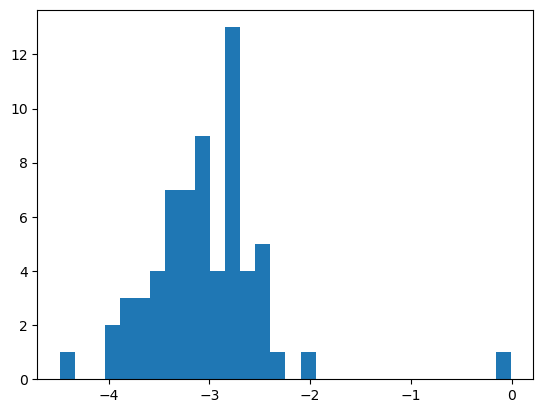

In [48]:
import matplotlib.pyplot as plt

plt.hist(np.log10(abs(df_full.mean(axis=0))),bins=30)

In [52]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader

@torch.no_grad()
def analyze_examples(model, loader, device, feat_mean, feat_std, k=3, which="first", top_k=10):
    """
    For k trajectories: prints latent stats, per-feature RMSE (orig scale),
    and per-time-step cosine similarity (std space, masked).
    which: "first" | "random"
    """
    model.eval()
    shown, rng = 0, np.random.default_rng(0)

    for x, pad_mask, obs_mask, hours, idxs, traj_ids in loader:
        x        = x.to(device)                 # (B,L,D) raw
        pad_mask = pad_mask.to(device).bool()   # (B,L)
        obs_mask = obs_mask.to(device).bool()   # (B,L,D)
        hours    = hours.to(device).long()      # (B,L)

        # standardize inputs as in training
        x_std = (x - feat_mean.view(1,1,-1)) / feat_std.view(1,1,-1)
        x_in  = x_std.masked_fill(~obs_mask, 0.0).masked_fill(pad_mask.unsqueeze(-1), 0.0)

        recon_std, z = model(x_in, src_key_padding_mask=pad_mask, start_hour=0)
        # for reporting RMSE in original scale
        recon = recon_std * feat_std.view(1,1,-1) + feat_mean.view(1,1,-1)

        valid = obs_mask & (~pad_mask).unsqueeze(-1)      # (B,L,D)
        B, L, D = x.shape

        order = list(range(B))
        if which == "random":
            rng.shuffle(order)

        for b in order:
            vb = valid[b]  # (L,D)
            if not vb.any():
                continue

            # ---- per-feature RMSE on ORIGINAL scale ----
            se_feat = torch.zeros(D, device=device)
            n_feat  = torch.zeros(D, device=device)
            for t in range(L):
                vtd = vb[t]                            # (D,)
                if vtd.any():
                    dtd = (recon[b, t] - x[b, t])[vtd]
                    se_feat[vtd] += dtd.pow(2)
                    n_feat[vtd]  += 1
            rmse_feat = (se_feat / n_feat.clamp_min(1)).sqrt().cpu().numpy()  # (D,)
            feat_std_np = feat_std.cpu().numpy()
            nrmse_pct = 100.0 * (rmse_feat / np.maximum(feat_std_np, 1e-8))

            df_feat = pd.DataFrame({
                "feature": np.arange(D),
                "RMSE_orig": rmse_feat,
                "NRMSE_%_of_train_std": nrmse_pct,
                "n_valid": n_feat.cpu().numpy().astype(int)
            })
            worst_feat = df_feat.sort_values("NRMSE_%_of_train_std", ascending=False).head(top_k)
            best_feat  = df_feat.sort_values("NRMSE_%_of_train_std", ascending=True ).head(top_k)

            # ---- per-time-step cosine similarity (STANDARDIZED) ----
            cos_list, n_dim_list, hour_list, tidx_list = [], [], [], []
            for t in range(L):
                vtd = vb[t]  # valid dims at time t
                if vtd.any():
                    xt = x_std[b, t][vtd]
                    rt = recon_std[b, t][vtd]
                    # cosine with masking
                    denom = (xt.norm() * rt.norm()).clamp_min(1e-12)
                    cos_t = float((xt * rt).sum() / denom)
                    cos_list.append(cos_t)
                    n_dim_list.append(int(vtd.sum().item()))
                    hour_list.append(int(hours[b, t].item()))
                    tidx_list.append(t)

            if len(cos_list) == 0:
                avg_cos, med_cos = float("nan"), float("nan")
                best_steps = worst_steps = pd.DataFrame()
            else:
                cos_arr = np.array(cos_list)
                avg_cos = float(np.mean(cos_arr))
                med_cos = float(np.median(cos_arr))
                df_time = pd.DataFrame({
                    "t": tidx_list,
                    "hour": hour_list,
                    "n_dims": n_dim_list,
                    "cosine": cos_arr
                })
                best_steps  = df_time.sort_values("cosine", ascending=False).head(top_k)
                worst_steps = df_time.sort_values("cosine", ascending=True ).head(top_k)

            # ---- print summary ----
            z_np = z[b].cpu().numpy()
            print(f"\n=== Traj {traj_ids[b]} ===")
            print(f"z shape: {z_np.shape} | ||z||2={np.linalg.norm(z_np):.3f} | mean|z|={np.abs(z_np).mean():.4f}")
            print(f"Cosine per step (std space, masked) — avg={avg_cos:.4f}, median={med_cos:.4f}, "
                  f"best={np.max(cos_list) if cos_list else float('nan'):.4f}, "
                  f"worst={np.min(cos_list) if cos_list else float('nan'):.4f}")

            print("\nTop-10 WORST time steps by cosine:")
            if len(cos_list):
                print(worst_steps.to_string(index=False, formatters={
                    "cosine": lambda v: f"{v:.4f}"
                }))
            else:
                print("  (no valid steps)")

            print("\nTop-10 BEST time steps by cosine:")
            if len(cos_list):
                print(best_steps.to_string(index=False, formatters={
                    "cosine": lambda v: f"{v:.4f}"
                }))
            else:
                print("  (no valid steps)")

            print("\nTop-10 WORST features by % of train std:")
            print(worst_feat.to_string(index=False, formatters={
                "RMSE_orig": lambda v: f"{v:.4f}",
                "NRMSE_%_of_train_std": lambda v: f"{v:.1f}"
            }))
            print("\nTop-10 BEST features by % of train std:")
            print(best_feat.to_string(index=False, formatters={
                "RMSE_orig": lambda v: f"{v:.4f}",
                "NRMSE_%_of_train_std": lambda v: f"{v:.1f}"
            }))

            shown += 1
            if shown >= k:
                return

    if shown == 0:
        print("No valid examples found (all entries missing?)")


# ---------- Optional: dataset-level cosine summary ----------
@torch.no_grad()
def summarize_cosine(model, loader, device, feat_mean, feat_std):
    """Aggregate cosine per time step across the whole loader."""
    model.eval()
    cos_vals = []
    for x, pad_mask, obs_mask, hours, *_ in loader:
        x        = x.to(device)
        pad_mask = pad_mask.to(device).bool()
        obs_mask = obs_mask.to(device).bool()
        x_std = (x - feat_mean.view(1,1,-1)) / feat_std.view(1,1,-1)
        x_in  = x_std.masked_fill(~obs_mask, 0.0).masked_fill(pad_mask.unsqueeze(-1), 0.0)
        recon_std, _ = model(x_in, src_key_padding_mask=pad_mask, start_hour=0)
        valid = obs_mask & (~pad_mask).unsqueeze(-1)
        B, L, D = x.shape
        for b in range(B):
            for t in range(L):
                vtd = valid[b, t]
                if vtd.any():
                    xt = x_std[b, t][vtd]
                    rt = recon_std[b, t][vtd]
                    denom = (xt.norm() * rt.norm()).clamp_min(1e-12)
                    cos_vals.append(float((xt * rt).sum() / denom))
    if not cos_vals:
        print("No valid steps for cosine.")
        return
    arr = np.array(cos_vals)
    print("\n=== Dataset cosine summary (std space, masked) ===")
    print(f"mean={arr.mean():.4f}  median={np.median(arr):.4f}  "
          f"p05={np.percentile(arr,5):.4f}  p95={np.percentile(arr,95):.4f}  n={arr.size}")

# ---- Example usage ----
# Non-shuffled loader for inspection
test_inspect_loader = DataLoader(
    test_ds, batch_size=32, shuffle=False,
    collate_fn=collate_fn, pin_memory=(DEVICE.type=='cuda')
)

analyze_examples(model, test_inspect_loader, DEVICE, feat_mean, feat_std, k=3, which="first", top_k=10)
summarize_cosine(model, test_inspect_loader, DEVICE, feat_mean, feat_std)



=== Traj 760b048a74ada583c9558b9fef1171d31b137a12889711d025e1f4604be4e549 ===
z shape: (64,) | ||z||2=0.151 | mean|z|=0.0151
Cosine per step (std space, masked) — avg=0.9864, median=0.9854, best=0.9895, worst=0.9843

Top-10 WORST time steps by cosine:
  t  hour  n_dims cosine
 65    17     128 0.9843
133    13     128 0.9853
  7     7     128 0.9853
 28     4     128 0.9853
 93    21     128 0.9854
 92    20     128 0.9866
 77     5     128 0.9895
 54     6     128 0.9895

Top-10 BEST time steps by cosine:
  t  hour  n_dims cosine
 54     6     128 0.9895
 77     5     128 0.9895
 92    20     128 0.9866
 93    21     128 0.9854
 28     4     128 0.9853
  7     7     128 0.9853
133    13     128 0.9853
 65    17     128 0.9843

Top-10 WORST features by % of train std:
 feature RMSE_orig NRMSE_%_of_train_std  n_valid
      98    2.5122                 30.5        8
      64    3.9574                 30.2        8
     107    2.8651                 28.7        8
     117    2.4175      

In [121]:
df_full.to_parquet("Full_latent_emb.parquet")

In [45]:

zs, ids = [], []
model.eval()
with torch.no_grad():
    for x, lengths, batch_ids in train_loader:
        x = x.cuda()
        _, z = model(x, lengths)
        zs.append(z.cpu().numpy())        # shape (batch, E)
        ids.extend(batch_ids.numpy())     # length batch

# stack into (N, E) and (N,)
Z   = np.vstack(zs)
ids = np.array(ids)


In [54]:
df_full

,cluster,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,...,z_54,z_55,z_56,z_57,z_58,z_59,z_60,z_61,z_62,z_63
traj_id,,,,,,,,,,,,,,,,,,,,,
0000a204849023cd902b8c7dd9edc37b8bbc222edbe6620b26b852a3e24b317c,0,-0.016771,-0.001483,-0.002527,0.007222,-0.002190,0.008285,-0.019030,0.007321,0.007677,...,0.005641,0.001101,-0.004430,-0.011695,-0.023660,-0.004164,-0.018098,0.016560,-0.006653,0.010379
0000a70c6bce971755183b6155d263a1db3027e6ead671a9401a85052d4d424e,1,-0.012937,-0.017802,0.009080,-0.005825,-0.000865,0.027781,0.038929,-0.009934,-0.000369,...,-0.027474,0.052340,-0.016712,0.019182,-0.047034,0.041683,0.032674,0.007857,0.010552,0.001380
0000d1f90748a756d45a2c6ac8489bb6db9c9bfa96c1d255867864e26de3bc52,0,-0.003439,-0.003079,-0.002167,-0.003142,-0.000628,0.006895,-0.000907,0.005760,0.004924,...,0.002446,0.006642,-0.005272,-0.002080,-0.009599,0.010200,0.002838,0.005130,0.002167,0.000047
0001cb486921957ec892d0d3ab7f13e22926223e16518e8175b110296186391a,1,0.014246,0.016490,0.004716,-0.003243,-0.004549,0.000664,0.016643,0.018153,-0.000190,...,-0.016423,-0.004273,-0.016565,-0.002570,-0.007826,-0.014716,0.019769,0.020243,0.037931,-0.003633
0001e79f8ecb5fd97d9ef38485f2dad1fe7438b0e00528f2b001266666fd3f87,2,-0.002057,0.015496,0.004091,-0.004663,0.000683,0.009320,0.007286,0.003244,-0.002536,...,-0.001905,-0.012813,0.005927,0.001993,0.006118,0.009945,-0.009945,-0.023205,-0.008892,-0.000490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fff9bae85a579ad59c12eae1ebf531f82d7d2f5fc2ca002f9e3fff31d2839ed3,0,-0.000064,-0.007463,-0.003198,-0.010556,-0.000741,0.001123,-0.000404,0.005863,-0.002253,...,-0.003828,-0.001133,0.002784,-0.001991,0.002780,0.001099,0.006009,0.004764,0.003838,0.003406
fffe4d7714d585aea3af8e27cb238b478ad60946ad5fc5099247ee73ae8d5285,0,0.002110,-0.001654,-0.007093,0.014024,-0.003327,0.004887,-0.019628,0.012206,0.006518,...,0.016963,-0.000068,-0.003343,0.003729,-0.006788,-0.002138,0.001619,-0.026658,-0.003667,0.010761
fffe9537d2c043261c11213c802ef681346fcd1f7c0b3c46c55d4ba9ae79c434,0,0.005704,0.006048,0.005857,-0.000410,-0.004661,0.004129,-0.016429,0.000060,0.004609,...,-0.007882,0.002359,0.001825,-0.002630,-0.011984,0.003600,-0.006951,0.007310,0.004316,0.000262


In [53]:
Z.shape

(95410, 64)

In [39]:
Z = np.load('./latent.npy')
ids = np.load('./ids.npy')
#loaded_data = np.load('my_array.npy')

In [40]:
col_names = [f"z_{i}" for i in range(Z.shape[1])]
Z_df = pd.DataFrame(Z, index=ids, columns=col_names)

In [41]:
Z_df.index.name = "traj_ids"

In [42]:
n_samples, n_dims = Z.shape

# If you have your traj_ids list (length n_samples):
#   traj_ids = dataset.ids[:len(labels)]
# otherwise use a simple RangeIndex
idx = Z_df.index  # or: idx = range(n_samples)

#  Create column names for each latent dimension
col_names = [f"z_dim_{i}" for i in range(n_dims)]

# Build the DF
Z_df = pd.DataFrame(Z, index=idx, columns=col_names)

# --- 2) (Optional) Add cluster labels ---
#Z_df["cluster"] = labels  # assumes `labels` is length n_samples

# --- 3) Save to disk ---
#  Parquet is compact and preserves dtypes:
#Z_df.to_parquet("trajectory_latents_with_clusters.parquet")

#  Or CSV if you need interoperability:
#Z_df.reset_index().to_csv("trajectory_latents_with_clusters.csv", index=False)

In [43]:
Z_df

,z_dim_0,z_dim_1,z_dim_2,z_dim_3,z_dim_4,z_dim_5,z_dim_6,z_dim_7,z_dim_8,z_dim_9,...,z_dim_54,z_dim_55,z_dim_56,z_dim_57,z_dim_58,z_dim_59,z_dim_60,z_dim_61,z_dim_62,z_dim_63
traj_ids,,,,,,,,,,,,,,,,,,,,,
0000a204849023cd902b8c7dd9edc37b8bbc222edbe6620b26b852a3e24b317c,-3.497227e-14,0.002428,8.967774e-07,-0.009029,0.000429,0.004706,0.001221,0.013672,-0.004578,0.001184,...,0.000185,-0.001249,-0.002812,0.005025,-0.014001,-0.002534,0.000518,0.001478,0.001763,0.001808
0000a70c6bce971755183b6155d263a1db3027e6ead671a9401a85052d4d424e,3.708276e-15,-0.003982,7.504224e-07,-0.000462,0.006784,0.002053,-0.000236,0.001475,0.009486,0.000829,...,-0.005663,-0.010385,-0.002425,0.004853,-0.009746,0.000606,-0.011754,0.000880,-0.001975,0.002138
0000d1f90748a756d45a2c6ac8489bb6db9c9bfa96c1d255867864e26de3bc52,-2.428343e-14,-0.001128,8.439603e-07,-0.001810,-0.000343,0.002701,0.005072,0.013107,0.002500,0.000779,...,0.000634,0.004255,0.000978,-0.005532,-0.005621,0.002556,-0.002085,-0.001457,-0.002561,0.002383
0001cb486921957ec892d0d3ab7f13e22926223e16518e8175b110296186391a,-6.528241e-14,-0.004085,9.496927e-07,-0.003063,0.003122,-0.003184,0.004460,0.017564,0.002744,-0.009787,...,-0.003021,-0.007059,-0.001219,-0.004697,0.024026,0.005549,0.000820,0.000123,-0.010193,-0.000989
0001e79f8ecb5fd97d9ef38485f2dad1fe7438b0e00528f2b001266666fd3f87,-1.077761e-14,0.000028,8.092271e-07,-0.000342,-0.003860,0.011683,-0.004016,0.006451,-0.008146,0.008902,...,-0.003395,0.015563,0.001572,-0.012902,-0.005899,0.004366,-0.001338,-0.000116,0.005877,-0.010572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fff9bae85a579ad59c12eae1ebf531f82d7d2f5fc2ca002f9e3fff31d2839ed3,-3.610551e-14,-0.002716,8.796559e-07,-0.006749,0.000007,-0.000905,0.005628,0.007659,-0.002986,-0.001801,...,-0.000116,0.000576,-0.000682,-0.002434,-0.011017,0.003452,0.001126,0.002348,0.000162,0.000545
fffe4d7714d585aea3af8e27cb238b478ad60946ad5fc5099247ee73ae8d5285,-4.968401e-14,0.000262,9.138751e-07,0.001646,0.001957,0.001899,0.006152,0.009011,-0.007636,-0.001415,...,-0.004180,-0.003685,-0.000622,0.001645,0.012995,0.003868,0.001665,-0.006654,-0.000812,0.008400
fffe9537d2c043261c11213c802ef681346fcd1f7c0b3c46c55d4ba9ae79c434,-1.619866e-14,0.004990,8.177250e-07,-0.008986,0.006765,0.007912,0.001748,0.006655,-0.004018,-0.004563,...,0.002012,0.001559,0.000928,-0.001584,-0.002727,0.008679,-0.000526,-0.000411,-0.005009,0.005685


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from tqdm import tqdm
# 1) Define range of K to try
Ks = list(range(2, 11))

# 2) Containers for metrics
inertias = []
sil_scores = []
ch_scores   = []
db_scores   = []

# 3) Sweep
for K in tqdm(Ks):
    km = KMeans(n_clusters=K, random_state=42, n_init='auto').fit(Z)
    labels = km.labels_

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Z, labels))
    ch_scores.append(calinski_harabasz_score(  Z, labels))
    db_scores.append(davies_bouldin_score(      Z, labels))

# 4) Plot
fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Elbow & CH
axes[0].plot(Ks, inertias,      "o-", label="Inertia (Elbow)")
axes[0].plot(Ks, ch_scores,     "s--", label="Calinski–Harabasz")
axes[0].set_ylabel("Inertia / CH score")
axes[0].legend(loc="best")
axes[0].grid(True)

# Silhouette & DB
axes[1].plot(Ks, sil_scores, "o-", label="Silhouette")
axes[1].plot(Ks, db_scores,  "s--", label="Davies–Bouldin")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Score")
axes[1].invert_yaxis()            # lower DB is better
axes[1].legend(loc="best")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [144]:


# 1) Define range of K to try
Ks = list(range(2, 11))

# 2) Containers for metrics
inertias = []
sil_scores = []
ch_scores  = []
db_scores  = []

# 3) Sweep through K values
print("Calculating clustering metrics for K=2 to 10...")

for K in tqdm(Ks):
    km = KMeans(n_clusters=K, random_state=42, n_init='auto').fit(Z)
    labels = km.labels_

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Z, labels))
    ch_scores.append(calinski_harabasz_score(Z, labels))
    db_scores.append(davies_bouldin_score(Z, labels))

# 4) Normalize the metrics to a 0-1 scale for plotting on a single axis
#    For Inertia and Davies-Bouldin, lower is better, so we invert them during scaling.
scaler = MinMaxScaler()
norm_inertia = scaler.fit_transform(np.array(inertias).reshape(-1, 1))
norm_sil = scaler.fit_transform(np.array(sil_scores).reshape(-1, 1))
norm_ch = scaler.fit_transform(np.array(ch_scores).reshape(-1, 1))
norm_db = scaler.fit_transform(np.array(db_scores).reshape(-1, 1))

# The goal is "higher is better" for all normalized scores.
# Inertia and Davies-Bouldin are "lower is better", so we subtract from 1.
norm_inertia = 1 - norm_inertia
norm_db = 1 - norm_db

# 5) Plotting
# Use a plot style suitable for posters (larger fonts, thicker lines)


Calculating clustering metrics for K=2 to 10...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [13:38<00:00, 90.90s/it]


In [44]:
from sklearn.cluster import KMeans
import pandas as pd

# --- 1) features matrix from your latent table ---
# Z_df: index = traj_id, columns like z_0 ... z_63
X = Z_df.filter(regex=r'^z_').values   # (N, d)

# --- 2) fit KMeans with K=6 ---
km6 = KMeans(n_clusters=5, random_state=42, n_init='auto')
labels6 = km6.fit_predict(X)           # ints 0..5

# --- 3) build the mapping dataframe ---
cluster_df = pd.DataFrame({
    'traj_id': Z_df.index,
    'cluster': labels6.astype(int)
}).reset_index(drop=True)

# quick sanity check
print(cluster_df['cluster'].value_counts().sort_index())



cluster
0    11136
1    52255
2    11467
3     9781
4    10771
Name: count, dtype: int64


In [45]:
from sklearn.cluster import KMeans
import pandas as pd

# --- 1) features matrix from your latent table ---
# Z_df: index = traj_id, columns like z_0 ... z_63
X = Z_df.filter(regex=r'^z_').values   # (N, d)

# --- 2) fit KMeans with K=6 ---
km6 = KMeans(n_clusters=5, random_state=42, n_init='auto')
labels6 = km6.fit_predict(X)           # ints 0..5

# --- 3) build the mapping dataframe ---
cluster_df = pd.DataFrame({
    'traj_id': Z_df.index,
    'cluster': labels6.astype(int)
}).reset_index(drop=True)

# quick sanity check
print(cluster_df['cluster'].value_counts().sort_index())



cluster
0    11136
1    52255
2    11467
3     9781
4    10771
Name: count, dtype: int64


Plot saved to clustering_metrics_poster.png


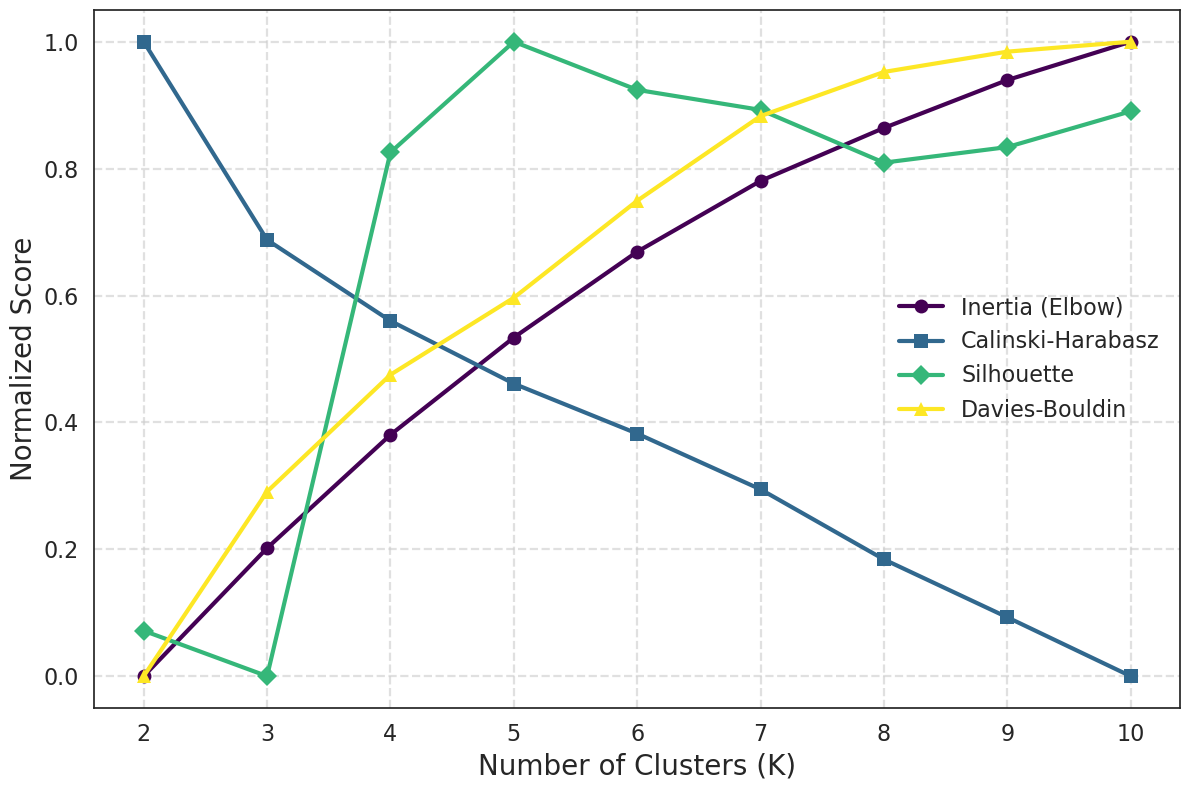

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm


plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Define a professional color palette
colors = plt.cm.viridis(np.linspace(0, 1, 4))
# Plot all normalized metrics
ax.plot(Ks, norm_inertia, "o-", label="Inertia (Elbow)", color=colors[0], linewidth=3, markersize=10)
ax.plot(Ks, norm_ch,      "s-", label="Calinski-Harabasz", color=colors[1], linewidth=3, markersize=10)
ax.plot(Ks, norm_sil,     "D-", label="Silhouette", color=colors[2], linewidth=3, markersize=10)
ax.plot(Ks, norm_db,      "^-", label="Davies-Bouldin", color=colors[3], linewidth=3, markersize=10)

# --- Add annotations to guide the viewer ---
# Find the optimal K for each metric
k_ch = Ks[np.argmax(norm_ch)]
k_sil = Ks[np.argmax(norm_sil)]
k_db = Ks[np.argmax(norm_db)]
# For elbow, we visually identify it or choose a programmatic approach (e.g., K=4)


# Arrow and text styling

# --- Final plot styling ---
#ax.set_title("Clustering Metric Analysis to Determine Optimal K", fontsize=24, pad=20)
ax.set_xlabel("Number of Clusters (K)", fontsize=20)
ax.set_ylabel("Normalized Score", fontsize=20)
ax.legend(loc="best", fontsize=16,facecolor='white')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xticks(Ks) # Ensure all integer K values are marked

plt.tight_layout()

# Save the figure in high resolution for the poster
output_filename = "clustering_metrics_poster.png"
plt.savefig(output_filename, dpi=300, bbox_inches="tight")
print(f"Plot saved to {output_filename}")

plt.show()

Plot saved successfully to training_mse_plot.png


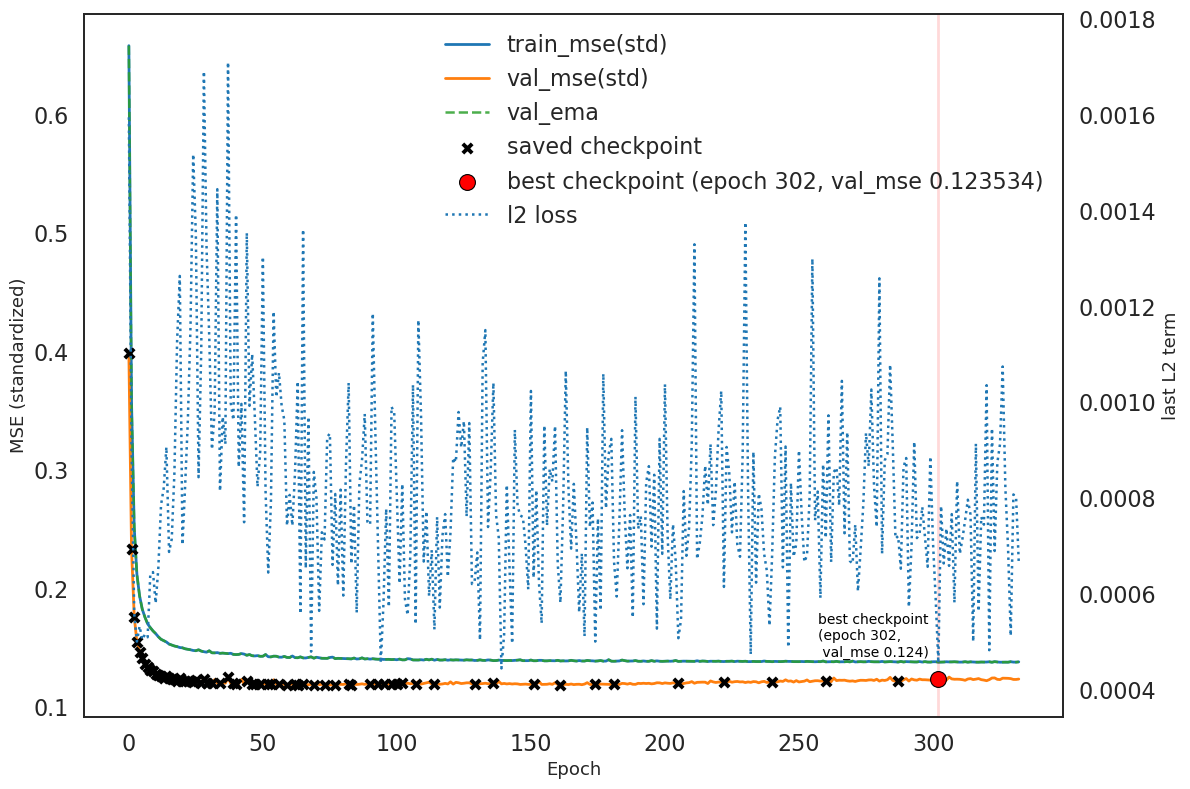

In [108]:
## import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

def plot_training_history(df, out_path="training_mse_plot.png"):
    if df is None or df.empty:
        print("No data to plot.")
        return

    # Style without grid
    plt.style.use('seaborn-v0_8-white')
    fig, ax1 = plt.subplots(figsize=(12, 8))
    ax2 = ax1.twinx()
    ax1.grid(False); ax2.grid(False)

    # --- Primary axis: MSE curves ---
    l_train, = ax1.plot(df['epoch'], df['train_mse'], linewidth=2, label='train_mse(std)')
    l_val,   = ax1.plot(df['epoch'], df['val_mse'],   linewidth=2, label='val_mse(std)')
    l_ema,   = ax1.plot(df['epoch'], df['val_ema'],   linewidth=1.8, linestyle='--', alpha=0.85, label='val_ema')

    ax1.set_xlabel('Epoch', fontsize=13)
    ax1.set_ylabel('MSE (standardized)', fontsize=13)

    # Tight scale for MSE axis
    mmin = min(df['train_mse'].min(), df['val_mse'].min(), df['val_ema'].min())
    mmax = max(df['train_mse'].max(), df['val_mse'].max(), df['val_ema'].max())
    pad  = max(1e-3, 0.05*(mmax - mmin if mmax > mmin else mmax))
    ax1.set_ylim(mmin - pad, mmax + pad)

    # --- Secondary axis: last L2 term ---
    l_l2, = ax2.plot(df['epoch'], df['last_l2'], linestyle=':', linewidth=1.8, label='l2 loss')
    ax2.set_ylabel('last L2 term', fontsize=13)
    l2_min, l2_max = df['last_l2'].min(), df['last_l2'].max()
    l2_pad = max(1e-6, 0.08*(l2_max - l2_min if l2_max > l2_min else l2_max))
    ax2.set_ylim(max(0.0, l2_min - l2_pad), l2_max + l2_pad)

    # Mark ALL saved checkpoints (black ×)
    if 'saved' in df.columns and df['saved'].any():
        saved_df = df[df['saved']]
        ax1.scatter(saved_df['epoch'], saved_df['val_mse'],
                    marker='x', s=45, c='black', label='saved checkpoint', zorder=9)

        # Highlight the checkpoint we ACTUALLY keep: the last saved one
        best_row = saved_df.loc[saved_df['epoch'].idxmax()]
        bx, by = int(best_row['epoch']), float(best_row['val_mse'])

        # Big red dot + annotation
        ax1.scatter(bx, by, s=130, marker='o',
                    facecolor='red', edgecolor='black', linewidth=0.8,
                    zorder=12, label=f"best checkpoint (epoch {bx}, val_mse {by:.6f})")
        ax1.annotate(f"best checkpoint\n(epoch {bx},\n val_mse {by:.3f})",
                     xy=(bx-50, by+0.0075), xycoords='data',
                     xytext=(10, 10), textcoords='offset points',
                     fontsize=10, color='black')
        # subtle vertical guide
        ax1.axvline(bx, color='red', alpha=0.15, linewidth=2)

    # --- Combined legend from BOTH axes (includes L2) ---
    h1, lab1 = ax1.get_legend_handles_labels()
    h2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, lab1 + lab2, loc='upper right', frameon=False)

    fig.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Plot saved successfully to {out_path}")
    plt.show()

# ---------- Main ----------
if __name__ == "__main__":
    df_log = parse_training_log("./logs/train_log.txt")  # adjust path if needed
    plot_training_history(df_log, out_path="training_mse_plot.png")


In [46]:
for i in range(15):
    # Boolean mask for cluster == i
    mask = cluster_df['cluster'] == i

    # Select all rows in cluster i
    sub_df = cluster_df.loc[mask, :]

    print(f"Cluster {i} has {len(sub_df)} rows")
    # …do whatever you need with sub_df…


Cluster 0 has 11136 rows
Cluster 1 has 52255 rows
Cluster 2 has 11467 rows
Cluster 3 has 9781 rows
Cluster 4 has 10771 rows
Cluster 5 has 0 rows
Cluster 6 has 0 rows
Cluster 7 has 0 rows
Cluster 8 has 0 rows
Cluster 9 has 0 rows
Cluster 10 has 0 rows
Cluster 11 has 0 rows
Cluster 12 has 0 rows
Cluster 13 has 0 rows
Cluster 14 has 0 rows


In [148]:
cluster_df

,traj_id,cluster
0,fe50fed06df72c2d41e6cf5f7abeef8192237171b1ce50...,3
1,0dc887f40967dabf41c2762c3211f3aefc90e328288420...,1
2,449c0a363829ad6886c12b9b30629d18a3c2ad14f7d4bb...,1
3,b9070349d966ac17ef4e0fd072a8243696f8e0c7608a8b...,1
4,65ce64a59b259d0f1cbd9fb39a73cd8a47840fd5a9d063...,0
...,...,...
92542,25e5fb54f3ac61bcd7d614be12da1a74e9644836a38003...,1
92543,5a19eb9b6a177052782ae5ffd640f977ca7a33ee7839bd...,1
92544,b1d8fcca0dcf7f6566a9e11bcbf3aad92b691bc4928d63...,0
92545,1c9ab4aa62805fe18bce9729eaaa31d8e2054fb9d3474b...,1


In [120]:
cluster_df.to_parquet("cluster_results_fi.parquet")

In [61]:
cluster_df = pd.read_parquet("cluster_results_fi.parquet")

In [190]:
clean_joined.index_right.max(axis=0)

13349

In [191]:
hex_gdf

,geometry,hex_id,centroid
0,"POLYGON ((-88.55028 30.36403, -88.54055 30.359...",0,POINT (-88.55009 30.35553)
1,"POLYGON ((-88.55028 30.37372, -88.55028 30.364...",1,POINT (-88.5555 30.36881)
2,"POLYGON ((-88.55028 30.3931, -88.54055 30.3882...",2,POINT (-88.5501 30.3834)
3,"POLYGON ((-88.55028 30.40278, -88.55028 30.393...",3,POINT (-88.55523 30.39787)
4,"POLYGON ((-88.55028 30.42215, -88.54055 30.417...",4,POINT (-88.54994 30.41246)
...,...,...,...
67963,"POLYGON ((-79.95377 26.33337, -79.95377 26.343...",67963,POINT (-79.95209 26.33967)
67964,"POLYGON ((-79.95377 26.36356, -79.95377 26.373...",67964,POINT (-79.94825 26.36948)
67965,"POLYGON ((-79.94405 26.37865, -79.94405 26.388...",67965,POINT (-79.94272 26.38332)
67966,"POLYGON ((-79.94405 26.38871, -79.95377 26.393...",67966,POINT (-79.94854 26.39783)


In [55]:
import random
import geopandas as gpd
from shapely.geometry import LineString

# --- 0) Choose CRSs
CRS_HEX_PLANAR = "EPSG:5070"  # US Albers (good for centroid)
CRS_PLOT       = "EPSG:4326"  # lon/lat for plotting/saving

# clean_joined must contain: traj_id, pt_idx, index_right (int-like)
# hex_gdf must be the SAME grid used in the sjoin that produced index_right,
# with the SAME index as then (no reset_index after the join).

# --- 1) Make hex centroids in a proper planar CRS, then convert to WGS84
hex_planar = ses_gdf.to_crs(CRS_HEX_PLANAR)
hex_cent   = hex_planar.geometry.centroid.to_crs(CRS_PLOT)  # Points in lon/lat

hex_centroids = gpd.GeoDataFrame(
    ses_gdf[[]].copy(),                # carry the original index
    geometry=hex_cent,
    crs=CRS_PLOT
)

# --- 2) Build per-point sequence (attach the centroid that each point falls in)
pts = (
    clean_joined[["traj_id", "pt_idx", "index_right"]]
    .dropna(subset=["index_right"])
    .astype({"index_right": "int"})
    .merge(
        hex_centroids[["geometry"]],
        left_on="index_right", right_index=True, how="left"
    )
    .dropna(subset=["geometry"])
    .sort_values(["traj_id", "pt_idx"])
)

# (Optional) sanity check: all referenced hex indices exist
# assert pts["index_right"].isin(hex_centroids.index).all()

# --- 3) Build a LineString per trajectory (needs ≥2 points)
lines = (
    pts.groupby("traj_id", sort=False)["geometry"]
       .apply(lambda s: LineString(list(s)) if s.shape[0] >= 2 else None)
       .dropna()
       .rename("geometry")
       .reset_index()
)

traj_lines_gdf = gpd.GeoDataFrame(lines, geometry="geometry", crs=CRS_PLOT)

# --- 4) Randomly sample N trajectories to display
N = 10
sample_ids = random.sample(traj_lines_gdf["traj_id"].tolist(), k=min(N, len(traj_lines_gdf)))
sample_gdf = traj_lines_gdf[traj_lines_gdf["traj_id"].isin(sample_ids)].copy()


In [185]:
point_gdf

,traj_id,pt_idx,latitude,longitude,geometry
0,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,1,24.548312,-81.796707,POINT (-81.79671 24.54831)
1,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,3,24.548324,-81.796739,POINT (-81.79674 24.54832)
2,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,5,24.548307,-81.796648,POINT (-81.79665 24.54831)
3,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,20,26.451009,-81.949365,POINT (-81.94936 26.45101)
4,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,21,26.451007,-81.949299,POINT (-81.9493 26.45101)
...,...,...,...,...,...
1677305,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,130,29.942492,-81.504768,POINT (-81.50477 29.94249)
1677306,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,133,30.080000,-81.550000,POINT (-81.55 30.08)
1677307,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,134,30.080000,-81.550000,POINT (-81.55 30.08)
1677308,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,140,29.944345,-81.510310,POINT (-81.51031 29.94434)


In [60]:
print("hex CRS:", hex_gdf.crs, "lines CRS:", traj_lines_gdf.crs, "joined CRS:", clean_joined.crs)
print("hex bounds:", hex_gdf.total_bounds)
print("line bounds:", traj_lines_gdf.total_bounds)


hex CRS: epsg:4326 lines CRS: EPSG:4326 joined CRS: EPSG:4326
hex bounds: [-88.56     24.45176 -79.94085  32.34301]
line bounds: [-87.52918394  24.54806641 -80.03323366  30.98551426]


In [47]:
from tqdm import tqdm
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
states = gpd.read_file('cb_2018_us_state_500k.shp')
df = clean_joined.copy()

# ── 0) Utility to pick top‐m trajectories per cluster by proximity in Z-space
def find_representative_trajectories(Z, labels, traj_ids, centers, m=50):
    reps = {}
    K = centers.shape[0]
    for c in tqdm(range(K)):
        idx_c = np.where(labels == c)[0]          # indices in Z for cluster c
        Zc    = Z[idx_c]                          # their latent vectors
        # Euclidean distance to cluster centroid
        dists = np.linalg.norm(Zc - centers[c], axis=1)
        # pick the m smallest distances
        order = np.argsort(dists)[: min(m, len(dists))]
        reps[c] = [traj_ids[i] for i in idx_c[order]]
    return reps
m = 300
# ── 1) Compute representatives (50 per cluster)
#    MAKE SURE Z, labels, ds.ids, and kmeans.cluster_centers_ are in scope
representatives = find_representative_trajectories(
    Z, labels6, clean_joined.traj_id, km6.cluster_centers_, m
)

# ── 2) Merge cluster labels into your point‐level table
joined = df.merge(cluster_df, on="traj_id", how="left")

# ── 3) Build LineStrings for the representative traj_ids
traj_lines = []
for cl, tid_list in tqdm(representatives.items()):
    for tid in tqdm(tid_list):
        sub = joined[joined["traj_id"] == tid].sort_values("pt_idx")
        pts = [
            ses_gdf.at[int(h), "centroid"]
            for h in sub["index_right"].dropna().astype(int)
        ]
        if len(pts) >= 2:
            traj_lines.append({
                "traj_id": tid,
                "cluster": cl,
                "geometry": LineString(pts)
            })

traj_lines_gdf = gpd.GeoDataFrame(
    traj_lines,
    geometry="geometry",
).set_crs(5070).to_crs(4326)

# ── 4) Prepare output folder


  0%|                                                                                                                                                                            | 0/5 [00:00<?, ?it/s]
%|                                                                                                                                                                          | 0/300 [00:00<?, ?it/s]
%|█                                                                                                                                                                 | 2/300 [00:00<00:19, 15.47it/s]
%|██▏                                                                                                                                                               | 4/300 [00:00<00:19, 15.26it/s]
%|███▏                                                                                                                                                              | 6/300 [00:00<00:19, 15.17it/s]
%|████▎     

In [124]:
out_dir = "tod_cluster_results"
os.makedirs(out_dir, exist_ok=True)

# ── 5) Color mapping (rainbow per cluster)
cluster_ids = sorted(traj_lines_gdf['cluster'].unique())
colors = plt.cm.rainbow(np.linspace(0, 1, len(cluster_ids)))
color_map = dict(zip(cluster_ids, colors))

# ── 6) Loop and save each cluster’s representative‐only plot
for cl in cluster_ids:
    fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

    # Florida boundary
    states[states.STUSPS == "FL"].boundary.plot(
        ax=ax, linewidth=1, color="black"
    )
    ax.set_aspect("equal", adjustable="box")
    # Representative trajectories for this cluster
    subset = traj_lines_gdf[traj_lines_gdf['cluster'] == cl][:30]
    subset.plot(
        ax=ax,
        color=color_map[cl],
        linewidth=1.5
    )
    #ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Cluster {cl}/{len(cluster_ids)} — Top {m} Representatives", fontsize=20)
    ax.set_axis_off()

    fname = os.path.join(out_dir, f"cluster_{cl}_{len(subset)}_{len(cluster_ids)}_tod_repr{m}.png")
    fig.savefig(fname, bbox_inches='tight')
    plt.close(fig)

    print(f"→ Saved Cluster {cl} representatives: {fname}")


→ Saved Cluster 0 representatives: tod_cluster_results/cluster_0_30_5_tod_repr200.png
→ Saved Cluster 1 representatives: tod_cluster_results/cluster_1_30_5_tod_repr200.png
→ Saved Cluster 2 representatives: tod_cluster_results/cluster_2_30_5_tod_repr200.png
→ Saved Cluster 3 representatives: tod_cluster_results/cluster_3_30_5_tod_repr200.png
→ Saved Cluster 4 representatives: tod_cluster_results/cluster_4_30_5_tod_repr200.png


In [ ]:
traj_lines_gdf

In [63]:
gdf["label_pair"][1]

'Offices of Real Estate Agents and Brokers[sep]Offices of Real Estate Agents and Brokers'

In [79]:
print(len(feature_dict.keys()))
print(len(hex_gdf))

95410
67968


In [48]:
cj = (
    clean_joined
      .merge(
         cluster_df[['traj_id','cluster']],
         on='traj_id',
         how='left'
  )
)



In [49]:
import numpy as np
import pandas as pd

# -------------------- INPUTS --------------------
# cj: per-point rows with at least ['traj_id','pt_idx','index_right','cluster']
#     - index_right is the hex_id at that time (or -1/NaN if no data)
# gdf: POI GeoDataFrame/DataFrame with at least ['hex_id', 'cat_name'] OR 'label_pair'
#     - if 'cat_count' exists, we sum it; otherwise we just count rows
# K:   number of clusters (max label + 1 is also fine)

# -------------------- 1) Build C_{h,c} from POIs --------------------
poi_df = gdf.copy()
K = 5
# pick a top-level category column
if 'cat_name' in poi_df.columns:
    poi_df['cat_top'] = poi_df['cat_name'].astype(str)
else:
    # fall back: take prefix before "[sep]"
    poi_df['cat_top'] = poi_df['label_pair'].astype(str).str.split('[sep]').str[0]

# ensure hex_id is integer
poi_df['hex_id'] = poi_df['hex_id'].astype(int)

# choose weight: actual count column if available, else 1 per row
weight_col = 'cat_count' if 'cat_count' in poi_df.columns else None
if weight_col is not None:
    agg = poi_df.groupby(['hex_id','cat_top'], observed=True)[weight_col].sum()
else:
    agg = poi_df.groupby(['hex_id','cat_top'], observed=True).size()

# pivot → hex × category table of counts C_{h,c}
C_hex_cat = agg.unstack(fill_value=0).sort_index()
C_hex_cat.columns.name = None  # cleaner column name

# -------------------- 2) Helpers --------------------
def proportions_for_hex(hex_id, cols):
    """Return a 1×C Series of per-category proportions for a single hex."""
    if hex_id not in C_hex_cat.index:
        return pd.Series(0.0, index=cols)
    row = C_hex_cat.loc[hex_id, cols].astype(float)
    s = row.sum()
    if s <= 0:
        return pd.Series(0.0, index=cols)
    return row / s

def average_device_proportions(hex_ids, cols, weights=None):
    """
    Mean of device-level proportions for a set of devices occupying hex_ids at time t.
    weights: optional 1D array-like same length as hex_ids.
    """
    if len(hex_ids) == 0:
        return pd.Series(0.0, index=cols)
    mats = [proportions_for_hex(h, cols).values for h in hex_ids]
    M = np.vstack(mats)  # (n_devices, C)
    if weights is None:
        w = np.ones(M.shape[0], dtype=float)
    else:
        w = np.asarray(weights, dtype=float)
        if w.ndim != 1 or len(w) != M.shape[0]:
            raise ValueError("weights must be 1D with same length as hex_ids")
    w = w / (w.sum() if w.sum() > 0 else 1.0)
    avg = (w[:, None] * M).sum(axis=0)
    return pd.Series(avg, index=cols)

# -------------------- 3) Global baseline P_global(c,t) --------------------
# active hexes at each hour across ALL devices/clusters
pts_all = cj[['pt_idx','index_right']].copy()
pts_all = pts_all[pts_all['index_right'].notna()]
# treat -1 as missing (if present)
try:
    pts_all = pts_all[pts_all['index_right'].astype(int) >= 0]
except Exception:
    pass
pts_all['index_right'] = pts_all['index_right'].astype(int)

# we’ll decide category columns globally after seeing what exists in C_hex_cat
cat_cols = list(C_hex_cat.columns)

global_rows = {}
for t, sub in tqdm(pts_all.groupby('pt_idx', sort=True)):
    H_t = sub['index_right'].dropna().astype(int).unique()
    if len(H_t) == 0:
        global_rows[t] = pd.Series(0.0, index=cat_cols)
        continue
    # sum counts across hexes, then normalize by row sum → proportions
    counts = C_hex_cat.reindex(H_t).fillna(0.0).sum(axis=0)
    total = counts.sum()
    global_rows[t] = (counts / total) if total > 0 else pd.Series(0.0, index=cat_cols)

global_df = pd.DataFrame.from_dict(global_rows, orient='index').sort_index()
global_df.index.name = 'pt_idx'
global_df = global_df.fillna(0.0)

# -------------------- 4) Cluster-wise P_cluster(i,c,t) --------------------
df_counts_cat_by_cluster = {}   # each is a (T×C) table of proportions

# if you have per-(traj_id, t) weights, assemble them into a Series here;
# otherwise everything is unweighted (w=1)
for cluster_i in tqdm(range(K)):
    pts_i = cj.loc[cj['cluster'] == cluster_i, ['traj_id','pt_idx','index_right']].copy()
    pts_i = pts_i[pts_i['index_right'].notna()]
    try:
        pts_i = pts_i[pts_i['index_right'].astype(int) >= 0]
    except Exception:
        pass
    pts_i['index_right'] = pts_i['index_right'].astype(int)

    cluster_rows = {}
    for t, sub in tqdm(pts_i.groupby('pt_idx', sort=True)):
        hex_ids = sub['index_right'].tolist()
        # optional: weights per device at time t (default None)
        cluster_rows[t] = average_device_proportions(hex_ids, cat_cols, weights=None)

    df_cluster = pd.DataFrame.from_dict(cluster_rows, orient='index') \
                             .reindex(columns=cat_cols) \
                             .sort_index() \
                             .fillna(0.0)
    df_cluster.index.name = 'pt_idx'
    df_counts_cat_by_cluster[cluster_i] = df_cluster

# -------------------- 5) (Optional) Select Top-15 categories --------------------
# follow paper: rank by time-aggregated global share and keep top-15
S_c = global_df.sum(axis=0)                # aggregate over time
top15 = S_c.sort_values(ascending=False).head(15).index.tolist()

# restrict to top-15 everywhere (you can keep full tables if you prefer)
global_df_top15 = global_df[top15].copy()
for i in df_counts_cat_by_cluster:
    df_counts_cat_by_cluster[i] = df_counts_cat_by_cluster[i][top15].copy()

# At this point:
# - global_df_top15.loc[t, c] = P_global(c, t)
# - df_counts_cat_by_cluster[i].loc[t, c] = P_cluster(i, c, t)


  0%|                                                                                                                                                                            | 0/5 [00:00<?, ?it/s]
%|                                                                                                                                                                          | 0/143 [00:00<?, ?it/s]
%|█▏                                                                                                                                                                | 1/143 [00:00<00:51,  2.76it/s]
%|██▎                                                                                                                                                               | 2/143 [00:00<00:48,  2.94it/s]
%|███▍                                                                                                                                                              | 3/143 [00:01<00:47,  2.97it/s]
%|████▌     

In [54]:
import numpy as np
import pandas as pd
from functools import reduce

# ---- helpers ---------------------------------------------------------------
def rows_are_proportions(df, atol=1e-6):
    s = df.sum(axis=1).dropna()
    return bool((np.abs(s - 1.0) <= atol).all())

def align_like(dfs):
    cats  = sorted(set().union(*[set(df.columns) for df in dfs.values()]))
    times = sorted(set().union(*[set(df.index)   for df in dfs.values()]))
    aligned = {i: df.reindex(index=times, columns=cats).fillna(0.0) for i, df in dfs.items()}
    return aligned, cats, times

def device_weights(cj, weight_col=None):
    # M_{i,t}: device (or weight) mass per cluster/time; α_{i,t} = M_{i,t} / Σ_j M_{j,t}
    if weight_col is None:
        M = (cj.groupby(['pt_idx','cluster'])['traj_id'].nunique()
               .unstack(fill_value=0).sort_index())
    else:
        M = (cj.groupby(['pt_idx','cluster'])[weight_col].sum()
               .unstack(fill_value=0).sort_index())
    alpha = M.div(M.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    return M, alpha

# ---- main: build global counts & proportions -------------------------------
# df_counts_cat_by_cluster: {cluster_i: DataFrame}  (either counts or proportions)
# cj: long table with columns ['pt_idx','cluster','traj_id'] (and optional weight)

aligned, cats, times = align_like(df_counts_cat_by_cluster)

if all(rows_are_proportions(df) for df in aligned.values()):
    # Proportions → convert to (comparable) counts using device mass M_{i,t}
    M, _ = device_weights(cj, weight_col=None)  # or weight_col='w'
    global_counts = pd.DataFrame(0.0, index=times, columns=cats)
    for i, P_i in aligned.items():
        if i not in M.columns:
            continue
        w_it = M[i].reindex(times).fillna(0.0).values.reshape(-1, 1)  # M_{i,t}
        global_counts += w_it * P_i.values                            # Σ_i M_{i,t} P_i
else:
    # Already counts → just sum them (after aligning)
    global_counts = reduce(lambda a, b: a.add(b, fill_value=0.0), aligned.values())

# Optional: fill any NaNs (shouldn’t be any after align)
global_counts = global_counts.fillna(0.0)

# Baseline proportions P_global(c,t)
global_df = global_counts.div(global_counts.sum(axis=1).replace(0, 1.0), axis=0)

# (Optional) sanity check: global_df rows ≈ 1
assert np.allclose(global_df.sum(axis=1).fillna(1.0).values, 1.0, atol=1e-8)


In [51]:
from functools import reduce
global_counts = reduce(
    lambda a, b: a.add(b, fill_value=0),
    df_counts_cat_by_cluster.values()
)

# 2. (Optional) fill any NaNs just in case
global_counts = global_counts.fillna(0)

# 3. If you want the baseline **proportions** (summing across categories at each time step):
global_df = global_counts.div(global_counts.sum(axis=1).replace(0, 1), axis=0)

In [52]:
cat_labels = global_counts.columns.to_list()

In [55]:
df_counts_cat_by_cluster[0]

,Offices of Physicians,Restaurants and Other Eating Places,Offices of Other Health Practitioners,Legal Services,Offices of Real Estate Agents and Brokers,Lessors of Real Estate,Personal Care Services,Offices of Dentists,Clothing Stores,Religious Organizations,Urban Transit Systems,Automotive Repair and Maintenance,Depository Credit Intermediation,Other Amusement and Recreation Industries,Activities Related to Credit Intermediation
pt_idx,,,,,,,,,,,,,,,
1,0.014216,0.019886,0.014666,0.000428,0.008532,0.008698,0.008504,0.001201,0.000705,0.033769,0.002549,0.007484,0.001499,0.012418,0.003650
2,0.015538,0.016317,0.010521,0.001301,0.006965,0.012321,0.008442,0.001027,0.001404,0.035414,0.002451,0.008954,0.001598,0.010486,0.003993
3,0.016005,0.019930,0.011764,0.000640,0.009877,0.010300,0.005963,0.000920,0.000784,0.034899,0.003197,0.006910,0.001266,0.012162,0.003596
4,0.014357,0.017791,0.011798,0.000959,0.008400,0.010765,0.010238,0.001087,0.001306,0.038418,0.001422,0.008036,0.001516,0.011210,0.003993
5,0.015031,0.018209,0.013642,0.000729,0.007338,0.011580,0.006916,0.000896,0.001235,0.039597,0.005018,0.007587,0.001364,0.013588,0.003086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.009395,0.017020,0.011686,0.000044,0.005192,0.012552,0.006115,0.000616,0.002644,0.037626,0.003591,0.009116,0.001436,0.011268,0.001955
140,0.017345,0.018341,0.012014,0.002118,0.004529,0.010043,0.006220,0.000557,0.000516,0.031200,0.004087,0.006922,0.001139,0.012046,0.002107
141,0.011205,0.019129,0.012979,0.000550,0.004853,0.010004,0.007735,0.001146,0.001144,0.030976,0.002969,0.005557,0.001729,0.012665,0.003651


In [56]:
# Renormalize to make each row sum to 1 (safe for zero-sum rows)
row_sums = global_df_top15.sum(axis=1)
global_df_top15_n = global_df_top15.div(row_sums.replace(0, np.nan), axis=0).fillna(0.0)

# sanity check
assert np.allclose(global_df_top15_n.sum(axis=1).values, 1.0, atol=1e-12)


In [57]:
def renorm_rows_to_one(df):
    s = df.sum(axis=1)
    return df.div(s.replace(0, np.nan), axis=0).fillna(0.0)

# After you pick `top15`
#global_df_top15 = renorm_rows_to_one(global_df[top15])

for i in list(df_counts_cat_by_cluster.keys()):
    df_counts_cat_by_cluster[i] = renorm_rows_to_one(
        df_counts_cat_by_cluster[i][top15]
    )

# Sanity check: every row sums to 1 (or 0 if truly empty)
i0 = next(iter(df_counts_cat_by_cluster))
print(df_counts_cat_by_cluster[i0].sum(axis=1).describe())


count    1.430000e+02
mean     1.000000e+00
std      1.616402e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


In [58]:
import numpy as np
import pandas as pd

# Inputs you already have:
# - df_counts_cat_by_cluster: dict[int -> DataFrame]  (rows = pt_idx, cols = categories; VALUES = COUNTS, not normalized)
# - cat_labels: list of categories to compare (e.g., your Top-15)

clusters = sorted(df_counts_cat_by_cluster.keys())

# 1) Make per-cluster proportions P_i(t) and weights M_i(t)
P_by_cluster = {}
M_by_cluster = {}
for i in clusters:
    C = (df_counts_cat_by_cluster[i]
            .reindex(columns=cat_labels)  # keep same cat set
            .fillna(0))
    M = C.sum(axis=1)                                   # M_{i,t}
    P = C.div(M.replace(0, np.nan), axis=0).fillna(0)   # P_cluster(i,·,t)
    P_by_cluster[i] = P
    M_by_cluster[i] = M

# 2) Weighted global baseline  P_global(·,t) = sum_i M_{i,t} P_i(·,t) / sum_i M_{i,t}
num = None
den = None
for i in clusters:
    Ni = P_by_cluster[i].multiply(M_by_cluster[i], axis=0)   # M_{i,t} * P_i
    num = Ni if num is None else num.add(Ni, fill_value=0)
    den = M_by_cluster[i] if den is None else den.add(M_by_cluster[i], fill_value=0)

P_global = num.div(den.replace(0, np.nan), axis=0).fillna(0)   # rows=pt_idx, cols=cat_labels

# 3) Choose a deviation metric (relative ratio or log-ratio)
def deviation_matrix(P_i, P_g, mode="rel", eps=1e-9):
    """
    mode='rel'  : (P_i - P_g) / P_g           (centered at 0; interpret as ±% relative to baseline)
    mode='ratio': P_i / P_g                    (centered at 1; multiplicative factor)
    mode='log'  : log((P_i+eps)/(P_g+eps))     (additive on log scale; symmetric around 0)
    """
    if mode == "rel":
        return (P_i - P_g).div(P_g.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)
    elif mode == "ratio":
        return P_i.div(P_g.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    elif mode == "log":
        return np.log((P_i + eps) / (P_g + eps))
    else:
        raise ValueError("mode must be one of {'rel','ratio','log'}")

# Example: build relative-difference (ratio-based) deviations for each cluster
dev_rel_by_cluster = {
    i: deviation_matrix(
        P_by_cluster[i].reindex_like(P_global).fillna(0),
        P_global, mode="rel"
    )
    for i in clusters
}

# If you prefer log‐ratios (often nicer for compositional data):
dev_log_by_cluster = {
    i: deviation_matrix(
        P_by_cluster[i].reindex_like(P_global).fillna(0),
        P_global, mode="log"
    )
    for i in clusters
}


In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, ListedColormap

# --------------------------------------------------------------------
# Inputs you already have:
#   df_counts_cat_by_cluster: dict[int -> DataFrame] with COUNTS
#       rows = pt_idx (hours), cols = category names
#   cat_labels: list[str] of the categories to display (e.g., Top-15)
# --------------------------------------------------------------------

clusters = sorted(df_counts_cat_by_cluster.keys())
cat_labels = list(cat_labels)  # ensure fixed order

# 1) Row-normalize to per-hour proportions for each cluster (Top-15 denom)
P_by_cluster = {}
for i in clusters:
    C = (df_counts_cat_by_cluster[i]
            .reindex(columns=cat_labels)
            .fillna(0))
    denom = C.sum(axis=1)
    P = C.div(denom.replace(0, np.nan), axis=0).fillna(0)
    P_by_cluster[i] = P

# 2) Align all clusters to a common time index (union) and stack
all_t = sorted(set().union(*[df.index for df in P_by_cluster.values()]))
stack = np.stack(
    [P_by_cluster[i].reindex(index=all_t, columns=cat_labels).values for i in clusters],
    axis=0,  # shape = (K, T, C)
)

# 3) Unweighted baseline across clusters; deviations sum to 0 per (t, p)
P_bar = np.nanmean(stack, axis=0)          # (T, C)
D_pct = 100.0 * (stack - P_bar[None, :, :]) # (K, T, C)

# 4) Symmetric color scale and white-centered diverging colormap
mx = float(np.nanmax(np.abs(D_pct))) if np.isfinite(D_pct).any() else 1.0
base = plt.cm.get_cmap('bwr', 256)
colors = base(np.linspace(0, 1, 256))
colors[len(colors)//2] = [1, 1, 1, 1]
cmap_white_center = ListedColormap(colors)

# 5) Plot one heatmap per cluster; every cell sums to 0 across clusters
SAVE_DIR = "./tod_cluster_results_centered"
os.makedirs(SAVE_DIR, exist_ok=True)

for k_idx, i in enumerate(clusters):
    df_dev = pd.DataFrame(D_pct[k_idx], index=all_t, columns=cat_labels)

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(
        df_dev.T.values,  # categories x time
        cmap=cmap_white_center,
        norm=TwoSlopeNorm(vmin=-mx, vcenter=0.0, vmax=mx),
        aspect='auto',
        interpolation='nearest'
    )

    step = max(1, len(all_t)//12)
    ax.set_xticks(np.arange(len(all_t))[::step])
    ax.set_xticklabels([str(t) for t in all_t[::step]], rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Time Step")

    ax.set_yticks(np.arange(len(cat_labels)))
    ax.set_yticklabels(cat_labels, fontsize=9)

    ax.set_title(f"Cluster {i+1} — Centered Δ% from baseline")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label("Δ percentage points (cluster − mean across clusters)")

    fig.tight_layout()
    fig.savefig(f"{SAVE_DIR}/heatmap_centered_cluster_{i}.png", dpi=200)
    plt.close(fig)


/tmp/582147.tmpdir/ipykernel_2673/3192796134.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap('bwr', 256)


In [67]:
# ============================================================
# GPU permutation test for centered (cluster − global) deviations (NaN-aware)
# ============================================================
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ---- pick array backend: CuPy if available, else NumPy ----
try:
    import cupy as cp
    xp = cp
    ON_GPU = True
except ImportError:
    xp = np
    ON_GPU = False

def _to_numpy(a):
    return cp.asnumpy(a) if ON_GPU else np.asarray(a)

def _rng(seed):
    # RandomState so we have .permutation on both NumPy/CuPy
    return xp.random.RandomState(seed)

def _nan_to_num(a, val=0.0):
    # xp.nan_to_num exists for both; set NaN -> val
    return xp.nan_to_num(a, nan=val)

# ---------- core tensor ops (NaN-aware & zero-mass masked) ----------
def _counts_to_stat(counts_TKC, stat="l2", do_center=True, return_coverage=False):
    """
    counts_TKC: xp array (T, K, C) of raw counts (cluster-by-time sums of POI mass).
    Treat (t,k) rows with zero Top-K mass as missing (NaN) and ignore them in aggregation.

    Returns:
      T_obs_KC : xp array (K, C)
      (optional) coverage_KC : xp int array with number of valid hours used per (k,c)
    """
    T, K, C = counts_TKC.shape

    # Proportions per (t,k): divide by Top-K mass at that (t,k); zero-mass -> NaN row
    denom = counts_TKC.sum(axis=2, keepdims=True)          # (T,K,1)
    mask  = denom > 0                                      # valid rows
    P = counts_TKC / xp.where(mask, denom, 1.0)            # safe divide
    P = P.astype(xp.float32)
    P = xp.where(mask, P, xp.nan)                          # invalidate zero-mass rows

    # Global baseline per hour = mean across clusters, ignoring NaNs
    # shape: (T,1,C), broadcasts across K
    Pglob = xp.nanmean(P, axis=1, keepdims=True)

    # Deviations; if do_center, subtract the across-cluster nan-mean of deviations per hour
    Delta = P - Pglob                                      # (T,K,C), NaN where P is NaN
    if do_center:
        DeltaCtr = Delta - xp.nanmean(Delta, axis=1, keepdims=True)
    else:
        DeltaCtr = Delta

    # Coverage (how many hours contribute to each (k,c))
    # A (t,k,c) contributes iff that (t,k) row was valid (mask True).
    coverage = mask.astype(xp.int32).sum(axis=0)           # (K,1) — row-wise coverage
    # But coverage by category can differ due to NaNs introduced by Pglob if an hour has all NaNs.
    # Compute category-specific coverage: valid if DeltaCtr is finite.
    coverage_KC = xp.isfinite(DeltaCtr).astype(xp.int32).sum(axis=0)  # (K,C)

    # Time-aggregate test statistics (ignore NaNs)
    if stat == "l2":
        T_obs = xp.sqrt(xp.nansum(DeltaCtr**2, axis=0))    # (K,C)
    elif stat == "maxabs":
        T_obs = xp.nanmax(xp.abs(DeltaCtr), axis=0)        # (K,C)
    else:
        raise ValueError("stat must be 'l2' or 'maxabs'")

    # Replace all-NaN series (no valid hours) with 0
    T_obs = _nan_to_num(T_obs, val=0.0)

    if return_coverage:
        return T_obs, coverage_KC
    return T_obs

# ============================================================
# Main GPU permutation test (NaN-aware)
# ============================================================
def perm_test_centered_counts_gpu(
    visits,          # DataFrame ['traj_id','pt_idx','hex_id']
    cluster_df,      # DataFrame ['traj_id','cluster']
    poi_df,          # DataFrame ['hex_id','cat_name','cat_count']
    cat_labels,      # ordered list[str] (your Top-K categories)
    B=1000,
    stat="l2",
    random_state=0,
    store_perm=False,     # True -> return T_perm array (B x K x C)
    do_center=True,       # keep True to enforce exact zero-sum across clusters (on valid rows)
    verbose=True
):
    # ---------- 1) base join on CPU ----------
    v   = visits[['traj_id','pt_idx','hex_id']].copy()
    lab = cluster_df[['traj_id','cluster']].copy()
    poi = poi_df[['hex_id','cat_name','cat_count']].copy()

    # harmonize key types
    v['hex_id']   = v['hex_id'].astype(str)
    poi['hex_id'] = poi['hex_id'].astype(str)

    base = (v.merge(lab, on='traj_id', how='left')
              .merge(poi, on='hex_id', how='left'))

    # drop rows with no cluster; keep only selected categories
    base = base.dropna(subset=['cluster']).copy()
    base = base[ base['cat_name'].isin(cat_labels) ].copy()
    base['cat_count'] = base['cat_count'].fillna(0.0)

    # canonical orders
    times    = np.sort(base['pt_idx'].unique())
    clusters = np.sort(base['cluster'].unique())
    K, C     = len(clusters), len(cat_labels)
    t_index  = pd.Index(times, name="pt_idx")
    c_index  = pd.Index(clusters, name="cluster")

    # quick sanity checks
    if verbose:
        if len(base) == 0:
            print("WARNING: Base table is empty after filtering to cat_labels; check category names.")
        cov_check = (base.groupby(['pt_idx','cluster'])['cat_count']
                          .sum()
                          .reset_index(name='mass'))
        zero_rows = (cov_check['mass'] == 0).mean()
        print(f"[diag] rows with zero Top-K mass (before masking): {100*zero_rows:.1f}%")

    # ---------- 2) build observed counts tensor (T,K,C) on xp ----------
    # Aggregate counts per (t, cluster, cat)
    g = (base.groupby(['pt_idx','cluster','cat_name'])['cat_count']
              .sum()
              .unstack('cat_name')
              .reindex(columns=cat_labels, fill_value=0.0))

    # Make sure we have a complete (t, cluster) index grid
    full_idx = pd.MultiIndex.from_product([times, clusters], names=['pt_idx','cluster'])
    g = g.reindex(full_idx, fill_value=0.0).sort_index()

    # reshape to (T,K,C)
    counts_obs_np = g.to_numpy(dtype=np.float32).reshape(len(times), len(clusters), C)
    counts_obs = xp.asarray(counts_obs_np)

    # observed stat + coverage
    T_obs_xp, = _counts_to_stat.__wrapped__ if hasattr(_counts_to_stat, "__wrapped__") else (None,)
    T_obs_xp = _counts_to_stat(counts_obs, stat=stat, do_center=do_center)
    # also compute (optional) coverage to diagnose how many hours contribute
    _, coverage_KC_xp = _counts_to_stat(counts_obs, stat=stat, do_center=do_center, return_coverage=True)

    # ---------- 3) permutations ----------
    rng = _rng(random_state)
    if store_perm:
        T_perm_xp = xp.empty((B, K, C), dtype=xp.float32)
    ge = xp.zeros((K, C), dtype=xp.int64)  # count of T_b >= T_obs

    # To permute within each hour, we need the cluster label per row at hour t.
    # Build per-hour trajectory list and their cluster labels, then aggregate.
    # We'll reuse 'base' efficiently by hour.
    for b in tqdm(range(B), desc="Permutations", leave=False):
        counts_b = xp.zeros((len(times), K, C), dtype=xp.float32)

        for ti, t in enumerate(times):
            sub = base.loc[base['pt_idx'] == t, ['traj_id','cluster','hex_id','cat_name','cat_count']]
            if sub.empty:
                continue

            # permute the cluster labels of trajectories present at this hour
            traj_labels = (sub[['traj_id','cluster']].drop_duplicates()
                                          .set_index('traj_id')['cluster'])
            permuted = traj_labels.copy()
            permuted.values[:] = traj_labels.values[rng.permutation(len(traj_labels))]
            sub_p = sub.merge(permuted.rename('cluster_perm'), left_on='traj_id', right_index=True)
            sub_p['cluster'] = sub_p['cluster_perm']; sub_p = sub_p.drop(columns=['cluster_perm'])

            # aggregate to (cluster, cat) counts for this hour
            gp = (sub_p.groupby(['cluster','cat_name'])['cat_count']
                         .sum()
                         .unstack('cat_name')
                         .reindex(index=clusters, columns=cat_labels, fill_value=0.0)
                         .to_numpy(dtype=np.float32))
            counts_b[ti] = xp.asarray(gp)

        T_b = _counts_to_stat(counts_b, stat=stat, do_center=do_center)
        if store_perm:
            T_perm_xp[b] = T_b
        ge += (T_b >= T_obs_xp)

    # permutation p-values with +1 smoothing
    pvals_xp = (ge + 1.0) / (B + 1.0)

    # ---------- 4) return as pandas ----------
    T_obs  = pd.DataFrame(_to_numpy(T_obs_xp),  index=c_index, columns=cat_labels)
    pvals  = pd.DataFrame(_to_numpy(pvals_xp),  index=c_index, columns=cat_labels)
    cov    = pd.DataFrame(_to_numpy(coverage_KC_xp), index=c_index, columns=cat_labels)

    T_obs.index.name = pvals.index.name = cov.index.name = "cluster"

    if verbose:
        # show how many hours contributed to each (cluster, category)
        with np.printoptions(suppress=True):
            print("[diag] coverage (#hours used) per (cluster, category):")
        print(cov.astype(int))

    T_perm = _to_numpy(T_perm_xp) if store_perm else None
    return pvals, T_obs, T_perm


In [97]:
point_gdf

,traj_id,pt_idx,latitude,longitude,geometry
0,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,1,24.548312,-81.796707,POINT (-81.79671 24.54831)
1,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,3,24.548324,-81.796739,POINT (-81.79674 24.54832)
2,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,5,24.548307,-81.796648,POINT (-81.79665 24.54831)
3,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,20,26.451009,-81.949365,POINT (-81.94936 26.45101)
4,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,21,26.451007,-81.949299,POINT (-81.9493 26.45101)
...,...,...,...,...,...
1677305,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,130,29.942492,-81.504768,POINT (-81.50477 29.94249)
1677306,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,133,30.080000,-81.550000,POINT (-81.55 30.08)
1677307,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,134,30.080000,-81.550000,POINT (-81.55 30.08)
1677308,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,140,29.944345,-81.510310,POINT (-81.51031 29.94434)


In [ ]:
# --- 0) Imports (assumes perm_test_centered_counts_gpu is already defined/imported) ---
import numpy as np
import pandas as pd

# --- 1) (Optional) Build Top-15 category list from your data, restricted to visited hexes ---
# Make sure hex_id types match before joining
visits_min = clean_joined[['traj_id','pt_idx','hex_id']].copy()
poi_min    = poi_df[['hex_id','cat_name','cat_count']].copy()
visits_min['hex_id'] = visits_min['hex_id'].astype(str)
poi_min['hex_id']    = poi_min['hex_id'].astype(str)

# Only hexes that appear in visits
active_hex = visits_min['hex_id'].dropna().unique()
poi_active = poi_min[poi_min['hex_id'].isin(active_hex)]

# Rank categories globally by total POI mass among active hexes
top15 = (poi_active
         .groupby('cat_name', as_index=True)['cat_count']
         .sum()
         .sort_values(ascending=False)
         .head(15)
         .index.tolist())
cat_labels = top15  # ordered list used by the test

# --- 2) Prepare the minimal input frames with the expected columns ---
visits_use      = clean_joined[['traj_id','pt_idx','hex_id']].copy()
cluster_df_use  = cluster_df[['traj_id','cluster']].copy()
poi_df_use      = poi_df[['hex_id','cat_name','cat_count']].copy()

# --- 3) Run the streaming GPU/CPU permutation test ---
pvals, T_obs, T_perm = perm_test_centered_counts_gpu(
    visits=visits_use,
    cluster_df=cluster_df_use,
    poi_df=poi_df_use,
    cat_labels=cat_labels,   # your Top-15 list from above (or your own)
    B=1000,                  # increase for tighter Monte Carlo error
    stat="l2",               # or "maxabs"
    random_state=0,
    store_perm=False         # True if you need the full null distribution
)

print("Observed time-aggregated stat (K x C):")
print(T_obs.round(4))
print("\nPermutation p-values (K x C):")
print(pvals.round(4))


[diag] rows with zero Top-K mass (before masking): 0.0%


Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

In [64]:
T_obs

,Offices of Physicians,Restaurants and Other Eating Places,Offices of Other Health Practitioners,Legal Services,Offices of Real Estate Agents and Brokers,Lessors of Real Estate,Personal Care Services,Offices of Dentists,Clothing Stores,Religious Organizations,Urban Transit Systems,Automotive Repair and Maintenance,Depository Credit Intermediation,Other Amusement and Recreation Industries,Activities Related to Credit Intermediation
cluster,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [160]:
import geopandas as gpd

# --- 1) Make sure both layers have a CRS and they match ---
point_gdf = point_gdf.set_crs(epsg=4326, allow_override=True)   # your points look like lon/lat
hex_gdf   = hex_gdf.to_crs(point_gdf.crs)

# If your hex ids live in the index, promote them to a column named 'hex_id'
if 'hex_id' not in hex_gdf.columns:
    hex_gdf = hex_gdf.reset_index().rename(columns={'index': 'hex_id'})

# --- 2) Spatial join: assign each point to the hex that contains it ---
# (points that fall exactly on borders can become NaN; we fix them below)
pts_hex = gpd.sjoin(
    point_gdf[['traj_id','pt_idx','geometry']], 
    hex_gdf[['hex_id','geometry']],
    how='left', predicate='within'
)

# geopandas versions differ on column names; ensure we keep only what we need
if 'index_right' in pts_hex.columns and 'hex_id' not in pts_hex.columns:
    pts_hex = pts_hex.rename(columns={'index_right': 'hex_id'})

# --- 3) Optional: fill border NaNs by nearest hex (small fraction usually) ---
missing = pts_hex['hex_id'].isna()
if missing.any():
    nn = gpd.sjoin_nearest(
        pts_hex.loc[missing, ['geometry']],
        hex_gdf[['hex_id','geometry']],
        how='left', distance_col='dist'
    )
    pts_hex.loc[missing, 'hex_id'] = nn['hex_id'].values

# Final visits table expected by the permutation test
visits_w_hex = pts_hex[['traj_id','pt_idx','hex_id']].copy()
visits_w_hex['pt_idx'] = visits_w_hex['pt_idx'].astype(int)

print(visits_w_hex.head())
print("NaN hex_id rows:", visits_w_hex['hex_id'].isna().sum())


                                             traj_id  pt_idx hex_id
0  e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       1  44527
1  e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       3  44527
2  e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       5  44527
3  e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      20  41785
4  e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      21  41785
NaN hex_id rows: 0


/storage1/fs1/nlin/Active/sizhe/sizhe/envs/geospatial/lib/python3.12/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [161]:
visits_ok = visits_w_hex.dropna(subset=['hex_id']).copy()
visits_ok['hex_id'] = visits_ok['hex_id'].astype(int)

labels_s  = cluster_df.set_index('traj_id')['cluster'].astype(int)
labels_s = pd.to_numeric(labels_s, errors='coerce').dropna().astype(int)
# Attach the observed cluster per row
visits_obs = visits_ok.copy()
visits_obs['cluster'] = labels_s.reindex(visits_obs['traj_id'].values).values
sorted(visits_obs['cluster'].dropna().astype(int).unique().tolist())

[0, 1, 2, 3, 4]

In [157]:
import numpy as np
import pandas as pd
from numpy.random import default_rng
from tqdm import tqdm

# ---------- Unchanged helpers you already have ----------
# make_poi_pivot(poi_df, cat_labels)
# build_global_prop(visits, poi_pivot, cat_labels)
def make_poi_pivot(poi_df, cat_labels):
    """hex_id × category matrix of POI counts."""
    P = (
        poi_df.pivot_table(
            index="hex_id",
            columns="cat_name",
            values="cat_count",
            aggfunc="sum",
        ).fillna(0.0)
    )
    # keep only requested categories (add missing as zeros)
    for c in cat_labels:
        if c not in P.columns:
            P[c] = 0.0
    return P[cat_labels].astype(float)


def build_global_prop(visits, poi_pivot, cat_labels):
    """
    P_global(c,t): sum POIs over the UNIQUE active hexes H_t,
    then row-normalize to proportions.
    """
    rows = {}
    for t, df_t in visits.groupby("pt_idx", sort=True):
        H_t = df_t["hex_id"].dropna().astype(int).unique()
        if len(H_t) == 0:
            rows[t] = pd.Series(0.0, index=cat_labels)
            continue
        counts = poi_pivot.reindex(H_t).fillna(0.0)[cat_labels].sum(axis=0)
        s = counts.sum()
        rows[t] = counts / s if s > 0 else pd.Series(0.0, index=cat_labels)
    return (
        pd.DataFrame(rows)
        .T.reindex(columns=cat_labels)
        .sort_index()
    )

def cluster_props_from_visits(visits_with_cluster, poi_pivot, cat_labels, all_times=None, min_hex=1):
    """
    Compute per-cluster, per-time Top-15 proportions using UNIQUE hexes.
    min_hex: require at least this many unique hexes at (cluster, time), else NaNs for that row.
    """
    v = visits_with_cluster
    if all_times is None:
        all_times = sorted(v['pt_idx'].unique().tolist())

    out = {}
    for i, df_i in v.groupby('cluster', dropna=True):
        rows = {}
        for t, df_t in df_i.groupby('pt_idx', sort=True):
            H = df_t['hex_id'].dropna().astype(int).unique()
            if len(H) < min_hex:
                rows[t] = pd.Series(np.nan, index=cat_labels)
                continue
            counts = poi_pivot.reindex(H).fillna(0.0)[cat_labels].sum(axis=0)
            s = counts.sum()
            rows[t] = (counts / s) if s > 0 else pd.Series(np.nan, index=cat_labels)
        D = pd.DataFrame(rows).T.reindex(index=all_times, columns=cat_labels)
        out[int(i)] = D
    return out

def deltapct(cluster_prop, global_prop):
    """
    Δ% dictionaries, aligned with global_prop's index/columns.
    """
    out = {}
    for i, CP in cluster_prop.items():
        A, G = CP.align(global_prop, join='right')
        out[i] = (A - G) * 100.0
    return out

# ---------- Correct within-time permutation (robust to duplicate rows) ----------
def permute_clusters_within_time_rows(visits_with_cluster, rng):
    """
    Permute cluster labels within each time bin t at the level of unique (traj_id, t),
    then broadcast to all rows for that (traj_id, t).
    Assumes 'cluster' has NO NaNs (drop unlabeled beforehand).
    """
    v = visits_with_cluster[['traj_id', 'pt_idx', 'cluster']].copy()

    # representatives per (t, traj)
    reps = v.drop_duplicates(['pt_idx', 'traj_id']).copy()

    # shuffle labels among trajectories active at the same time t
    for t, idx in reps.groupby('pt_idx').groups.items():
        idx = np.fromiter(idx, dtype=int)
        labels_t = reps.loc[idx, 'cluster'].to_numpy()
        rng.shuffle(labels_t)
        reps.loc[idx, 'cluster'] = labels_t

    # broadcast permuted labels back to all rows
    v_perm = v.drop(columns=['cluster']).merge(
        reps, on=['pt_idx', 'traj_id'], how='left', validate='m:1'
    )
    return v_perm['cluster'].to_numpy()

# ---------- Main permutation test ----------
def perm_test_deltapct(
    visits, cluster_df, poi_df, cat_labels, B=1000,
    stat='maxabs', random_state=0, min_hex=1
):
    """
    Returns:
      pvals  : DataFrame [clusters × categories]
      T_obs  : same shape
      T_perm : ndarray [B × n_clusters × n_cats]
    Notes:
      - Global baseline is computed from ALL visits (unique-hex kernel).
      - Cluster proportions use unique hexes and are row-normalized on cat_labels.
      - min_hex controls stability (skip sparse cluster×time rows).
    """
    rng = default_rng(random_state)

    # -------- Label map (safe) --------
    clmap = (cluster_df[['traj_id', 'cluster']]
             .dropna(subset=['traj_id', 'cluster'])
             .copy())

    # harmonize dtypes on traj_id
    if visits['traj_id'].dtype != clmap['traj_id'].dtype:
        clmap['traj_id'] = clmap['traj_id'].astype(visits['traj_id'].dtype, copy=False)

    # numeric clusters only; drop dup traj_ids deterministically
    clmap['cluster'] = pd.to_numeric(clmap['cluster'], errors='coerce')
    clmap = clmap.dropna(subset=['cluster'])
    clmap['cluster'] = clmap['cluster'].astype(int)
    clmap = clmap.drop_duplicates('traj_id', keep='last')

    # -------- Visits hygiene --------
    visits_ok = visits.dropna(subset=['hex_id', 'traj_id', 'pt_idx']).copy()
    visits_ok['hex_id'] = visits_ok['hex_id'].astype(int)

    # Labeled visits only (for cluster computations)
    visits_obs = (visits_ok
                  .merge(clmap, on='traj_id', how='inner', validate='m:1')
                  .copy())

    if visits_obs.empty:
        raise ValueError("No visits with valid cluster labels after alignment.")

    # -------- Ingredients --------
    poi_pivot   = make_poi_pivot(poi_df, cat_labels)

    # Global baseline from ALL visits (unique hex set per time)
    global_prop = build_global_prop(visits_ok, poi_pivot, cat_labels)
    all_times   = global_prop.index.tolist()

    # Cluster ids present
    clusters = sorted(visits_obs['cluster'].unique().tolist())
    if len(clusters) < 1:
        raise ValueError("No clusters found after cleaning.")

    # -------- Observed Δ% --------
    CP_obs = cluster_props_from_visits(
        visits_obs, poi_pivot, cat_labels, all_times=all_times, min_hex=min_hex
    )
    D_obs  = deltapct(CP_obs, global_prop)

    # -------- Statistic (robust to all-NaN) --------
    def stat_fn(df_i_c):
        x = df_i_c.to_numpy()
        x = x[np.isfinite(x)]
        if x.size == 0:
            return -np.inf  # ensures p=1.0 for empty signals
        if stat == 'l2':
            return float(np.sqrt(np.mean(x**2)))
        elif stat == 'maxabs':
            return float(np.max(np.abs(x)))
        else:
            raise ValueError("stat must be 'maxabs' or 'l2'.")

    # Observed T
    T_obs = pd.DataFrame(index=clusters, columns=cat_labels, dtype=float)
    for i in clusters:
        for c in cat_labels:
            T_obs.loc[i, c] = stat_fn(D_obs[i][c])

    # -------- Permutations --------
    T_perm = np.full((B, len(clusters), len(cat_labels)), -np.inf, dtype=float)

    for b in tqdm(range(B), desc="Permuting"):
        v_perm = visits_obs.copy()
        v_perm['cluster'] = permute_clusters_within_time_rows(v_perm, rng)
        CP_b = cluster_props_from_visits(
            v_perm, poi_pivot, cat_labels, all_times=all_times, min_hex=min_hex
        )
        D_b  = deltapct(CP_b, global_prop)
        for ii, i in enumerate(clusters):
            for jj, c in enumerate(cat_labels):
                T_perm[b, ii, jj] = stat_fn(D_b[i][c])

    # -------- p-values (plus-one smoothing) --------
    pvals = pd.DataFrame(index=clusters, columns=cat_labels, dtype=float)
    denom = B + 1.0
    for ii, i in enumerate(clusters):
        for jj, c in enumerate(cat_labels):
            t0 = T_obs.loc[i, c]
            if not np.isfinite(t0):
                pvals.loc[i, c] = 1.0
                continue
            p  = (1.0 + np.sum(T_perm[:, ii, jj] >= t0)) / denom
            pvals.loc[i, c] = p

    return pvals, T_obs, T_perm


In [187]:
def compute_topk_categories(visits_w_hex, poi_df, k=15, use_top_level=True, as_string=True):
    visits = visits_w_hex[['pt_idx','hex_id']].dropna().copy()
    pois   = poi_df[['hex_id','cat_name','cat_count']].dropna(subset=['hex_id']).copy()

    # unify category naming
    if use_top_level:
        pois['cat_name'] = pois['cat_name'].astype(str).str.split('[sep]').str[0]

    # --- unify hex_id dtype ---
    if as_string:
        visits['hex_id'] = visits['hex_id'].astype('string').str.strip()
        pois['hex_id']   = pois['hex_id'].astype('string').str.strip()
    else:
        visits['hex_id'] = pd.to_numeric(visits['hex_id'], errors='coerce')
        pois['hex_id']   = pd.to_numeric(pois['hex_id'],   errors='coerce')
        visits = visits.dropna(subset=['hex_id']).copy()
        pois   = pois.dropna(subset=['hex_id']).copy()
        visits['hex_id'] = visits['hex_id'].astype('int64')
        pois['hex_id']   = pois['hex_id'].astype('int64')

    # active hexes per hour
    active_ht = visits.drop_duplicates()

    # join and proceed
    merged = active_ht.merge(pois, on='hex_id', how='left')
    G = (merged.groupby(['pt_idx','cat_name'], as_index=False)['cat_count'].sum())
    den = G.groupby('pt_idx')['cat_count'].sum().rename('den_t')
    G = G.merge(den, on='pt_idx', how='left')
    G['P_global'] = G['cat_count'] / G['den_t'].replace(0, np.nan)

    S = (G.groupby('cat_name')['P_global'].sum()
           .sort_values(ascending=False))

    return S.head(k).index.tolist()

# ---- build it ----
top15_categories = compute_topk_categories(
    visits_w_hex=visits_w_hex,   # from the spatial join step
    poi_df=poi_df,               # POI table with counts per hex & category
    k=15,
    use_top_level=False           # set False if you already have top-level names
)

print("Top-15 categories:", top15_categories)


Top-15 categories: ['Offices of Physicians', 'Offices of Other Health Practitioners', 'Restaurants and Other Eating Places', 'Lessors of Real Estate', 'Legal Services', 'Personal Care Services', 'Offices of Real Estate Agents and Brokers', 'Urban Transit Systems', 'Offices of Dentists', 'Automotive Repair and Maintenance', 'Clothing Stores', 'Other Amusement and Recreation Industries', 'Depository Credit Intermediation', 'Religious Organizations', 'Management, Scientific, and Technical Consulting Services']


In [171]:
# GPU-accelerated permutation test (same public API; now supports a
# precomputed global baseline built from your "global hexes").
# If you pass `global_prop=...`, that table is used; otherwise we fall back
# to the original behavior (compute global from the active hexes per hour).
#
# Returns:
#   pvals : DataFrame [clusters × categories]
#   T_obs : DataFrame [clusters × categories]
#   T_perm: ndarray  [B × n_clusters × n_categories]

import numpy as np
import pandas as pd
from numpy.random import default_rng
from tqdm import tqdm

# --------------------------- Optional GPU backend ---------------------------
try:
    import cupy as cp
    import cupyx.scipy.sparse as cxs
    GPU_AVAILABLE = True
except Exception:  # CuPy not installed or no CUDA
    cp = None
    cxs = None
    GPU_AVAILABLE = False


# --------------------------- Helpers (unchanged) ----------------------------
def make_poi_pivot(poi_df, cat_labels):
    """hex_id × category matrix of POI counts."""
    P = (
        poi_df.pivot_table(
            index="hex_id",
            columns="cat_name",
            values="cat_count",
            aggfunc="sum",
        ).fillna(0.0)
    )
    # keep only requested categories (add missing as zeros)
    for c in cat_labels:
        if c not in P.columns:
            P[c] = 0.0
    return P[cat_labels].astype(float)


def build_global_prop(visits, poi_pivot, cat_labels):
    """
    P_global(c,t): sum POIs over the UNIQUE active hexes H_t,
    then row-normalize to proportions.
    """
    rows = {}
    for t, df_t in visits.groupby("pt_idx", sort=True):
        H_t = df_t["hex_id"].dropna().astype(int).unique()
        if len(H_t) == 0:
            rows[t] = pd.Series(0.0, index=cat_labels)
            continue
        counts = poi_pivot.reindex(H_t).fillna(0.0)[cat_labels].sum(axis=0)
        s = counts.sum()
        rows[t] = counts / s if s > 0 else pd.Series(0.0, index=cat_labels)
    return (
        pd.DataFrame(rows)
        .T.reindex(columns=cat_labels)
        .sort_index()
    )


def cluster_props_from_visits(visits_with_cluster, poi_pivot, cat_labels,
                              all_times=None, min_hex=1):
    """
    Per-cluster, per-time Top-15 proportions using UNIQUE hexes.
    min_hex: require at least this many unique hexes at (cluster, time),
             else NaNs for that row.
    """
    v = visits_with_cluster
    if all_times is None:
        all_times = sorted(v['pt_idx'].unique().tolist())

    out = {}
    for i, df_i in v.groupby('cluster', dropna=True):
        rows = {}
        for t, df_t in df_i.groupby('pt_idx', sort=True):
            H = df_t['hex_id'].dropna().astype(int).unique()
            if len(H) < min_hex:
                rows[t] = pd.Series(np.nan, index=cat_labels)
                continue
            counts = poi_pivot.reindex(H).fillna(0.0)[cat_labels].sum(axis=0)
            s = counts.sum()
            rows[t] = (counts / s) if s > 0 else pd.Series(np.nan, index=cat_labels)
        D = pd.DataFrame(rows).T.reindex(index=all_times, columns=cat_labels)
        out[int(i)] = D
    return out


def deltapct(cluster_prop, global_prop):
    """Δ% dictionaries, aligned with global_prop's index/columns."""
    out = {}
    for i, CP in cluster_prop.items():
        A, G = CP.align(global_prop, join='right')
        out[i] = (A - G) * 100.0
    return out


def _permute_clusters_within_time_rows_cpu(visits_with_cluster, rng):
    """
    CPU: permute cluster labels within each time bin at the level of unique (traj_id, t),
    then broadcast to all rows for that (traj_id, t). Assumes 'cluster' has no NaNs.
    """
    v = visits_with_cluster[['traj_id', 'pt_idx', 'cluster']].copy()
    reps = v.drop_duplicates(['pt_idx', 'traj_id']).copy()
    for _, idx in reps.groupby('pt_idx').groups.items():
        idx = np.fromiter(idx, dtype=int)
        labels_t = reps.loc[idx, 'cluster'].to_numpy()
        rng.shuffle(labels_t)
        reps.loc[idx, 'cluster'] = labels_t
    v_perm = v.drop(columns=['cluster']).merge(
        reps, on=['pt_idx', 'traj_id'], how='left', validate='m:1'
    )
    return v_perm['cluster'].to_numpy()


# -------------------------- New: global baseline coercion --------------------
def _coerce_global_prop(global_prop, cat_labels):
    """
    Align a precomputed global baseline to required shape:
    - reindex columns to cat_labels
    - sort index (time)
    - coerce numeric and row-normalize to sum 1 (safe for zero rows)
    """
    G = global_prop.copy()
    G = (G.reindex(columns=cat_labels)
           .apply(pd.to_numeric, errors='coerce')
           .fillna(0.0))
    G = G.sort_index()
    s = G.sum(axis=1)
    G = G.div(s.replace(0, np.nan), axis=0).fillna(0.0)
    return G


# ----------------------------- GPU implementation ---------------------------
def _gpu_available():
    return GPU_AVAILABLE


def _align_labels(visits, cluster_df):
    """
    Safe alignment of labels to visits. Returns visits_ok (all), visits_obs (labeled only),
    clust_ids (sorted).
    """
    clmap = (cluster_df[['traj_id', 'cluster']]
             .dropna(subset=['traj_id', 'cluster'])
             .copy())

    # Harmonize dtypes on traj_id
    if visits['traj_id'].dtype != clmap['traj_id'].dtype:
        clmap['traj_id'] = clmap['traj_id'].astype(visits['traj_id'].dtype, copy=False)

    # Numeric clusters only; drop dup traj_ids deterministically
    clmap['cluster'] = pd.to_numeric(clmap['cluster'], errors='coerce')
    clmap = clmap.dropna(subset=['cluster'])
    clmap['cluster'] = clmap['cluster'].astype(int)
    clmap = clmap.drop_duplicates('traj_id', keep='last')

    # Visits hygiene
    visits_ok = visits.dropna(subset=['hex_id', 'traj_id', 'pt_idx']).copy()
    visits_ok['hex_id'] = visits_ok['hex_id'].astype(int)

    # Labeled visits (for cluster computations)
    visits_obs = (visits_ok
                  .merge(clmap, on='traj_id', how='inner', validate='m:1')
                  .copy())

    if visits_obs.empty:
        raise ValueError("No visits with valid cluster labels after alignment.")

    clusters = sorted(visits_obs['cluster'].unique().tolist())
    if len(clusters) < 1:
        raise ValueError("No clusters found after cleaning.")

    return visits_ok, visits_obs, clusters


def _perm_test_deltapct_gpu(
    visits, cluster_df, poi_df, cat_labels, B=1000,
    stat='maxabs', random_state=0, min_hex=1, presence_kernel=True,
    global_prop=None
):
    """
    GPU path (uses precomputed global baseline if provided).
    presence_kernel=True implements unique-hex presence weighting.
    """
    rng = default_rng(random_state)

    # --- Align labels & inputs
    visits_ok, visits_obs, clusters = _align_labels(visits, cluster_df)

    # --- POI matrix (H × C), hex mapping
    poi_pivot = make_poi_pivot(poi_df, cat_labels)
    hex_ids = np.array(poi_pivot.index, dtype=np.int64)
    H = hex_ids.size
    hex2row = {int(h): i for i, h in enumerate(hex_ids)}
    C_mat = poi_pivot.to_numpy(dtype=np.float32)         # CPU
    C_gpu = cp.asarray(C_mat)                            # GPU (H, C)
    C = C_mat.shape[1]
    I = len(clusters)
    cluster2row = {c: i for i, c in enumerate(clusters)}

    # --- Global baseline (precomputed OR from active hexes)
    if global_prop is None:
        global_prop_df = build_global_prop(visits_ok, poi_pivot, cat_labels)  # (T × C)
    else:
        global_prop_df = _coerce_global_prop(global_prop, cat_labels)
    times = list(global_prop_df.index)
    T = len(times)

    P_global_gpu = cp.asarray(global_prop_df.to_numpy(dtype=np.float32))  # (T, C)
    G_row_sums = P_global_gpu.sum(axis=1, keepdims=True)                  # (T,1)

    # --- Precompute per-time trajectory records (unique traj × time)
    obs_unique = visits_obs.drop_duplicates(['pt_idx', 'traj_id']).copy()
    map_t = {t: i for i, t in enumerate(times)}
    obs_unique['pt_row'] = obs_unique['pt_idx'].map(map_t)
    # drop visits whose pt_idx is not in provided global times
    obs_unique = obs_unique.dropna(subset=['pt_row'])
    obs_unique['pt_row'] = obs_unique['pt_row'].astype(int)

    by_t = {t: df.drop(columns=['pt_row']) for t, df in obs_unique.groupby('pt_row')}

    # --- Build sparse traj->hex (S_t: N_t × H) and one-hot cluster (Y_t: I × N_t) on GPU
    S_list = [None] * T
    Y_list = [None] * T
    N_t_list = np.zeros(T, dtype=int)

    for ti in range(T):
        df_t = by_t.get(ti, None)
        if df_t is None or df_t.empty:
            S_list[ti] = cxs.csr_matrix((0, H), dtype=cp.float32)
            Y_list[ti] = cp.zeros((I, 0), dtype=cp.float32)
            N_t_list[ti] = 0
            continue
        hex_rows = []
        cl_rows = []
        for h, cl in zip(df_t['hex_id'].astype(int).values, df_t['cluster'].astype(int).values):
            if h in hex2row:
                hex_rows.append(hex2row[h]); cl_rows.append(cluster2row[cl])
        N_t = len(hex_rows)
        N_t_list[ti] = N_t
        if N_t == 0:
            S_list[ti] = cxs.csr_matrix((0, H), dtype=cp.float32)
            Y_list[ti] = cp.zeros((I, 0), dtype=cp.float32)
            continue

        rows_gpu = cp.arange(N_t, dtype=cp.int32)
        cols_gpu = cp.asarray(hex_rows, dtype=cp.int32)
        data_gpu = cp.ones(N_t, dtype=cp.float32)
        S_t = cxs.csr_matrix((data_gpu, (rows_gpu, cols_gpu)), shape=(N_t, H))
        S_list[ti] = S_t

        Y_t = cp.zeros((I, N_t), dtype=cp.float32)
        Y_t[cp.asarray(cl_rows, dtype=cp.int32), cp.arange(N_t, dtype=cp.int32)] = 1.0
        Y_list[ti] = Y_t

    # --- Observed statistic (GPU)
    if stat == 'l2':
        obs_sumsq = cp.zeros((I, C), dtype=cp.float32)
        obs_count = cp.zeros((I, 1), dtype=cp.float32)
    else:
        obs_best = cp.full((I, C), -cp.inf, dtype=cp.float32)

    for ti in range(T):
        N_t = N_t_list[ti]
        if N_t == 0:
            continue
        Y = Y_list[ti]; S = S_list[ti]
        Occ = Y @ S  # (I,H)

        if presence_kernel:
            Pres = (Occ > 0).astype(cp.float32)
            C_ic = Pres @ C_gpu
            hexcnt = Pres.sum(axis=1, keepdims=True)
        else:
            C_ic = Occ @ C_gpu
            hexcnt = (Occ > 0).sum(axis=1, keepdims=True)

        row_sums = C_ic.sum(axis=1, keepdims=True)
        P_cl = cp.where(row_sums > 0, C_ic / row_sums, 0.0)

        valid_i = (hexcnt >= min_hex) & (G_row_sums[ti] > 0)
        valid_mask = cp.repeat(valid_i, C, axis=1)

        d = (P_cl - P_global_gpu[ti][None, :]) * 100.0
        if stat == 'l2':
            obs_sumsq += cp.where(valid_mask, d * d, 0.0)
            obs_count += valid_i.astype(cp.float32)
        else:
            obs_best = cp.maximum(obs_best, cp.where(valid_mask, cp.abs(d), -cp.inf))

    if stat == 'l2':
        T_obs_gpu = cp.where(obs_count > 0, cp.sqrt(obs_sumsq / obs_count), -cp.inf)
    else:
        T_obs_gpu = obs_best

    # --- Permutations on GPU (B × I × C)
    T_perm_gpu = cp.full((B, I, C), -cp.inf, dtype=cp.float32)
    rs = np.random.RandomState(random_state)

    for b in tqdm(range(B), desc="Permuting (GPU)"):
        if stat == 'l2':
            sumsq = cp.zeros((I, C), dtype=cp.float32)
            cnt   = cp.zeros((I, 1), dtype=cp.float32)
        else:
            best  = cp.full((I, C), -cp.inf, dtype=cp.float32)

        for ti in range(T):
            N_t = N_t_list[ti]
            if N_t == 0:
                continue
            perm_idx = rs.permutation(int(N_t))
            perm_gpu = cp.asarray(perm_idx, dtype=cp.int32)

            Y = Y_list[ti][:, perm_gpu]; S = S_list[ti]
            Occ = Y @ S

            if presence_kernel:
                Pres = (Occ > 0).astype(cp.float32)
                C_ic = Pres @ C_gpu
                hexcnt = Pres.sum(axis=1, keepdims=True)
            else:
                C_ic = Occ @ C_gpu
                hexcnt = (Occ > 0).sum(axis=1, keepdims=True)

            row_sums = C_ic.sum(axis=1, keepdims=True)
            P_cl = cp.where(row_sums > 0, C_ic / row_sums, 0.0)

            valid_i = (hexcnt >= min_hex) & (G_row_sums[ti] > 0)
            valid_mask = cp.repeat(valid_i, C, axis=1)

            d = (P_cl - P_global_gpu[ti][None, :]) * 100.0
            if stat == 'l2':
                sumsq += cp.where(valid_mask, d * d, 0.0)
                cnt   += valid_i.astype(cp.float32)
            else:
                best = cp.maximum(best, cp.where(valid_mask, cp.abs(d), -cp.inf))

        if stat == 'l2':
            T_perm_gpu[b] = cp.where(cnt > 0, cp.sqrt(sumsq / cnt), -cp.inf)
        else:
            T_perm_gpu[b] = best

    # --- Back to CPU and compute p-values
    T_obs = cp.asnumpy(T_obs_gpu)                   # (I, C)
    T_perm = cp.asnumpy(T_perm_gpu)                 # (B, I, C)

    comp = (T_perm >= T_obs[None, :, :])            # (B, I, C)
    counts = comp.sum(axis=0)                       # (I, C)
    pvals_mat = (1.0 + counts) / (B + 1.0)          # (I, C)

    pvals_df = pd.DataFrame(pvals_mat, index=clusters, columns=cat_labels, dtype=float)
    Tobs_df  = pd.DataFrame(T_obs,     index=clusters, columns=cat_labels, dtype=float)

    return pvals_df, Tobs_df, T_perm


# ------------------------------ CPU fallback path ---------------------------
def _perm_test_deltapct_cpu(
    visits, cluster_df, poi_df, cat_labels, B=1000,
    stat='maxabs', random_state=0, min_hex=1, global_prop=None
):
    """CPU implementation (uses precomputed global baseline if provided)."""
    rng = default_rng(random_state)

    # -------- Label map (safe) --------
    clmap = (cluster_df[['traj_id', 'cluster']]
             .dropna(subset=['traj_id', 'cluster'])
             .copy())

    if visits['traj_id'].dtype != clmap['traj_id'].dtype:
        clmap['traj_id'] = clmap['traj_id'].astype(visits['traj_id'].dtype, copy=False)

    clmap['cluster'] = pd.to_numeric(clmap['cluster'], errors='coerce')
    clmap = clmap.dropna(subset=['cluster'])
    clmap['cluster'] = clmap['cluster'].astype(int)
    clmap = clmap.drop_duplicates('traj_id', keep='last')

    # -------- Visits hygiene --------
    visits_ok = visits.dropna(subset=['hex_id', 'traj_id', 'pt_idx']).copy()
    visits_ok['hex_id'] = visits_ok['hex_id'].astype(int)

    # Labeled visits only (for cluster computations)
    visits_obs = (visits_ok
                  .merge(clmap, on='traj_id', how='inner', validate='m:1')
                  .copy())
    if visits_obs.empty:
        raise ValueError("No visits with valid cluster labels after alignment.")

    # -------- Ingredients --------
    poi_pivot = make_poi_pivot(poi_df, cat_labels)

    # Global baseline: precomputed OR from active hexes
    if global_prop is None:
        global_prop_df = build_global_prop(visits_ok, poi_pivot, cat_labels)
    else:
        global_prop_df = _coerce_global_prop(global_prop, cat_labels)

    all_times = list(global_prop_df.index)
    clusters  = sorted(visits_obs['cluster'].unique().tolist())
    if len(clusters) < 1:
        raise ValueError("No clusters found after cleaning.")

    # -------- Observed Δ% --------
    #CP_obs = cluster_props_from_visits(
    #    visits_obs, poi_pivot, cat_labels, all_times=all_times, min_hex=min_hex
    #)
    CP_obs = df_counts_cat_by_cluster
    D_obs  = deltapct(CP_obs, global_prop_df)

    # -------- Statistic (robust to all-NaN) --------
    def stat_fn(df_i_c):
        x = df_i_c.to_numpy()
        x = x[np.isfinite(x)]
        if x.size == 0:
            return -np.inf
        if stat == 'l2':
            return float(np.sqrt(np.mean(x**2)))
        elif stat == 'maxabs':
            return float(np.max(np.abs(x)))
        else:
            raise ValueError("stat must be 'maxabs' or 'l2'.")

    T_obs = pd.DataFrame(index=clusters, columns=cat_labels, dtype=float)
    for i in clusters:
        for c in cat_labels:
            T_obs.loc[i, c] = stat_fn(D_obs[i][c])

    # -------- Permutations --------
    T_perm = np.full((B, len(clusters), len(cat_labels)), -np.inf, dtype=float)

    for b in tqdm(range(B), desc="Permuting (CPU)"):
        v_perm = visits_obs.copy()
        v_perm['cluster'] = _permute_clusters_within_time_rows_cpu(v_perm, rng)
        CP_b = cluster_props_from_visits(
            v_perm, poi_pivot, cat_labels, all_times=all_times, min_hex=min_hex
        )
        D_b  = deltapct(CP_b, global_prop_df)
        for ii, i in enumerate(clusters):
            for jj, c in enumerate(cat_labels):
                T_perm[b, ii, jj] = stat_fn(D_b[i][c])

    # -------- p-values (plus-one smoothing) --------
    denom = B + 1.0
    pvals = pd.DataFrame(index=clusters, columns=cat_labels, dtype=float)
    for ii, i in enumerate(clusters):
        for jj, c in enumerate(cat_labels):
            t0 = T_obs.loc[i, c]
            if not np.isfinite(t0):
                pvals.loc[i, c] = 1.0
                continue
            p  = (1.0 + np.sum(T_perm[:, ii, jj] >= t0)) / denom
            pvals.loc[i, c] = p

    return pvals, T_obs, T_perm


# ------------------------------ Public API (same) ---------------------------
def perm_test_deltapct(
    visits, cluster_df, poi_df, cat_labels, B=1000,
    stat='maxabs', random_state=0, min_hex=1, global_prop=None
):
    """
    Public API. If `global_prop` (DataFrame) is provided, it is used as the
    fixed global baseline (precomputed from your global hexes). Otherwise,
    the baseline is computed from active hexes per hour (original behavior).

    `global_prop` must be indexed by time (same type as visits['pt_idx'])
    and have the POI categories in its columns (any order is fine).
    """
    if _gpu_available():
        return _perm_test_deltapct_gpu(
            visits=visits,
            cluster_df=cluster_df,
            poi_df=poi_df,
            cat_labels=cat_labels,
            B=B,
            stat=stat,
            random_state=random_state,
            min_hex=min_hex,
            presence_kernel=True,     # matches presence weighting
            global_prop=global_prop,  # << uses your precomputed baseline
        )
    else:
        return _perm_test_deltapct_cpu(
            visits=visits,
            cluster_df=cluster_df,
            poi_df=poi_df,
            cat_labels=cat_labels,
            B=B,
            stat=stat,
            random_state=random_state,
            min_hex=min_hex,
            global_prop=global_prop,  # << uses your precomputed baseline
        )


In [188]:

vis2 = visits_w_hex.copy()
vis2['pt_idx'] = (vis2['pt_idx'] // 4) * 4   # 0–1→0, 2–3→2, 4–5→4, ...
# then run the same pipeline on vis2:



In [120]:
vis2

,traj_id,pt_idx,hex_id
0,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,0,44527
1,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,2,44527
2,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,4,44527
3,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,20,41785
4,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,20,41785
...,...,...,...
1677305,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,130,49778
1677306,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,132,49090
1677307,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,134,49090
1677308,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,140,49778


In [173]:
traj_lines_gdf

,traj_id,cluster,geometry
0,dbf56f38726b035e8325081c16f61ff1dd254c9e5da11e...,0,"LINESTRING (-81.9625 26.50953, -81.06035 27.07..."
1,61e05f598c99dc3f8d05210fb7ef08d11c2cdc3b68bf00...,0,"LINESTRING (-81.96588 26.70403, -81.96588 26.7..."
2,66c9dcfc3b24318522f2f15ffe94d4c0dcf63822d2ce6e...,0,"LINESTRING (-81.63567 26.57744, -81.63567 26.5..."
3,9d8ea769b4d953b629de250b833c7aee2ea662a04322dd...,0,"LINESTRING (-81.97436 26.50128, -81.99219 26.5..."
4,30521caea02576c27adf5ff2d0d0346252d4010804a645...,0,"LINESTRING (-81.72692 26.18344, -81.72692 26.1..."
...,...,...,...
995,f2b860a1d5c1969087b6645f23cb2e750eff6c37bd8acd...,4,"LINESTRING (-81.98228 26.67459, -81.98228 26.6..."
996,5d3b7ad04123076acc5dbcfb11384b56587ebff76dc112...,4,"LINESTRING (-81.78452 26.43923, -81.775 26.336..."
997,58a0abd88aa29d983c52fd76ba310cf3986906b3ca6b2d...,4,"LINESTRING (-81.88763 26.56732, -81.75535 26.6..."
998,29f0284d965003ec2b19a5b4aeadc743aadb59490f58b4...,4,"LINESTRING (-81.80556 26.69007, -82.47252 27.2..."


In [174]:
pvals_sub, T_obs_sub, T_perm_sub = perm_test_deltapct(
    visits=visits_w_hex,
    cluster_df=traj_lines_gdf[['traj_id','cluster']],
    poi_df=poi_df[['hex_id','cat_name','cat_count']],
    cat_labels=top15_categories,
    B=5000,
    stat="l2",
    min_hex=5,
    random_state=42,
    global_prop = global_df_top15_n
)
pvals_full, T_obs_full, T_perm_full = perm_test_deltapct(
    visits=visits_w_hex,
    cluster_df=cluster_df[['traj_id','cluster']],
    poi_df=poi_df[['hex_id','cat_name','cat_count']],
    cat_labels=top15_categories,
    B=5000,
    stat="l2",
    min_hex=10,
    random_state=42,
    global_prop = global_df_top15_n
)


Permuting (GPU): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [10:54<00:00,  7.64it/s]


In [183]:
pvals_full_6, T_obs_full_6, T_perm_full_6 = perm_test_deltapct(
    visits=visits_w_hex,
    cluster_df=cluster_df[['traj_id','cluster']],
    poi_df=poi_df[['hex_id','cat_name','cat_count']],
    cat_labels=top15_categories,
    B=5000,
    stat="l2",
    min_hex=10,
    random_state=42,
    global_prop = global_df_top15_n
)


Permuting (GPU): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [10:46<00:00,  7.74it/s]


In [175]:
from datetime import datetime
run_id = datetime.utcnow().strftime("%Y%m%d-%H%M%S") + f"-stat_l2-B3000"
run_dir = f"./perm_eval/{run_id}"

meta = save_perm_results(
    run_dir, pvals_full, pvals_full, T_perm_full,
    stat="l2", B=T_perm_full.shape[0], random_state=0, storage="npy",  # or 'npz'
    extra_meta={"min_hex": 10, "time_bin": "2h", "kernel": "unique_hex_fractional"}
)


/tmp/564989.tmpdir/ipykernel_113/3474448503.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%d-%H%M%S") + f"-stat_l2-B3000"


In [176]:
from datetime import datetime
run_id = datetime.utcnow().strftime("%Y%m%d-%H%M%S") + f"-stat_l2-B3000"
run_dir = f"./perm_eval/{run_id}"

meta = save_perm_results(
    run_dir, pvals_sub, pvals_sub, T_perm_sub,
    stat="l2", B=T_perm_sub.shape[0], random_state=0, storage="npy",  # or 'npz'
    extra_meta={"min_hex": 10, "time_bin": "2h", "kernel": "unique_hex_fractional"}
)


/tmp/564989.tmpdir/ipykernel_113/607129240.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%d-%H%M%S") + f"-stat_l2-B3000"


In [166]:
import numpy as np
import pandas as pd
from pathlib import Path

def benjamini_hochberg(p):
    p = np.asarray(p, float).ravel()
    m = p.size
    order = np.argsort(p)
    ranks = np.empty(m, int); ranks[order] = np.arange(1, m+1)
    q = p * m / ranks
    q_sorted = np.minimum.accumulate(q[order][::-1])[::-1]
    out = np.empty_like(q_sorted); out[order] = np.minimum(q_sorted, 1.0)
    return out

def _to_series(x, name, cat_labels):
    """Accept array/Series/dict and return a Series indexed by category."""
    if isinstance(x, pd.Series):
        s = x.astype(float)
        # If it has no index names but length matches, reindex in given order
        if s.index.isnull().any() and len(s) == len(cat_labels):
            return pd.Series(s.values, index=pd.Index(cat_labels, name="category"))
        return s
    if isinstance(x, dict):
        return pd.Series(x, dtype=float)
    x = np.asarray(x, float).ravel()
    if x.size == len(cat_labels):
        return pd.Series(x, index=pd.Index(cat_labels, name="category"))
    raise ValueError(f"{name} length {x.size} != len(cat_labels) {len(cat_labels)}.")

def _to_df_perm(T_perm, cat_labels):
    """Accept ndarray/DataFrame; return DataFrame with columns=categories."""
    if isinstance(T_perm, pd.DataFrame):
        df = T_perm.copy()
        # try to use columns as category labels; if not, try rows (transpose)
        if df.shape[1] == len(cat_labels):
            return df.reindex(columns=cat_labels)
        if df.shape[0] == len(cat_labels):
            return df.T.reindex(columns=cat_labels)
        raise ValueError(f"T_perm shape {df.shape} cannot be aligned to C={len(cat_labels)}.")
    A = np.asarray(T_perm, float)
    if A.ndim != 2:
        raise ValueError("T_perm must be 2D (B, C) or (C, B).")
    B, C = A.shape
    if C == len(cat_labels):
        return pd.DataFrame(A, columns=pd.Index(cat_labels, name="category"))
    if B == len(cat_labels):  # looks transposed
        return pd.DataFrame(A.T, columns=pd.Index(cat_labels, name="category"))
    raise ValueError(f"T_perm shape {A.shape} cannot be aligned to C={len(cat_labels)}.")

def summarize_perm_results_safe(pvals, T_obs, T_perm, cat_labels, alpha=0.05, save_dir=None):
    """
    Align inputs by category label, auto-handle transposed T_perm, and compute:
      - raw permutation p (per-category)
      - BH-FDR q
      - max-stat FWER phighmem01
    Returns (summary_df, sig_fdr_df, sig_fwer_df).
    """
    # Coerce to labeled objects
    p = _to_series(pvals, "pvals", cat_labels)
    t = _to_series(T_obs,  "T_obs",  cat_labels)
    TP = _to_df_perm(T_perm, cat_labels)

    # Align on the intersection of categories we actually have everywhere
    common = p.index.intersection(t.index).intersection(TP.columns)
    if len(common) == 0:
        raise ValueError("No overlapping categories between pvals, T_obs, and T_perm.")
    if len(common) < len(cat_labels):
        missing = set(cat_labels) - set(common)
        print(f"[warn] Dropping {len(missing)} categories not present in all inputs: {sorted(missing)[:10]}...")

    p  = p.loc[common].astype(float)
    t  = t.loc[common].astype(float)
    TP = TP.loc[:, common].astype(float)

    # BH-FDR
    q = benjamini_hochberg(p.values)

    # FWER via permutation max-statistic
    T_perm_max = TP.max(axis=1).values          # (B,)
    p_fwer = (T_perm_max[:, None] >= t.values[None, :]).mean(axis=0)

    summary = (pd.DataFrame({
        "category": common,
        "T_obs": t.values,
        "p_perm": p.values,
        "q_BH": q,
        "p_FWER_max": p_fwer
    })
    .sort_values("p_perm")
    .reset_index(drop=True))

    if save_dir:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        summary.to_csv(Path(save_dir, "perm_results_summary.csv"), index=False)

    sig_fdr  = summary[summary["q_BH"] <= alpha]
    sig_fwer = summary[summary["p_FWER_max"] <= alpha]
    return summary, sig_fdr, sig_fwer


In [167]:
import os, json, time, platform
from pathlib import Path
import numpy as np
import pandas as pd

def save_perm_results(run_dir, pvals, T_obs, T_perm, *, 
                      stat, B, random_state, storage="npz", extra_meta=None):
    """
    storage: 'npz' (compressed) or 'npy' (memmap-friendly).
    """
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)

    # 1) Sanity + alignment
    clusters = list(pvals.index)
    cats     = list(pvals.columns)
    assert list(T_obs.index) == clusters and list(T_obs.columns) == cats, \
        "T_obs must align with pvals (same index/columns)."
    assert T_perm.shape[1] == len(clusters) and T_perm.shape[2] == len(cats), \
        f"T_perm shape {T_perm.shape} must be (B, I, C) with I={len(clusters)}, C={len(cats)}."

    # 2) Save tables (Parquet keeps dtypes & index nicely)
    pvals.to_parquet(run_dir / "pvals.parquet")
    T_obs.to_parquet(run_dir / "T_obs.parquet")

    # 3) Save the big array
    if storage == "npz":
        np.savez_compressed(run_dir / "T_perm.npz", T_perm=T_perm)
        tperm_path = "T_perm.npz"
    elif storage == "npy":
        np.save(run_dir / "T_perm.npy", T_perm)  # use np.memmap to read later
        tperm_path = "T_perm.npy"
    else:
        raise ValueError("storage must be 'npz' or 'npy'")

    # 4) Metadata for reproducibility
    meta = dict(
        created_utc=time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
        platform=dict(python=platform.python_version(),
                      numpy=np.__version__, pandas=pd.__version__),
        shapes=dict(B=int(T_perm.shape[0]), I=len(clusters), C=len(cats)),
        clusters=clusters,
        categories=cats,
        stat=stat,
        B=int(B),
        random_state=int(random_state),
        tperm_file=tperm_path,
        storage=storage,
    )
    if extra_meta:
        meta.update(extra_meta)
    (run_dir / "meta.json").write_text(json.dumps(meta, indent=2))
    return meta

def load_perm_results(run_dir, mmap=False):
    """
    mmap=True only applies when storage='npy' (memory-map without loading into RAM).
    Returns: pvals (DataFrame), T_obs (DataFrame), T_perm (ndarray or memmap), meta (dict)
    """
    run_dir = Path(run_dir)
    meta = json.loads((run_dir / "meta.json").read_text())

    pvals = pd.read_parquet(run_dir / "pvals.parquet")
    T_obs = pd.read_parquet(run_dir / "T_obs.parquet")

    tperm_file = run_dir / meta["tperm_file"]
    if meta.get("storage") == "npy":
        mode = "r" if mmap else None
        T_perm = np.load(tperm_file, mmap_mode=mode)
    else:  # npz
        # np.load(..., mmap_mode=...) is not guaranteed for npz; load normally
        with np.load(tperm_file) as z:
            T_perm = z["T_perm"]

    # Integrity checks
    assert list(pvals.index) == meta["clusters"] and list(pvals.columns) == meta["categories"]
    I, C = len(meta["clusters"]), len(meta["categories"])
    assert T_perm.shape[1:] == (I, C), f"T_perm shape {T_perm.shape} ≠ (B, {I}, {C})"
    return pvals, T_obs, T_perm, meta


In [169]:
from datetime import datetime
run_id = datetime.utcnow().strftime("%Y%m%d-%H%M%S") + f"-stat_l2-B3000"
run_dir = f"./perm_eval/{run_id}"

meta = save_perm_results(
    run_dir, pvals_2, T_obs_2, T_perm_2,
    stat="l2", B=T_perm_2.shape[0], random_state=0, storage="npy",  # or 'npz'
    extra_meta={"min_hex": 10, "time_bin": "2h", "kernel": "unique_hex_fractional"}
)


/tmp/564989.tmpdir/ipykernel_113/2387511252.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%d-%H%M%S") + f"-stat_l2-B3000"


In [184]:
# After you have: pvals (I×C), T_obs (I×C), T_perm (B×I×C)
clusters = list(pvals_full_6.index)           # cluster ids in the same order as T_obs
cats     = list(pvals_full_6.columns)         # your top15_categories

results = {}  # stash per-cluster outputs
for ii, i in enumerate(clusters):
    p_i  = pvals_full_6.loc[i]                # (C,)
    t_i  = T_obs_full_6.loc[i]                # (C,)
    TP_i = T_perm_full_6[:, ii, :]            # (B, C)

    summary_i, sig_fdr_i, sig_fwer_i = summarize_perm_results_safe(
        pvals=p_i,
        T_obs=t_i,
        T_perm=TP_i,
        cat_labels=cats,
        alpha=0.1,
        save_dir=f"./perm_eval/cluster_{i}"  # optional
    )
    results[i] = dict(summary=summary_i, sig_fdr=sig_fdr_i, sig_fwer=sig_fwer_i)
for i in range(5):
    # Example: show top hits for cluster 0
    print(results[clusters[i]]["summary"].head(10))
    print("FDR≤0.05:")
    print(results[clusters[i]]["sig_fdr"])
    print("FWER (max across cats) ≤0.05:")
    print(results[clusters[i]]["sig_fwer"])


                                category      T_obs    p_perm      q_BH  \
0    Restaurants and Other Eating Places  13.550146  0.442511  0.942212   
1                 Personal Care Services   3.183552  0.775245  0.942212   
2                 Lessors of Real Estate   3.618851  0.799240  0.942212   
3                  Offices of Physicians  20.884949  0.832034  0.942212   
4  Offices of Other Health Practitioners   2.027775  0.938012  0.942212   
5                         Legal Services   5.040311  0.942212  0.942212   

   p_FWER_max  
0       1.000  
1       1.000  
2       1.000  
3       0.832  
4       1.000  
5       1.000  
FDR≤0.05:
Empty DataFrame
Columns: [category, T_obs, p_perm, q_BH, p_FWER_max]
Index: []
FWER (max across cats) ≤0.05:
Empty DataFrame
Columns: [category, T_obs, p_perm, q_BH, p_FWER_max]
Index: []
                                category      T_obs    p_perm      q_BH  \
0                 Lessors of Real Estate   3.849962  0.230754  0.978604   
1             

In [177]:
# After you have: pvals (I×C), T_obs (I×C), T_perm (B×I×C)
clusters = list(pvals_full.index)           # cluster ids in the same order as T_obs
cats     = list(pvals_full.columns)         # your top15_categories

results = {}  # stash per-cluster outputs
for ii, i in enumerate(clusters):
    p_i  = pvals_full.loc[i]                # (C,)
    t_i  = T_obs_full.loc[i]                # (C,)
    TP_i = T_perm_full[:, ii, :]            # (B, C)

    summary_i, sig_fdr_i, sig_fwer_i = summarize_perm_results_safe(
        pvals=p_i,
        T_obs=t_i,
        T_perm=TP_i,
        cat_labels=cats,
        alpha=0.1,
        save_dir=f"./perm_eval/cluster_{i}"  # optional
    )
    results[i] = dict(summary=summary_i, sig_fdr=sig_fdr_i, sig_fwer=sig_fwer_i)
for i in range(5):
    # Example: show top hits for cluster 0
    print(results[clusters[i]]["summary"].head(10))
    print("FDR≤0.05:")
    print(results[clusters[i]]["sig_fdr"])
    print("FWER (max across cats) ≤0.05:")
    print(results[clusters[i]]["sig_fwer"])


                                    category      T_obs    p_perm      q_BH  \
0                    Religious Organizations   1.077929  0.000200  0.002999   
1                        Offices of Dentists   1.444227  0.141572  0.945811   
2          Automotive Repair and Maintenance   0.635597  0.189162  0.945811   
3  Other Amusement and Recreation Industries   0.624538  0.358128  1.000000   
4        Restaurants and Other Eating Places  10.134905  0.439912  1.000000   
5                            Clothing Stores   1.487069  0.668266  1.000000   
6           Depository Credit Intermediation   0.771908  0.721856  1.000000   
7                     Lessors of Real Estate   2.756950  0.741852  1.000000   
8                      Offices of Physicians  21.220964  0.742651  1.000000   
9  Offices of Real Estate Agents and Brokers   3.017770  0.816437  1.000000   

   p_FWER_max  
0      1.0000  
1      1.0000  
2      1.0000  
3      1.0000  
4      1.0000  
5      1.0000  
6      1.0000  
7 

In [56]:
# ===================== GPU PERMUTATION TESTS (CUPY) =====================
# Omnibus per-cluster vs. baseline, and pairwise contrasts (scalar or per-category)
# ------------------------------------------------------------------------

import numpy as np
import pandas as pd
from numpy.random import default_rng
from tqdm import tqdm

try:
    import cupy as cp
    import cupyx.scipy.sparse as cxs
except Exception as e:
    raise RuntimeError(
        "CuPy / CUDA is required for the GPU permutation tests. "
        "Please install cupy-cudaXX matching your CUDA version."
    ) from e

# ----------------------- Helpers you already use ------------------------

def make_poi_pivot(poi_df, cat_labels):
    """hex_id × category matrix of POI counts (CPU → returned as pandas)."""
    P = (
        poi_df.pivot_table(
            index="hex_id", columns="cat_name", values="cat_count", aggfunc="sum"
        ).fillna(0.0)
    )
    for c in cat_labels:
        if c not in P.columns:
            P[c] = 0.0
    return P[cat_labels].astype(float)

def build_global_prop(visits, poi_pivot, cat_labels):
    """
    Baseline P_global(c,t): unique active hexes H_t across ALL devices;
    sum POIs over H_t, row-normalize on cat_labels. (CPU, returns pandas)
    """
    rows = {}
    for t, df_t in visits.groupby("pt_idx", sort=True):
        H_t = df_t["hex_id"].dropna().astype(int).unique()
        if len(H_t) == 0:
            rows[t] = pd.Series(0.0, index=cat_labels)
            continue
        counts = poi_pivot.reindex(H_t).fillna(0.0)[cat_labels].sum(axis=0)
        s = counts.sum()
        rows[t] = counts / s if s > 0 else pd.Series(0.0, index=cat_labels)
    return pd.DataFrame(rows).T.reindex(columns=cat_labels).sort_index()

# ---------------------- Label/visit alignment (CPU) ---------------------

def _align_labels(visits, cluster_df):
    """
    Align traj_id↔cluster and clean visits.
    Returns: visits_ok (all), visits_obs (labeled only), clusters (sorted list)
    """
    clmap = (cluster_df[['traj_id','cluster']]
             .dropna(subset=['traj_id','cluster']).copy())

    if visits['traj_id'].dtype != clmap['traj_id'].dtype:
        clmap['traj_id'] = clmap['traj_id'].astype(visits['traj_id'].dtype, copy=False)

    clmap['cluster'] = pd.to_numeric(clmap['cluster'], errors='coerce')
    clmap = clmap.dropna(subset=['cluster'])
    clmap['cluster'] = clmap['cluster'].astype(int)
    clmap = clmap.drop_duplicates('traj_id', keep='last')

    visits_ok = visits.dropna(subset=['hex_id','traj_id','pt_idx']).copy()
    visits_ok['hex_id'] = visits_ok['hex_id'].astype(int)

    visits_obs = visits_ok.merge(clmap, on='traj_id', how='inner', validate='m:1')
    if visits_obs.empty:
        raise ValueError("No visits with valid cluster labels after alignment.")

    clusters = sorted(visits_obs['cluster'].unique().tolist())
    if len(clusters) < 2:
        raise ValueError("Need at least 2 clusters for these tests.")

    return visits_ok, visits_obs, clusters

# ------------------------ GPU setup / structures ------------------------

def _coerce_global_prop(global_prop, cat_labels):
    """Coerce provided baseline to DataFrame with right columns and sorted index (CPU)."""
    if isinstance(global_prop, pd.DataFrame):
        df = global_prop.copy()
    else:
        df = pd.DataFrame(global_prop)
    return df.reindex(columns=cat_labels).sort_index()

def _gpu_prepare_structures(visits, cluster_df, poi_df, cat_labels, global_prop=None):
    """
    Build all GPU-side structures needed:
      - C_gpu: (H,C) POI counts
      - times list and their mapping
      - per-time sparse S_t (N_t × H) and dense Y_t (I × N_t)
      - clusters list, mapping cluster label → row index
      - (optional) P_global_gpu: (T,C) normalized baseline
    """
    # Align labels / visits (CPU)
    visits_ok, visits_obs, clusters = _align_labels(visits, cluster_df)
    I = len(clusters)
    cluster2row = {c: i for i, c in enumerate(clusters)}

    # POI pivot (CPU) → GPU
    poi_pivot = make_poi_pivot(poi_df, cat_labels)
    hex_ids = np.array(poi_pivot.index, dtype=np.int64)
    H = hex_ids.size
    hex2row = {int(h): i for i, h in enumerate(hex_ids)}
    C_mat = poi_pivot.to_numpy(dtype=np.float32)
    C_gpu = cp.asarray(C_mat)           # (H, C)
    C = C_mat.shape[1]

    # Global baseline (CPU) → GPU
    if global_prop is None:
        G_df = build_global_prop(visits_ok, poi_pivot, cat_labels)  # (T,C)
    else:
        G_df = _coerce_global_prop(global_prop, cat_labels)
    times = list(G_df.index)
    T = len(times)
    time2row = {t: i for i, t in enumerate(times)}
    P_global_gpu = cp.asarray(G_df.to_numpy(dtype=np.float32))  # (T, C)

    # Unique (traj, time) rows to construct S_t and Y_t
    reps = visits_obs.drop_duplicates(['pt_idx','traj_id'])[['traj_id','pt_idx','hex_id','cluster']].copy()
    reps['t_row'] = reps['pt_idx'].map(time2row)
    reps = reps.dropna(subset=['t_row'])
    reps['t_row'] = reps['t_row'].astype(int)

    # Group by time row
    by_t = {ti: df.drop(columns=['t_row']) for ti, df in reps.groupby('t_row')}

    S_list = [None] * T
    Y_list = [None] * T
    N_t_list = np.zeros(T, dtype=np.int32)

    for ti in range(T):
        df_t = by_t.get(ti, None)
        if df_t is None or df_t.empty:
            S_list[ti] = cxs.csr_matrix((0, H), dtype=cp.float32)
            Y_list[ti] = cp.zeros((I, 0), dtype=cp.float32)
            N_t_list[ti] = 0
            continue

        hex_rows = []
        cl_rows  = []
        for h, cl in zip(df_t['hex_id'].astype(int).values, df_t['cluster'].astype(int).values):
            if h in hex2row:
                hex_rows.append(hex2row[h]); cl_rows.append(cluster2row[cl])highmem01highmem01
        N_t = len(hex_rows)
        N_t_list[ti] = N_t
        if N_t == 0:
            S_list[ti] = cxs.csr_matrix((0, H), dtype=cp.float32)
            Y_list[ti] = cp.zeros((I, 0), dtype=cp.float32)
            continue

        rows_gpu = cp.arange(N_t, dtype=cp.int32)
        cols_gpu = cp.asarray(hex_rows, dtype=cp.int32)
        data_gpu = cp.ones(N_t, dtype=cp.float32)
        S_t = cxs.csr_matrix((data_gpu, (rows_gpu, cols_gpu)), shape=(N_t, H))
        S_list[ti] = S_t

        Y_t = cp.zeros((I, N_t), dtype=cp.float32)
        Y_t[cp.asarray(cl_rows, dtype=cp.int32), cp.arange(N_t, dtype=cp.int32)] = 1.0
        Y_list[ti] = Y_t

    return dict(
        C_gpu=C_gpu, H=H, C=C, I=I,
        S_list=S_list, Y_list=Y_list, N_t_list=N_t_list,
        times=times, clusters=clusters, P_global_gpu=P_global_gpu
    )

# -------------------- OMNIBUS COMPOSITION TEST (GPU) --------------------

def perm_test_omnibus_gpu(
    visits, cluster_df, poi_df, cat_labels,
    B=5000, random_state=0, min_hex=1, presence_kernel=True,
    global_prop=None
):
    """
    One test per cluster:
      T_i = sqrt( mean_{t,p} [ (P_cluster(i,p,t) - P_global(p,t))^2 ] ) in pp.
    Permutations: within-time shuffling of cluster labels across *all* clusters.
    Returns:
      pvals: pandas.Series [clusters]
      T_obs: pandas.Series [clusters]
      T_perm: np.ndarray [B × I]
    """
    rs = np.random.RandomState(random_state)
    rng = default_rng(random_state)

    st = _gpu_prepare_structures(visits, cluster_df, poi_df, cat_labels, global_prop)
    C_gpu, S_list, Y_list = st['C_gpu'], st['S_list'], st['Y_list']
    N_t_list, P_global_gpu = st['N_t_list'], st['P_global_gpu']
    I, C, T = st['I'], st['C'], len(st['times'])
    clusters = st['clusters']

    # Observed accumulators
    sumsq = cp.zeros((I,), dtype=cp.float32)
    cnt   = cp.zeros((I,), dtype=cp.float32)  # counts in "units of categories": add C when valid at time t

    for ti in range(T):
        N_t = int(N_t_list[ti])
        if N_t == 0:
            continue
        Y = Y_list[ti]           # (I, N_t)
        S = S_list[ti]           # (N_t, H)
        Occ = Y @ S              # (I, H)

        if presence_kernel:
            Pres   = (Occ > 0).astype(cp.float32)        # (I, H)
            C_ic   = Pres @ C_gpu                        # (I, C)
            hexcnt = Pres.sum(axis=1)                    # (I,)
        else:
            C_ic   = Occ @ C_gpu
            hexcnt = (Occ > 0).sum(axis=1)

        row_sums = C_ic.sum(axis=1, keepdims=True)       # (I,1)
        P_cl = cp.where(row_sums > 0, C_ic / row_sums, 0.0)  # (I,C)

        valid = hexcnt >= min_hex                        # (I,)
        d = (P_cl - P_global_gpu[ti][None, :]) * 100.0   # (I,C)
        # accumulate per cluster when valid
        ss = cp.sum(d * d, axis=1)                       # (I,)
        sumsq += cp.where(valid, ss, 0.0)
        cnt   += cp.where(valid, C, 0.0)

    T_obs_gpu = cp.where(cnt > 0, cp.sqrt(sumsq / cnt), -cp.inf)  # (I,)
    T_obs = cp.asnumpy(T_obs_gpu)
    T_obs_s = pd.Series(T_obs, index=clusters, dtype=float)

    # Permutations
    T_perm = np.full((B, I), -np.inf, dtype=float)
    for b in tqdm(range(B), desc="Omnibus perms (GPU)"):
        sumsq_b = cp.zeros((I,), dtype=cp.float32)
        cnt_b   = cp.zeros((I,), dtype=cp.float32)
        for ti in range(T):
            N_t = int(N_t_list[ti])
            if N_t == 0:
                continue
            perm = cp.asarray(rs.permutation(N_t), dtype=cp.int32)
            Y = Y_list[ti][:, perm]   # permute trajectories at time t
            S = S_list[ti]
            Occ = Y @ S

            if presence_kernel:
                Pres   = (Occ > 0).astype(cp.float32)
                C_ic   = Pres @ C_gpu
                hexcnt = Pres.sum(axis=1)
            else:
                C_ic   = Occ @ C_gpu
                hexcnt = (Occ > 0).sum(axis=1)

            row_sums = C_ic.sum(axis=1, keepdims=True)
            P_cl = cp.where(row_sums > 0, C_ic / row_sums, 0.0)

            valid = hexcnt >= min_hex
            d = (P_cl - P_global_gpu[ti][None, :]) * 100.0
            ss = cp.sum(d * d, axis=1)
            sumsq_b += cp.where(valid, ss, 0.0)
            cnt_b   += cp.where(valid, C, 0.0)

        T_b = cp.where(cnt_b > 0, cp.sqrt(sumsq_b / cnt_b), -cp.inf)
        T_perm[b, :] = cp.asnumpy(T_b)

    # p-values (plus-one smoothing)
    pvals = pd.Series(index=clusters, dtype=float)
    denom = B + 1.0
    for i_idx, i in enumerate(clusters):
        t0 = T_obs[i_idx]
        pvals.loc[i] = 1.0 if not np.isfinite(t0) else (1.0 + np.sum(T_perm[:, i_idx] >= t0)) / denom

    return pvals, T_obs_s, T_perm

# ---------------------- PAIRWISE CONTRASTS (GPU) ------------------------

def benjamini_hochberg(p):
    p = np.asarray(p, float).ravel()
    m = p.size
    order = np.argsort(p)
    ranks = np.empty(m, int); ranks[order] = np.arange(1, m + 1)
    q = p * m / ranks
    q_sorted = np.minimum.accumulate(q[order][::-1])[::-1]
    out = np.empty_like(q_sorted); out[order] = np.minimum(q_sorted, 1.0)
    return out

def pairwise_contrasts_perm_gpu(
    visits, cluster_df, poi_df, cat_labels,
    B=5000, random_state=0, min_hex=1, presence_kernel=True,
    per_category=False
):
    """
    Pairwise contrasts between clusters using within-time label shuffles across all clusters.

    If per_category=False:
        statistic per pair (i,j):
          T_{i,j} = sqrt( mean_{t,p} [ (P_i(p,t) - P_j(p,t))^2 ] ) in pp
        Returns:
          pvals_pairs: pandas.Series with MultiIndex (i,j)
          qvals_pairs: pandas.Series with MultiIndex (i,j) [BH across pairs]
          T_obs_pairs: pandas.Series with MultiIndex (i,j)
          T_perm_pairs: np.ndarray [B × num_pairs]
    If per_category=True:
        statistic per pair & category:
          T_{i,j}(p) = sqrt( mean_{t} [ (P_i(p,t) - P_j(p,t))^2 ] ) in pp
        Returns:
          dict[(i,j)] -> {
              'pvals': pandas.Series[cat_labels],
              'qvals': pandas.Series[cat_labels]  [BH across categories, per pair],
              'T_obs': pandas.Series[cat_labels],
              'T_perm': np.ndarray [B × C]
          }
    """
    rs = np.random.RandomState(random_state)
    rng = default_rng(random_state)

    st = _gpu_prepare_structures(visits, cluster_df, poi_df, cat_labels, global_prop=None)
    C_gpu, S_list, Y_list = st['C_gpu'], st['S_list'], st['Y_list']
    N_t_list = st['N_t_list']
    I, C, T = st['I'], st['C'], len(st['times'])
    clusters = st['clusters']

    # All cluster pairs (by label value order)
    pairs = [(clusters[i], clusters[j]) for i in range(I) for j in range(i+1, I)]
    num_pairs = len(pairs)
    pair2idx = {pair: k for k, pair in enumerate(pairs)}
    label2row = {label: idx for idx, label in enumerate(clusters)}

    # -------------------- Observed stats --------------------
    if not per_category:
        sumsq = cp.zeros((num_pairs,), dtype=cp.float32)
        cnt   = cp.zeros((num_pairs,), dtype=cp.float32)   # in units of categories
    else:
        sumsq_cat = cp.zeros((num_pairs, C), dtype=cp.float32)
        cnt_cat   = cp.zeros((num_pairs, C), dtype=cp.float32)

    for ti in range(T):
        N_t = int(N_t_list[ti])
        if N_t == 0:
            continue
        Y = Y_list[ti]
        S = S_list[ti]
        Occ = Y @ S  # (I,H)

        if presence_kernel:
            Pres   = (Occ > 0).astype(cp.float32)
            C_ic   = Pres @ C_gpu
            hexcnt = Pres.sum(axis=1)            # (I,)
        else:
            C_ic   = Occ @ C_gpu
            hexcnt = (Occ > 0).sum(axis=1)

        row_sums = C_ic.sum(axis=1, keepdims=True)
        P_cl = cp.where(row_sums > 0, C_ic / row_sums, 0.0)   # (I,C)
        valid = hexcnt >= min_hex                              # (I,)

        # update all pairs
        for k, (la, lb) in enumerate(pairs):
            ia, ib = label2row[la], label2row[lb]
            if valid[ia] and valid[ib]:
                d = (P_cl[ia] - P_cl[ib]) * 100.0  # (C,)
                if not per_category:
                    sumsq[k] += cp.sum(d * d)
                    cnt[k]   += C
                else:
                    sumsq_cat[k, :] += d * d
                    cnt_cat[k, :]   += 1.0

    if not per_category:
        T_obs_gpu = cp.where(cnt > 0, cp.sqrt(sumsq / cnt), -cp.inf)  # (num_pairs,)
        T_obs = cp.asnumpy(T_obs_gpu)
        T_obs_pairs = pd.Series(T_obs, index=pd.MultiIndex.from_tuples(pairs, names=["i","j"]))
    else:
        T_obs_cat = cp.where(cnt_cat > 0, cp.sqrt(sumsq_cat / cnt_cat), -cp.inf)  # (num_pairs, C)
        T_obs_pairs = pd.DataFrame(cp.asnumpy(T_obs_cat), index=pd.MultiIndex.from_tuples(pairs, names=["i","j"]), columns=cat_labels)

    # -------------------- Permutations --------------------
    if not per_category:
        T_perm_pairs = np.full((B, num_pairs), -np.inf, dtype=float)
    else:
        T_perm_pairs = {pair: np.full((B, C), -np.inf, dtype=float) for pair in pairs}

    for b in tqdm(range(B), desc="Pairwise perms (GPU)"):
        if not per_category:
            sumsq_b = cp.zeros((num_pairs,), dtype=cp.float32)
            cnt_b   = cp.zeros((num_pairs,), dtype=cp.float32)
        else:
            sumsq_b = cp.zeros((num_pairs, C), dtype=cp.float32)
            cnt_b   = cp.zeros((num_pairs, C), dtype=cp.float32)

        for ti in range(T):
            N_t = int(N_t_list[ti])
            if N_t == 0:
                continue
            perm = cp.asarray(rs.permutation(N_t), dtype=cp.int32)
            Y = Y_list[ti][:, perm]
            S = S_list[ti]
            Occ = Y @ S

            if presence_kernel:
                Pres   = (Occ > 0).astype(cp.float32)
                C_ic   = Pres @ C_gpu
                hexcnt = Pres.sum(axis=1)
            else:
                C_ic   = Occ @ C_gpu
                hexcnt = (Occ > 0).sum(axis=1)

            row_sums = C_ic.sum(axis=1, keepdims=True)
            P_cl = cp.where(row_sums > 0, C_ic / row_sums, 0.0)
            valid = hexcnt >= min_hex

            for k, (la, lb) in enumerate(pairs):
                ia, ib = label2row[la], label2row[lb]
                if valid[ia] and valid[ib]:
                    d = (P_cl[ia] - P_cl[ib]) * 100.0
                    if not per_category:
                        sumsq_b[k] += cp.sum(d * d)
                        cnt_b[k]   += C
                    else:
                        sumsq_b[k, :] += d * d
                        cnt_b[k, :]   += 1.0

        if not per_category:
            T_b = cp.where(cnt_b > 0, cp.sqrt(sumsq_b / cnt_b), -cp.inf)
            T_perm_pairs[b, :] = cp.asnumpy(T_b)
        else:
            T_b = cp.where(cnt_b > 0, cp.sqrt(sumsq_b / cnt_b), -cp.inf)  # (num_pairs, C)
            T_b_cpu = cp.asnumpy(T_b)
            for k, pair in enumerate(pairs):
                T_perm_pairs[pair][b, :] = T_b_cpu[k, :]

    # -------------------- p-values & BH --------------------
    denom = B + 1.0

    if not per_category:
        # scalar per pair
        pvals = pd.Series(index=T_obs_pairs.index, dtype=float)
        for k, pair in enumerate(pairs):
            t0 = T_obs_pairs.loc[pair]
            pvals.loc[pair] = 1.0 if not np.isfinite(t0) else (1.0 + np.sum(T_perm_pairs[:, k] >= t0)) / denom
        qvals = pd.Series(benjamini_hochberg(pvals.values), index=pvals.index)
        return pvals, qvals, T_obs_pairs, T_perm_pairs

    else:
        # per-category per pair (BH across categories within each pair)
        out = {}
        for k, pair in enumerate(pairs):
            Tobs_c = T_obs_pairs.loc[pair]  # pandas Series over cat_labels
            Tperm_c = T_perm_pairs[pair]    # (B, C)

            pvals_c = pd.Series(index=cat_labels, dtype=float)
            for jj, c in enumerate(cat_labels):
                t0 = float(Tobs_c.loc[c])
                pvals_c.loc[c] = 1.0 if not np.isfinite(t0) else (1.0 + np.sum(Tperm_c[:, jj] >= t0)) / denom
            qvals_c = pd.Series(benjamini_hochberg(pvals_c.values), index=cat_labels)

            out[pair] = {
                'pvals': pvals_c,
                'qvals': qvals_c,
                'T_obs': Tobs_c,
                'T_perm': Tperm_c,
            }
        return out


In [217]:
p_pairs, q_pairs, T_pairs, Tperm_pairs = pairwise_contrasts_perm_gpu(
    visits=visits_w_hex,
    cluster_df=cluster_df[['traj_id','cluster']],
    poi_df=poi_df[['hex_id','cat_name','cat_count']],
    cat_labels=top15_categories,
    B=5000,
    random_state=42,
    min_hex=10,
    presence_kernel=True,
    per_category=False
)
pair_cat = pairwise_contrasts_perm_gpu(
    visits=visits_w_hex,
    cluster_df=cluster_df[['traj_id','cluster']],
    poi_df=poi_df[['hex_id','cat_name','cat_count']],
    cat_labels=top15_categories,
    B=5000,
    random_state=42,
    min_hex=10,
    presence_kernel=True,
    per_category=True
)
# Example: results for pair (i,j)
# pair_cat[(i,j)]['pvals'], ['qvals'], ['T_obs'], ['T_perm']


Pairwise perms (GPU): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [24:55<00:00,  3.34it/s]


In [218]:
p_pairs, q_pairs, T_pairs, Tperm_pairs, pair_cat

(i  j
 0  1    0.554489
    2    0.063187
    3    0.228554
    4    0.699460
 1  2    0.903019
    3    0.437313
    4    0.961608
 2  3    0.588082
    4    0.851230
 3  4    0.856429
 dtype: float64,
 i  j
 0  1    0.961608
    2    0.631874
    3    0.961608
    4    0.961608
 1  2    0.961608
    3    0.961608
    4    0.961608
 2  3    0.961608
    4    0.961608
 3  4    0.961608
 dtype: float64,
 i  j
 0  1    2.446265
    2    2.759310
    3    2.679892
    4    2.486254
 1  2    2.304021
    3    2.517024
    4    2.257591
 2  3    2.543523
    4    2.407857
 3  4    2.436468
 dtype: float32,
 array([[2.56411004, 2.67110777, 2.6456337 , ..., 2.41814184, 2.57280493,
         2.58845758],
        [2.5186007 , 2.80740285, 2.59444523, ..., 2.88575983, 2.58680105,
         2.77627206],
        [2.37471509, 2.19147968, 2.43338609, ..., 2.73780489, 2.34172916,
         2.63072705],
        ...,
        [2.53559709, 2.73434138, 2.62182808, ..., 2.64163566, 2.59964561,
         2.92688

In [219]:
import numpy as np
try:
    import cupy as cp
    xp = cp
    gpu = True
except Exception:
    xp = np
    gpu = False

def _closure(X):
    return X / X.sum(axis=1, keepdims=True)

def clr(X, eps=1e-9):
    X = xp.asarray(X)
    X = _closure(X + eps)
    L = xp.log(X)
    return L - L.mean(axis=1, keepdims=True)

def aitchison_dist2(Z):
    # squared pairwise distances on clr coords
    # ||z_i - z_j||^2 = ||z_i||^2 + ||z_j||^2 - 2 z_i·z_j
    G = Z @ Z.T
    diag = xp.diag(G)
    D2 = diag[:, None] + diag[None, :] - 2*G
    D2 = xp.maximum(D2, 0.0)
    return D2

def permanova_clr(X, labels, n_perm=5000, seed=0):
    rng = xp.random.RandomState(seed)
    Z = clr(X)                           # (N, D)
    D2 = aitchison_dist2(Z)              # (N, N)
    N = D2.shape[0]
    labs = xp.asarray(labels)
    # Gower-centering of -0.5*D^2 to get a Gram matrix
    J = xp.eye(N) - xp.ones((N,N))/N
    A = -0.5 * J @ D2 @ J

    def ss_within(A, labs):
        ss = 0.0
        for g in xp.unique(labs):
            idx = xp.where(labs == g)[0]
            Ag = A[xp.ix_(idx, idx)]
            # within-group SS is trace of centered Ag
            ng = Ag.shape[0]
            Jg = xp.eye(ng) - xp.ones((ng,ng))/ng
            ss += xp.trace(Jg @ Ag @ Jg)
        return ss

    ST = xp.trace(A)                    # total SS
    SSW = ss_within(A, labs)
    SSB = ST - SSW
    G = xp.unique(labs).size
    F_obs = (SSB/(G-1)) / (SSW/(N-G))
    R2 = SSB / ST

    # permutations
    better = 0
    for _ in range(n_perm):
        perm = rng.permutation(N)
        SSW_p = ss_within(A, labs[perm])
        SSB_p = ST - SSW_p
        F_p = (SSB_p/(G-1)) / (SSW_p/(N-G))
        better += (F_p >= F_obs)
    p_perm = (better + 1.0) / (n_perm + 1.0)

    # move back to CPU if on GPU
    if gpu:
        F_obs, p_perm, R2 = float(cp.asnumpy(F_obs)), float(cp.asnumpy(p_perm)), float(cp.asnumpy(R2))
    return F_obs, p_perm, R2


In [220]:
F, p, R2 = permanova_clr(X, cluster, n_perm=5000, seed=42)
print(f"Global PERMANOVA (Aitchison): F={F:.3f}, p={p:.4f}, R²={R2:.3f}")


NameError: name 'cluster' is not defined

In [209]:
# After you have: pvals (I×C), T_obs (I×C), T_perm (B×I×C)
clusters = list(pvals_sub.index)           # cluster ids in the same order as T_obs
cats     = list(pvals_sub.columns)         # your top15_categories

results = {}  # stash per-cluster outputs
for ii, i in enumerate(clusters):
    p_i  = pvals_sub.loc[i]                # (C,)
    t_i  = T_obs_sub.loc[i]                # (C,)
    TP_i = T_perm_sub[:, ii, :]            # (B, C)

    summary_i, sig_fdr_i, sig_fwer_i = summarize_perm_results_safe(
        pvals=p_i,
        T_obs=t_i,
        T_perm=TP_i,
        cat_labels=cats,
        alpha=0.1,
        save_dir=f"./perm_eval/cluster_{i}"  # optional
    )
    results[i] = dict(summary=summary_i, sig_fdr=sig_fdr_i, sig_fwer=sig_fwer_i)
for i in range(5):
    # Example: show top hits for cluster 0
    print(results[clusters[i]]["summary"].head(10))
    print("FDR≤0.05:")
    print(results[clusters[i]]["sig_fdr"])
    print("FWER (max across cats) ≤0.05:")
    print(results[clusters[i]]["sig_fwer"])


                                    category      T_obs    p_perm      q_BH  \
0                      Urban Transit Systems   3.037642  0.069586  0.846431   
1      Offices of Other Health Practitioners   5.119712  0.197361  0.846431   
2                        Offices of Dentists   1.532940  0.204159  0.846431   
3          Automotive Repair and Maintenance   1.858935  0.228554  0.846431   
4                            Clothing Stores   1.885848  0.282144  0.846431   
5                     Personal Care Services   5.883034  0.398520  0.853829   
6                    Religious Organizations   1.007991  0.411518  0.853829   
7  Other Amusement and Recreation Industries   0.605368  0.501300  0.853829   
8                     Lessors of Real Estate  11.592160  0.512298  0.853829   
9                      Offices of Physicians  23.447214  0.683863  0.999800   

   p_FWER_max  
0      1.0000  
1      1.0000  
2      1.0000  
3      1.0000  
4      1.0000  
5      1.0000  
6      1.0000  
7 

In [256]:
print(results[clusters[0]]["summary"].head(10))
print("FDR≤0.05:")
print(results[clusters[0]]["sig_fdr"])
print("FWER (max across cats) ≤0.05:")
print(results[clusters[0]]["sig_fwer"])
print(results[clusters[1]]["summary"].head(10))
print("FDR≤0.05:")
print(results[clusters[1]]["sig_fdr"])
print("FWER (max across cats) ≤0.05:")
print(results[clusters[1]]["sig_fwer"])


                                            category     T_obs    p_perm  \
0                             Personal Care Services  3.391133  0.030969   
1                                    Clothing Stores  0.577384  0.168831   
2                                Offices of Dentists  0.715588  0.211788   
3                  Automotive Repair and Maintenance  0.589598  0.419580   
4                             Lessors of Real Estate  4.839412  0.555445   
5                   Depository Credit Intermediation  0.218319  0.641359   
6          Offices of Real Estate Agents and Brokers  2.429748  0.642358   
7                Restaurants and Other Eating Places  5.781832  0.685315   
8  Management, Scientific, and Technical Consulti...  0.380881  0.702298   
9                                     Legal Services  6.164538  0.728272   

       q_BH  p_FWER_max  
0  0.464535         1.0  
1  0.946054         1.0  
2  0.946054         1.0  
3  0.946054         1.0  
4  0.946054         1.0  
5  0.94

In [72]:
import numpy as np
import pandas as pd

def smooth_series(ts: pd.Series,
                  method: str = "ema",
                  *,
                  ema_span: int = 15,
                  sg_window: int = 11,
                  sg_poly: int = 2,
                  loess_frac: float = 0.12) -> pd.Series:
    """
    Smooth a 1D time series (pd.Series) with several methods.
    - Handles NaNs by linear interpolate (both directions) before smoothing.
    - Returns a pd.Series indexed like `ts`.

    method: "ema" | "savgol" | "loess"
    """
    y = ts.astype(float).copy()
    # Fill internal gaps for stability
    y = y.interpolate(limit_direction="both")

    if method == "ema":
        # Exponential Moving Average (no extra dependencies)
        return y.ewm(span=ema_span, adjust=False).mean()

    elif method == "savgol":
        # Savitzky–Golay (requires SciPy)
        try:
            from scipy.signal import savgol_filter
        except Exception:
            # Fallback to EMA if SciPy not available
            return y.ewm(span=ema_span, adjust=False).mean()
        n = len(y)
        # window must be odd and <= n
        w = max(3, sg_window)
        if w % 2 == 0:
            w += 1
        if w > n:
            w = n if n % 2 == 1 else n - 1
        if w < sg_poly + 2:  # ensure valid
            w = sg_poly + 2 + (1 - (sg_poly + 2) % 2)
        return pd.Series(savgol_filter(y.values, window_length=w, polyorder=sg_poly),
                         index=y.index)

    elif method == "loess":
        # LOESS (requires statsmodels)
        try:
            from statsmodels.nonparametric.smoothers_lowess import lowess
        except Exception:
            # Fallback to EMA if statsmodels not available
            return y.ewm(span=ema_span, adjust=False).mean()
        x = np.arange(len(y), dtype=float)
        z = lowess(y.values, x, frac=loess_frac, return_sorted=False)
        return pd.Series(z, index=y.index)

    else:
        raise ValueError(f"Unknown method: {method}")


In [80]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import reduce

# -------------------- Helper: smoothing --------------------
def smooth_series(ts: pd.Series,
                  method: str = "ema",
                  *,
                  ema_span: int = 15,
                  sg_window: int = 11,
                  sg_poly: int = 2,
                  loess_frac: float = 0.12) -> pd.Series:
    """
    Smooth a 1D pd.Series. Fallbacks to EMA if optional deps are missing.
    method: "ema" | "savgol" | "loess"
    """
    y = ts.astype(float).copy().interpolate(limit_direction="both")

    if method == "ema":
        return y.ewm(span=ema_span, adjust=False).mean()

    elif method == "savgol":
        try:
            from scipy.signal import savgol_filter
        except Exception:
            return y.ewm(span=ema_span, adjust=False).mean()
        n = len(y)
        w = max(3, sg_window)
        if w % 2 == 0: w += 1
        if w > n: w = n if n % 2 == 1 else n - 1
        if w <= sg_poly: w = sg_poly + 3 if (sg_poly + 3) % 2 == 1 else sg_poly + 4
        return pd.Series(savgol_filter(y.values, window_length=w, polyorder=sg_poly), index=y.index)

    elif method == "loess":
        try:
            from statsmodels.nonparametric.smoothers_lowess import lowess
        except Exception:
            return y.ewm(span=ema_span, adjust=False).mean()
        x = np.arange(len(y), dtype=float)
        z = lowess(y.values, x, frac=loess_frac, return_sorted=False)
        return pd.Series(z, index=y.index)

    else:
        raise ValueError(f"Unknown method: {method}")

# -------------------- Params --------------------
SAVE_DIR = "./tod_cluster_results"
os.makedirs(SAVE_DIR, exist_ok=True)

METHODS = [
    ("ema",    dict(ema_span=15),   "EMA (span=15)"),
    ("savgol", dict(sg_window=11, sg_poly=2), "Savitzky–Golay (11, poly=2)"),
    ("loess",  dict(loess_frac=0.12), "LOESS (frac=0.12)"),
]

# -------------------- 0) Global baseline proportions --------------------
global_counts = reduce(lambda a, b: a.add(b, fill_value=0), df_counts_cat_by_cluster.values()).fillna(0)
global_props  = global_counts.div(global_counts.sum(axis=1).replace(0, 1), axis=0).sort_index()

# -------------------- 1) Pick top-5 globally, drop the most common -> top-4 --------------------
initial_top5 = global_counts.sum(axis=0).nlargest(5).index.tolist()
top4 = initial_top5[1:]  # drop most common
assert len(top4) == 4, f"Expected 4 categories after removal, got {len(top4)}."

# -------------------- 2) Select 5 clusters --------------------
clusters_sel = sorted(df_counts_cat_by_cluster.keys())[:5]

# -------------------- 3) Compute Δ% (cluster - global) per category --------------------
df_diff_dict = {}
for k in clusters_sel:
    df_cat = df_counts_cat_by_cluster[k].sort_index()
    df_prop = df_cat.div(df_cat.sum(axis=1).replace(0, 1), axis=0).reindex(columns=top4, fill_value=0)
    glob_sel = global_props.reindex(index=df_prop.index, columns=top4, fill_value=0)
    df_diff_dict[k] = (df_prop - glob_sel) * 100.0  # percentage points

# -------------------- 4) Zero-sum centering across the selected clusters --------------------
for cat in top4:
    all_idx = pd.Index(sorted(set().union(*[df_diff_dict[k].index for k in clusters_sel])))
    tmp = pd.concat([df_diff_dict[k][cat].reindex(all_idx) for k in clusters_sel], axis=1, keys=clusters_sel)
    mean_ts = tmp.mean(axis=1)
    for k in clusters_sel:
        df_diff_dict[k][cat] = (tmp[k] - mean_ts).reindex(df_diff_dict[k].index)

# -------------------- 5) Shared symmetric y-limit across all series --------------------
mx_all = 1.0
for cat in top4:
    for k in clusters_sel:
        vals = df_diff_dict[k][cat].to_numpy()
        if vals.size:
            mx_all = max(mx_all, np.nanmax(np.abs(vals)))
y_lim = (-mx_all, mx_all)

# -------------------- 6) Colors for 5 clusters --------------------
tab10 = plt.cm.get_cmap("tab10", 10)
cluster_colors = {k: tab10(i) for i, k in enumerate(clusters_sel)}

# -------------------- 7) Build figure: rows = 4 categories, cols = 3 methods --------------------
n_rows, n_cols = len(top4), len(METHODS)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5*n_cols + 2, 3.2*n_rows + 1), sharex=True)

# If axes is 1D in either dimension, normalize to 2D indexing
if n_rows == 1: axes = np.array([axes])
if n_cols == 1: axes = axes[:, np.newaxis]

# Plot
for r, category in enumerate(top4):
    # index intersection so curves align across clusters
    common_idx = None
    for k in clusters_sel:
        idx = df_diff_dict[k].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    common_idx = common_idx.sort_values()

    for c, (meth, kwargs, title) in enumerate(METHODS):
        ax = axes[r, c]

        for k in clusters_sel:
            ts = df_diff_dict[k][category].reindex(common_idx)

            # points
            ax.plot(common_idx, ts.values, linestyle="none", marker="o",
                    markersize=3, alpha=0.65, color=cluster_colors[k], label=f"Cluster {k}")

            # smooth curve
            sm = smooth_series(ts, method=meth, **kwargs)
            ax.plot(common_idx, sm.values, linewidth=1.6, alpha=0.95, color=cluster_colors[k])

        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_ylim(*y_lim)
        if c == 0:
            ax.set_ylabel(category, fontsize=10)
        if r == 0:
            ax.set_title(title, fontsize=12)
        ax.grid(True, axis="y", linestyle=":", alpha=0.3)

# One legend at the top
handles = []
labels = []
for k in clusters_sel:
    line = plt.Line2D([0], [0], color=cluster_colors[k], marker="o", linestyle="-", linewidth=1.6, markersize=5)
    handles.append(line); labels.append(f"Cluster {k}")
fig.legend(handles, labels, loc="upper center", ncol=min(5, len(clusters_sel)), frameon=False, fontsize=9)

for ax in axes[-1, :]:
    ax.set_xlabel("Time Step")

fig.suptitle("Δ% from Global Baseline — 5 clusters (centered per time/category)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])

out_path = os.path.join(SAVE_DIR, "top4_zero_sum_points_5clusters_ALL_METHODS.png")
plt.savefig(out_path, dpi=200)
plt.close(fig)
print(f"Saved: {out_path}")


/tmp/362913.tmpdir/ipykernel_74/3369800824.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = plt.cm.get_cmap("tab10", 10)


Saved: ./tod_cluster_results/top4_zero_sum_points_5clusters_ALL_METHODS.png


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_and_plot_fft_by_period(
    df_diff: pd.DataFrame,
    cluster_id,
    num_top_categories: int = 5,
    *,
    dt: float = 1.0,                     # time step (e.g., 1 hour)
    period_units: str = "time steps",    # label for x-axis ("hours", "days", ...)
    method: str = "welch",               # "welch" | "periodogram" | "fft"
    nperseg: int | None = None,          # for Welch; auto if None
    window: str = "hann",
    detrend: str = "constant",           # "constant", "linear", or None
    scaling: str = "density",            # "density" or "spectrum"
    annotate_periods: list[float] | None = None,   # e.g., [24, 12, 8, 6, 4]
    ylim: tuple[float, float] | None = None,       # y limits in log scale
    savepath: str | None = None
):
    """
    df_diff: (T x C) Δ% DataFrame for one cluster (already aligned/centered if needed).
    Returns: long-form DataFrame with columns ["Period", "Power", "Category"].
    """
    sns.set_theme(style="whitegrid", context="talk")

    # pick top-k categories by variance (most dynamic)
    top_categories = df_diff.var().nlargest(num_top_categories).index.tolist()
    if len(top_categories) == 0:
        print(f"[Cluster {cluster_id}] No categories to plot.")
        return pd.DataFrame()

    # prep
    y_long = []
    fs = 1.0 / dt          # sampling frequency
    T = len(df_diff.index) # length

    # Lazy imports (scipy optional)
    from numpy.fft import rfft, rfftfreq
    try:
        from scipy import signal
        _has_scipy = True
    except Exception:
        _has_scipy = False

    # sensible default nperseg for Welch on short series
    if nperseg is None:
        # nearest power-of-two but not exceeding T
        pow2 = 1 << max(3, int(np.floor(np.log2(max(8, T // 2)))))
        nperseg = min(T, pow2)

    # compute PSD per category
    for cat in top_categories:
        y = df_diff[cat].astype(float).copy()
        # fill gaps for stability
        y = y.interpolate(limit_direction="both")
        # detrend
        if detrend in ("constant", "linear"):
            if _has_scipy:
                yv = signal.detrend(y.values, type=detrend)
            else:
                yv = (y.values - y.values.mean()) if detrend == "constant" else y.values - np.polyval(np.polyfit(np.arange(T), y.values, 1), np.arange(T))
        else:
            yv = y.values

        if method.lower() == "welch" and _has_scipy:
            f, Pxx = signal.welch(
                yv, fs=fs, window=window, nperseg=min(nperseg, T),
                noverlap=None, detrend=False, return_onesided=True,
                scaling=scaling, average="mean"
            )
            # drop f=0
            mask = f > 0
            f, Pxx = f[mask], Pxx[mask]

        elif method.lower() == "periodogram" and _has_scipy:
            f, Pxx = signal.periodogram(
                yv, fs=fs, window=window, detrend=False,
                return_onesided=True, scaling=scaling
            )
            mask = f > 0
            f, Pxx = f[mask], Pxx[mask]

        else:
            # raw FFT fallback (no scipy); window + rFFT
            if window == "hann":
                win = np.hanning(T)
            else:
                win = np.ones(T)
            yw = yv * win
            Pxx = np.abs(rfft(yw))**2
            f = rfftfreq(T, d=dt)
            mask = f > 0
            f, Pxx = f[mask], Pxx[mask]

        period = 1.0 / f  # convert frequency to period
        # sort by increasing period (optional)
        order = np.argsort(period)
        period, Pxx = period[order], Pxx[order]

        y_long.append(pd.DataFrame({
            "Period": period,
            "Power": Pxx,
            "Category": cat
        }))

    full_fft_df = pd.concat(y_long, ignore_index=True)

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.lineplot(
        data=full_fft_df,
        x="Period",
        y="Power",
        hue="Category",
        ax=ax,
        legend=True
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"Period ({period_units})", fontsize=16)
    ax.set_ylabel("Power" + (" Spectral Density" if scaling == "density" else ""), fontsize=16)
    ax.set_title(f"Power vs Period — Cluster {cluster_id}  ({method.upper()})", fontsize=20, pad=12)
    ax.grid(True, which="both", linestyle="--", alpha=0.6)

    # annotate reference periods
    if annotate_periods:
        for p in annotate_periods:
            ax.axvline(p, color="gray", linestyle=":", alpha=0.6)
            ax.text(p, ax.get_ylim()[1], f" {p:g}", rotation=90, va="top", ha="left", fontsize=10, color="gray")

    # x-limits: Nyquist (min) is 2*dt; max period is T*dt
    xmin = max(2.0 * dt, full_fft_df["Period"].min() * 0.9)
    xmax = (T * dt) * 1.1
    ax.set_xlim(xmin, xmax)

    if ylim is not None:
        ax.set_ylim(*ylim)

    # tidy legend
    ax.legend(title="POI Category", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, fontsize=11)

    plt.tight_layout()
    if savepath is None:
        savepath = f"./tod_cluster_results/fft_period_plot_cluster_{cluster_id}_{method}.png"
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    print(f"Plot saved to {savepath}")
    plt.show()

    return full_fft_df


Plot saved to ./tod_cluster_results/fft_period_plot_cluster_0_welch.png


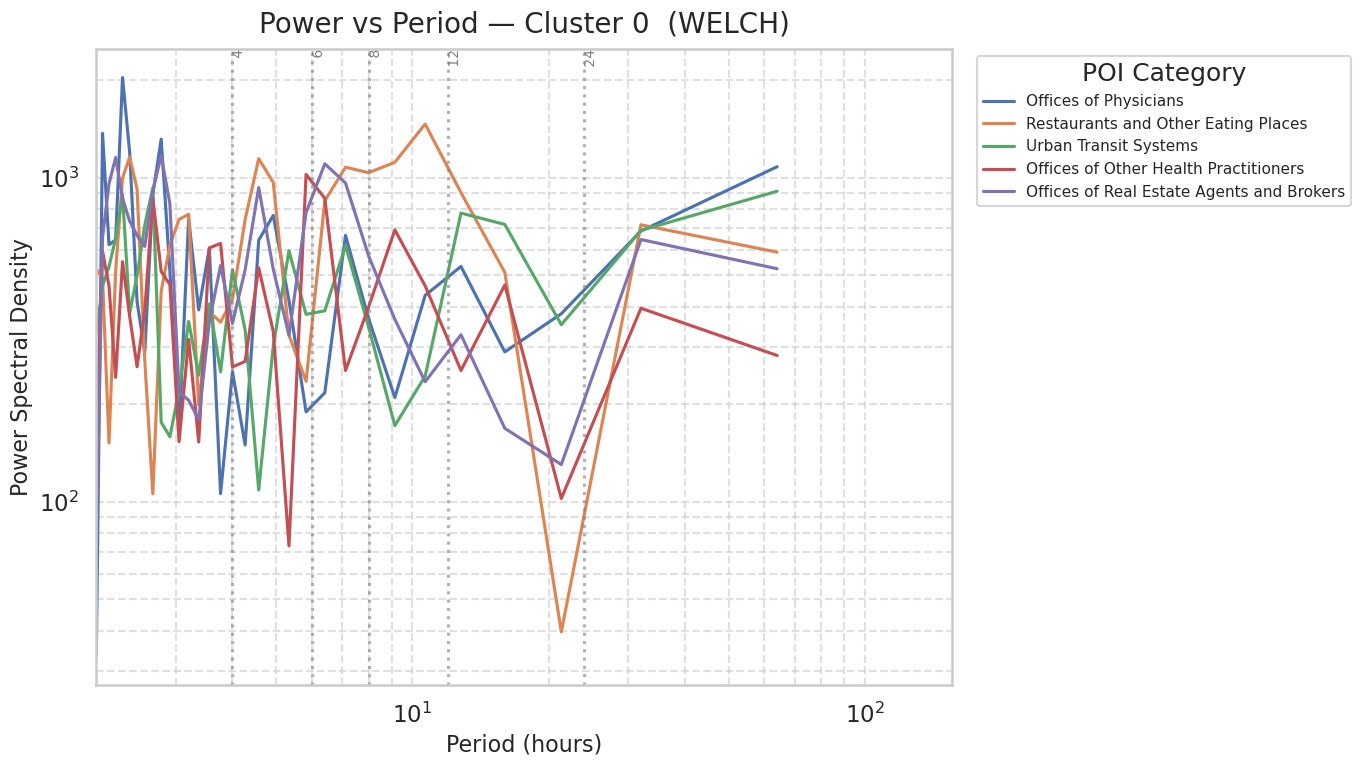

Plot saved to ./tod_cluster_results/fft_period_plot_cluster_0_periodogram.png


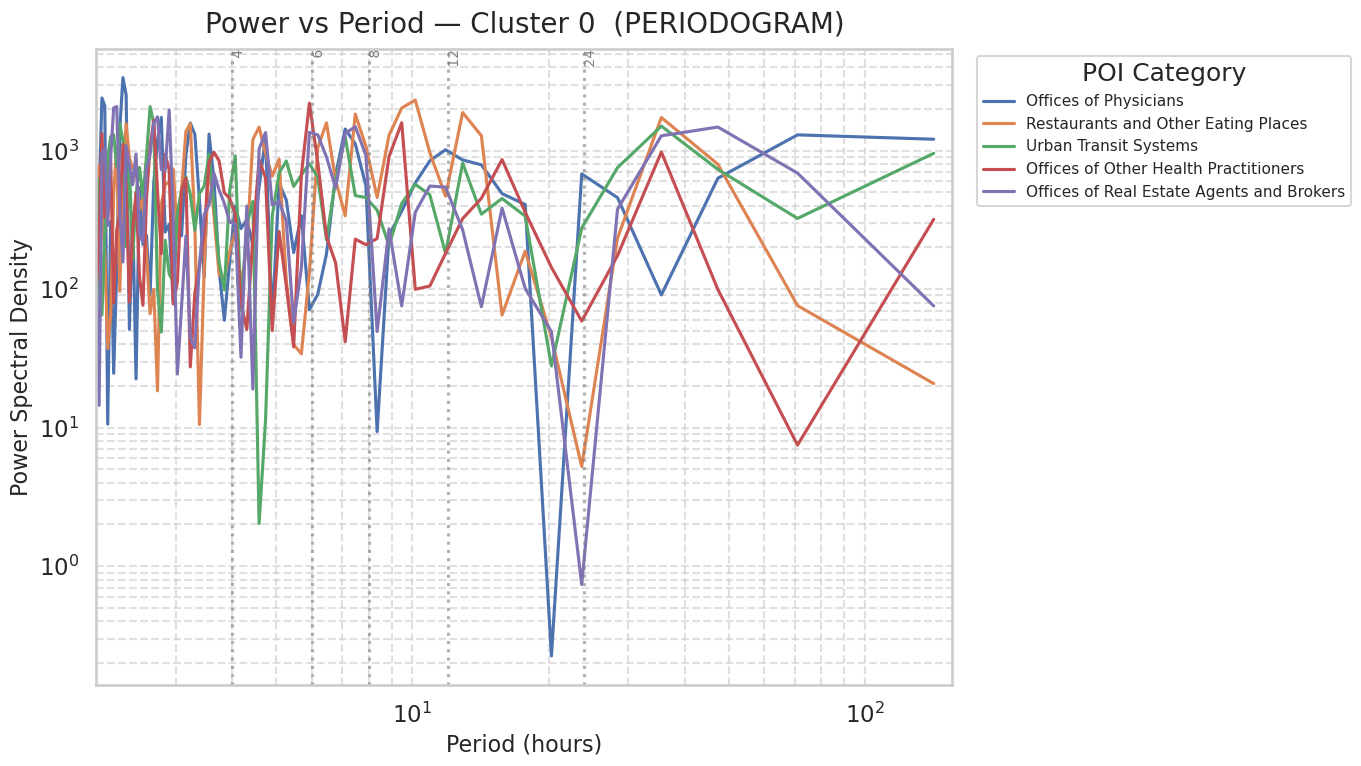

Plot saved to ./tod_cluster_results/fft_period_plot_cluster_0_fft.png


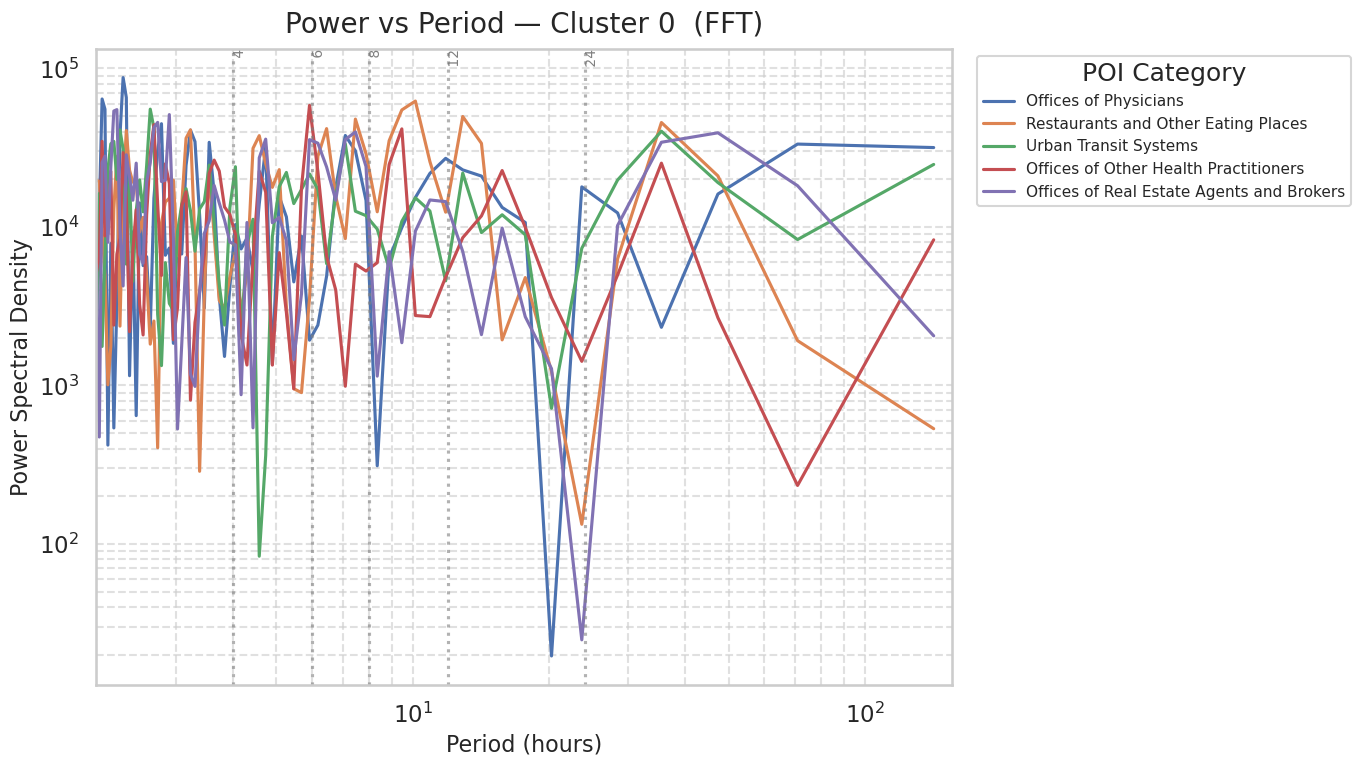

In [85]:
# Period units are hours if dt=1.0 hour; annotate daily harmonics
ann = [24, 12, 8, 6, 4]    # hours

_ = analyze_and_plot_fft_by_period(df_diff, cluster_id=0, num_top_categories=5,
                                   dt=1.0, period_units="hours",
                                   method="welch", annotate_periods=ann)

_ = analyze_and_plot_fft_by_period(df_diff, cluster_id=0, num_top_categories=5,
                                   dt=1.0, period_units="hours",
                                   method="periodogram", annotate_periods=ann)

_ = analyze_and_plot_fft_by_period(df_diff, cluster_id=0, num_top_categories=5,
                                   dt=1.0, period_units="hours",
                                   method="fft", annotate_periods=ann)


In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_and_plot_fft_by_period(
    df_cluster: pd.DataFrame,
    cluster_id,
    num_top_categories: int = 5,
    *,
    # NEW: which signal to analyze
    value_kind: str = "delta",     # "delta" | "prop" | "count"
    global_df: pd.DataFrame | None = None,
    percent: bool = True,          # only used for value_kind="delta"
    whiten: bool = False,          # z-score each series before PSD
    # spectrum params
    dt: float = 1.0,
    period_units: str = "time steps",
    method: str = "welch",         # "welch" | "periodogram" | "fft"
    nperseg: int | None = None,
    window: str = "hann",
    detrend: str = "constant",     # "constant" | "linear" | None
    scaling: str = "density",
    annotate_periods: list[float] | None = None,
    ylim: tuple[float, float] | None = None,
    savepath: str | None = None
):
    """
    df_cluster: counts or proportions per category over time (T x C).
    If value_kind="delta" or "prop", df_cluster is assumed to be COUNTS
    (we'll convert to proportions internally). If you already pass proportions,
    set value_kind="prop" and it will still work (division by row sum is idempotent).
    """
    sns.set_theme(style="whitegrid", context="talk")
    T = len(df_cluster.index)
    if T < 4:
        print(f"[Cluster {cluster_id}] Too few points (T={T})")
        return pd.DataFrame()

    # ---------- build the signal matrix X (T x C) ----------
    # helper to row-normalize to proportions
    def to_prop(df):
        return df.div(df.sum(axis=1).replace(0, 1), axis=0)

    if value_kind == "count":
        X = df_cluster.sort_index().astype(float)
    elif value_kind == "prop":
        X = to_prop(df_cluster).sort_index().astype(float)
    elif value_kind == "delta":
        if global_df is None:
            raise ValueError("global_df is required when value_kind='delta'.")
        cl_prop = to_prop(df_cluster).sort_index()
        gl_prop = to_prop(global_df).reindex(index=cl_prop.index, columns=cl_prop.columns, fill_value=0.0)
        X = (cl_prop - gl_prop)
        if percent:
            X = X * 100.0  # percentage points
    else:
        raise ValueError("value_kind must be 'delta', 'prop', or 'count'")

    # pick top categories by variance under the chosen signal
    top_categories = X.var().nlargest(num_top_categories).index.tolist()
    if len(top_categories) == 0:
        print(f"[Cluster {cluster_id}] No categories to plot.")
        return pd.DataFrame()

    X = X[top_categories]

    # ---------- PSD computation ----------
    fs = 1.0 / dt
    from numpy.fft import rfft, rfftfreq
    try:
        from scipy import signal
        _has_scipy = True
    except Exception:
        _has_scipy = False

    if nperseg is None:
        pow2 = 1 << max(3, int(np.floor(np.log2(max(8, T // 2)))))
        nperseg = min(T, pow2)

    rows = []
    for cat in top_categories:
        y = X[cat].astype(float).copy()
        y = y.interpolate(limit_direction="both")  # fill gaps
        # detrend first
        if detrend in ("constant", "linear"):
            if _has_scipy:
                yv = signal.detrend(y.values, type=detrend)
            else:
                if detrend == "constant":
                    yv = y.values - y.values.mean()
                else:
                    t = np.arange(T)
                    yv = y.values - np.polyval(np.polyfit(t, y.values, 1), t)
        else:
            yv = y.values
        # optional whitening for shape-only comparison
        if whiten:
            std = np.std(yv)
            if std > 1e-12:
                yv = (yv - np.mean(yv)) / std

        if method.lower() == "welch" and _has_scipy:
            f, Pxx = signal.welch(
                yv, fs=fs, window=window, nperseg=min(nperseg, T),
                noverlap=None, detrend=False, return_onesided=True,
                scaling=scaling, average="mean"
            )
            mask = f > 0
            f, Pxx = f[mask], Pxx[mask]
        elif method.lower() == "periodogram" and _has_scipy:
            f, Pxx = signal.periodogram(
                yv, fs=fs, window=window, detrend=False,
                return_onesided=True, scaling=scaling
            )
            mask = f > 0
            f, Pxx = f[mask], Pxx[mask]
        else:
            win = np.hanning(T) if window == "hann" else np.ones(T)
            yw = yv * win
            Pxx = np.abs(rfft(yw))**2
            f = rfftfreq(T, d=dt)
            mask = f > 0
            f, Pxx = f[mask], Pxx[mask]

        period = 1.0 / f
        order = np.argsort(period)
        rows.append(pd.DataFrame({
            "Period": period[order],
            "Power":  Pxx[order],
            "Category": cat
        }))

    long_df = pd.concat(rows, ignore_index=True)

    # ---------- plot ----------
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.lineplot(data=long_df, x="Period", y="Power", hue="Category", ax=ax, legend=True)
    ax.set_xscale("log"); ax.set_yscale("log")
    pretty_kind = {"delta":"Δ (cluster−global)", "prop":"Proportion (cluster)", "count":"Count"}[value_kind]
    units = " (pp)" if (value_kind=="delta" and percent) else ""
    ax.set_title(f"Power vs Period — Cluster {cluster_id} — {pretty_kind}{units}", fontsize=20, pad=12)
    ax.set_xlabel(f"Period ({period_units})", fontsize=16)
    ax.set_ylabel("Power" + (" Spectral Density" if scaling=="density" else ""), fontsize=16)
    ax.grid(True, which="both", linestyle="--", alpha=0.6)

    # annotate reference periods
    if annotate_periods:
        for p in annotate_periods:
            ax.axvline(p, color="gray", linestyle=":", alpha=0.6)
            ax.text(p, ax.get_ylim()[1], f" {p:g}", rotation=90, va="top", ha="left", fontsize=10, color="gray")

    xmin = max(2.0 * dt, long_df["Period"].min() * 0.9)
    xmax = (T * dt) * 1.1
    ax.set_xlim(xmin, xmax)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend(title="POI Category", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, fontsize=11)
    plt.tight_layout()

    if savepath is None:
        suffix = f"{value_kind}{'_pp' if (value_kind=='delta' and percent) else ''}_{method}"
        savepath = f"./tod_cluster_results/fft_period_plot_cluster_{cluster_id}_{suffix}.png"
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    print(f"Plot saved to {savepath}")
    plt.show()
    return long_df


In [100]:
print()

'/storage1/fs1/nlin/Active/sizhe/FO_DATA'

Plot saved to ./tod_cluster_results/fft_period_plot_cluster_0_count_welch.png


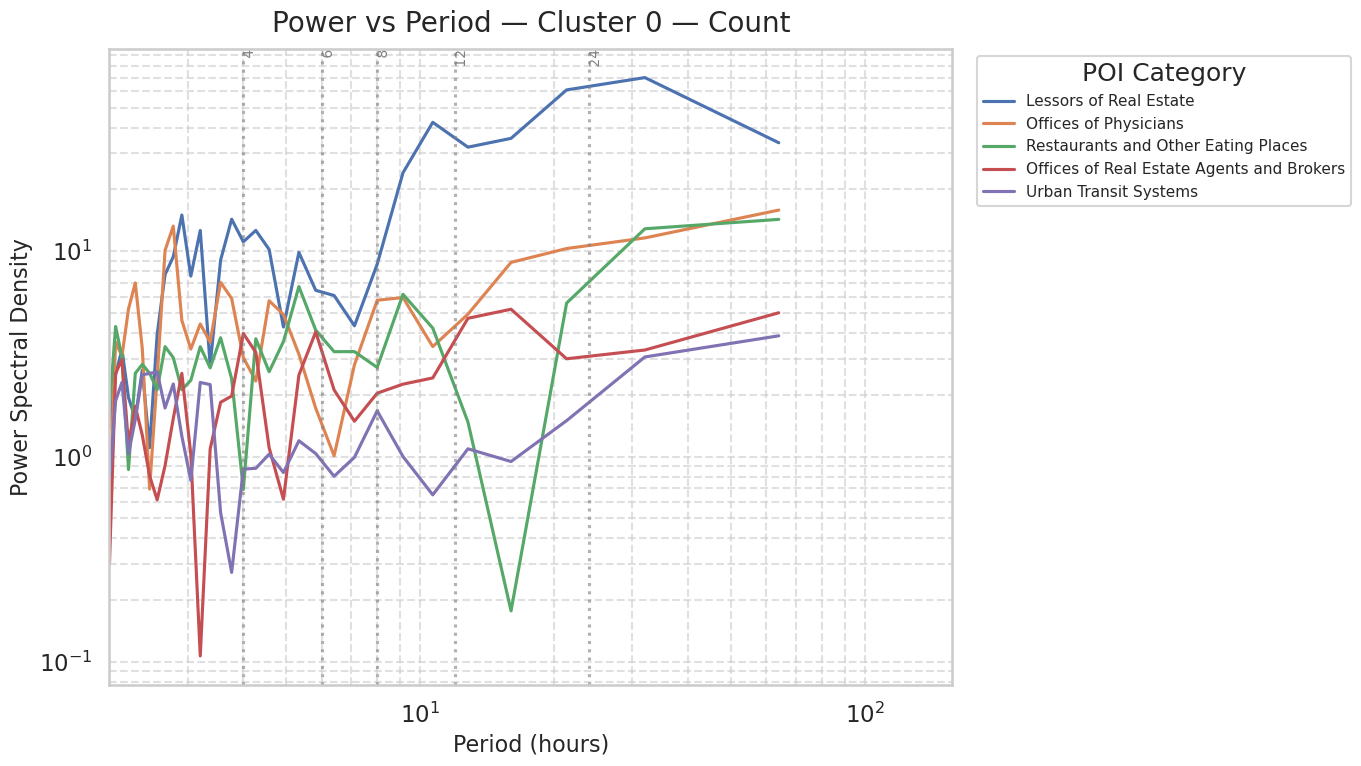

Plot saved to ./tod_cluster_results/fft_period_plot_cluster_1_count_welch.png


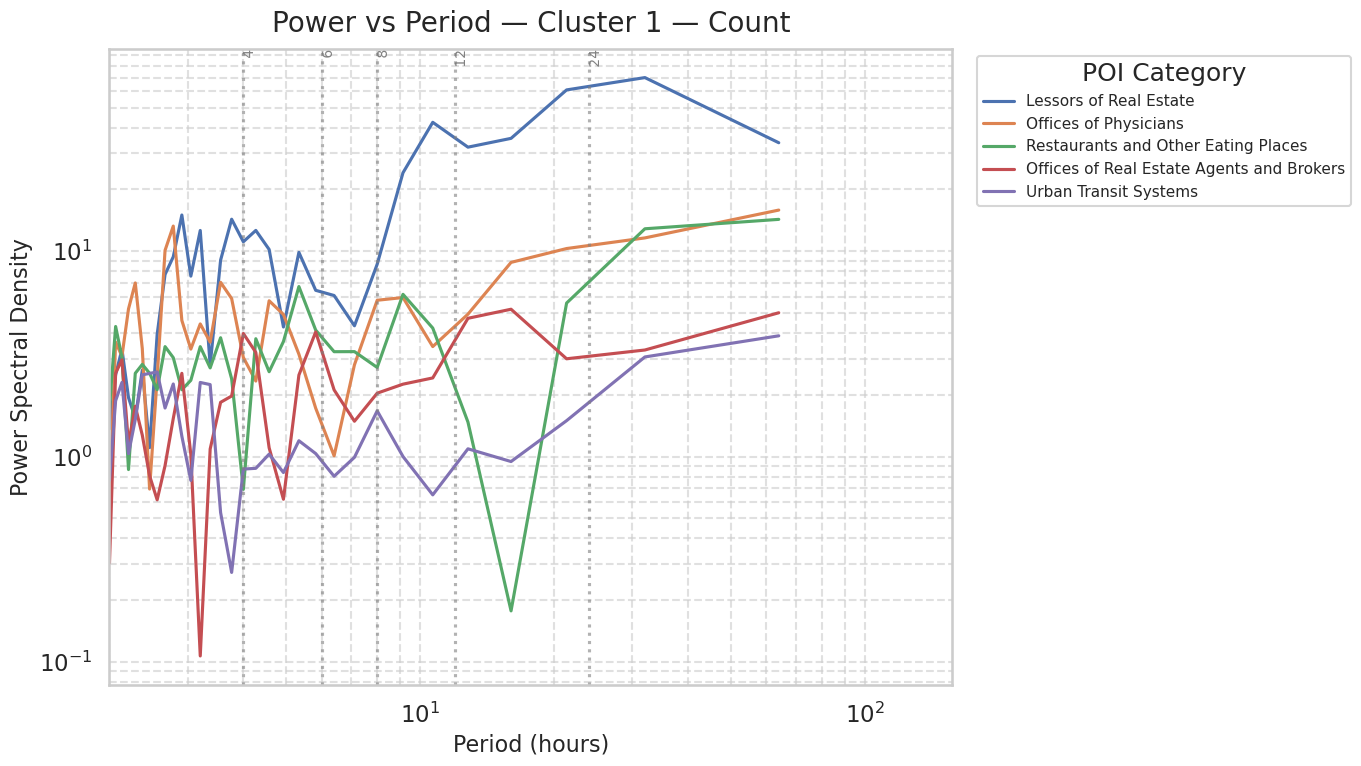

Plot saved to ./tod_cluster_results/fft_period_plot_cluster_2_count_welch.png


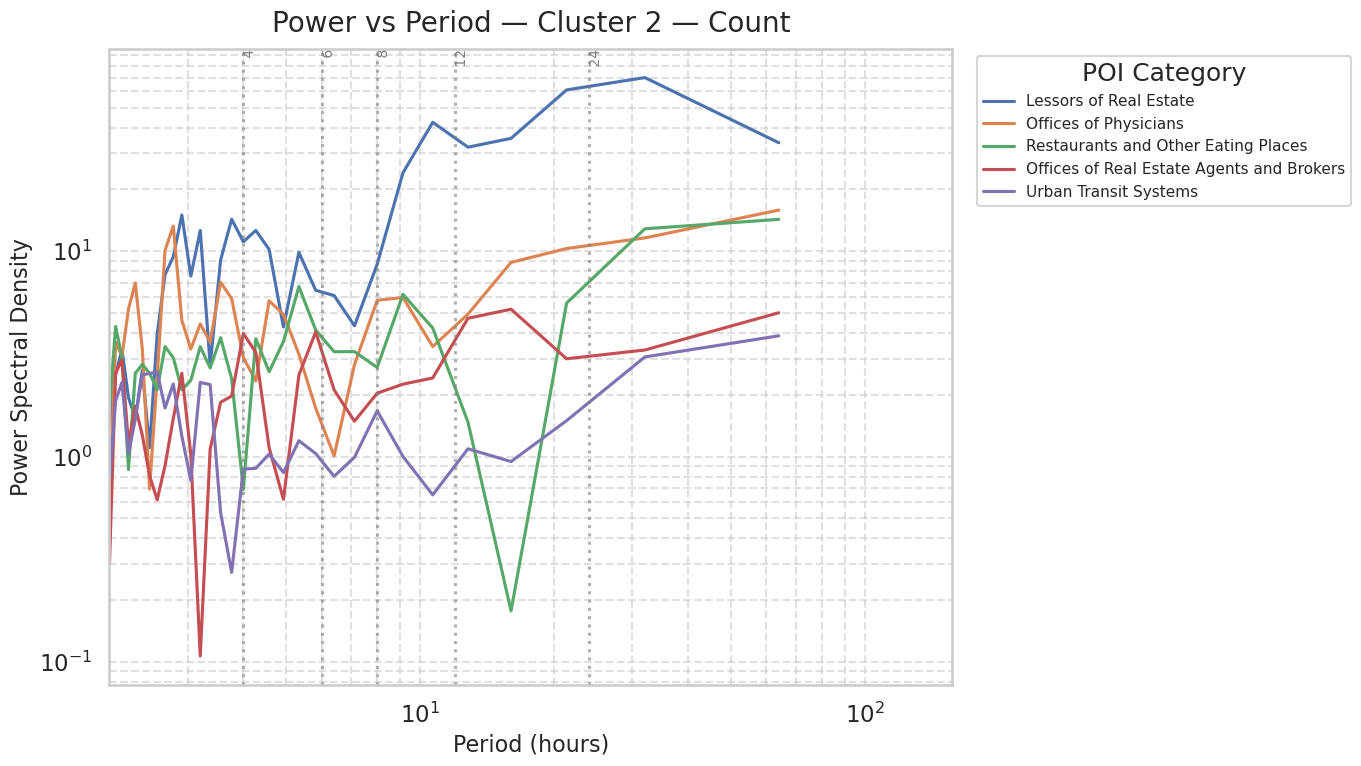

Plot saved to ./tod_cluster_results/fft_period_plot_cluster_3_count_welch.png


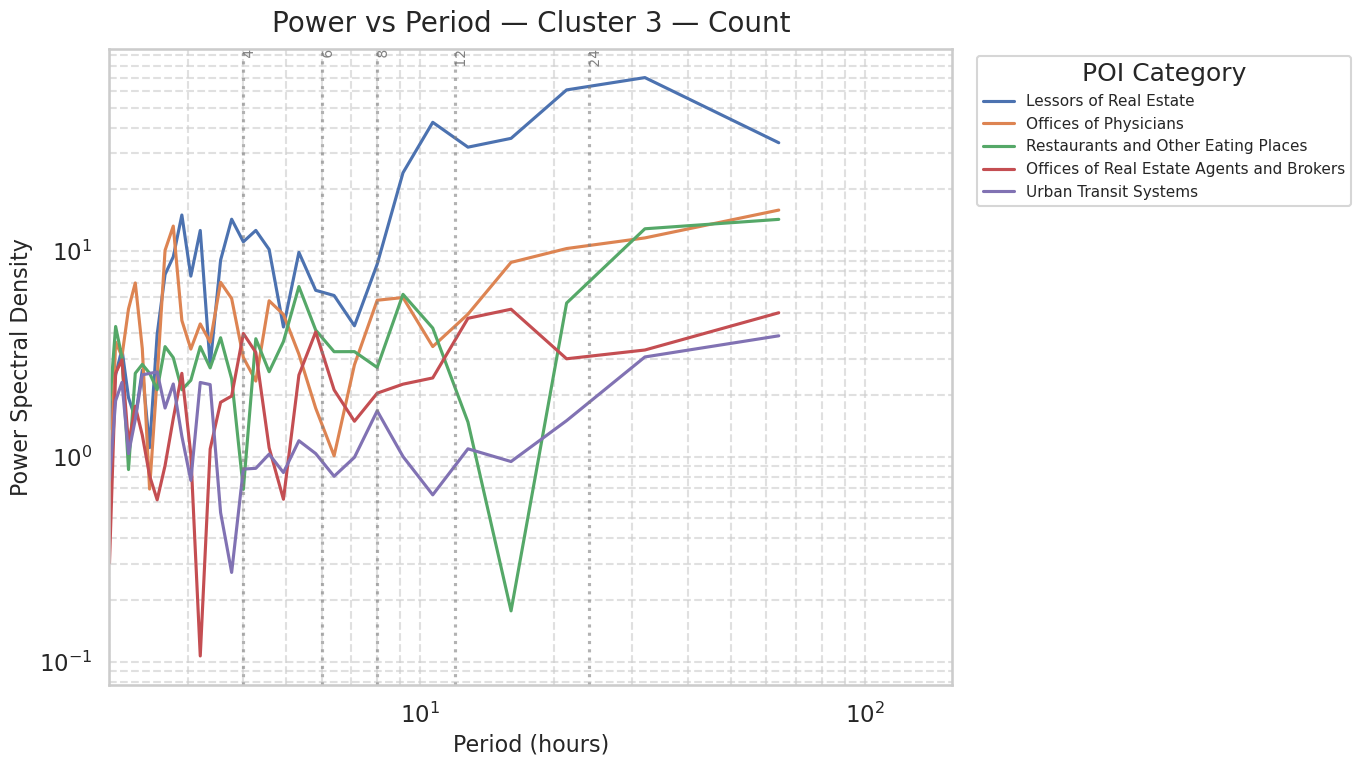

Plot saved to ./tod_cluster_results/fft_period_plot_cluster_4_count_welch.png


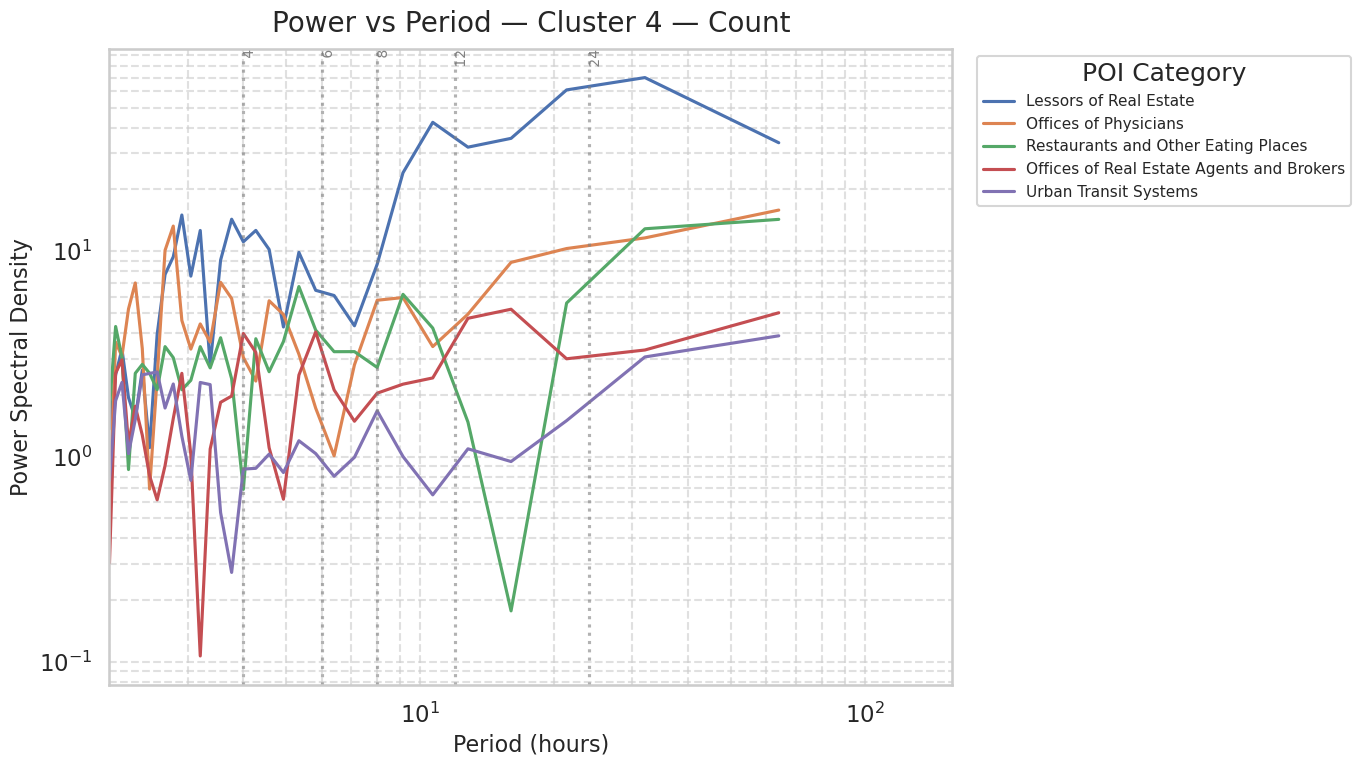

In [99]:
for i in range(5):
    _ = analyze_and_plot_fft_by_period(
            df_cluster=df_counts_cat_by_cluster[0],
        cluster_id=i,
        value_kind="count",         # <-- proportions of the cluster itself
        dt=1.0, period_units="hours",
        method="welch", annotate_periods=[24,12,8,6,4],
    )


In [63]:
len(point_gdf)/(95410*143)

0.1229372241844729

In [113]:
df_full

,cluster,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,...,z_54,z_55,z_56,z_57,z_58,z_59,z_60,z_61,z_62,z_63
traj_id,,,,,,,,,,,,,,,,,,,,,
0000a204849023cd902b8c7dd9edc37b8bbc222edbe6620b26b852a3e24b317c,0,-0.016771,-0.001483,-0.002527,0.007222,-0.002190,0.008285,-0.019030,0.007321,0.007677,...,0.005641,0.001101,-0.004430,-0.011695,-0.023660,-0.004164,-0.018098,0.016560,-0.006653,0.010379
0000a70c6bce971755183b6155d263a1db3027e6ead671a9401a85052d4d424e,1,-0.012937,-0.017802,0.009080,-0.005825,-0.000865,0.027781,0.038929,-0.009934,-0.000369,...,-0.027474,0.052340,-0.016712,0.019182,-0.047034,0.041683,0.032674,0.007857,0.010552,0.001380
0000d1f90748a756d45a2c6ac8489bb6db9c9bfa96c1d255867864e26de3bc52,0,-0.003439,-0.003079,-0.002167,-0.003142,-0.000628,0.006895,-0.000907,0.005760,0.004924,...,0.002446,0.006642,-0.005272,-0.002080,-0.009599,0.010200,0.002838,0.005130,0.002167,0.000047
0001cb486921957ec892d0d3ab7f13e22926223e16518e8175b110296186391a,1,0.014246,0.016490,0.004716,-0.003243,-0.004549,0.000664,0.016643,0.018153,-0.000190,...,-0.016423,-0.004273,-0.016565,-0.002570,-0.007826,-0.014716,0.019769,0.020243,0.037931,-0.003633
0001e79f8ecb5fd97d9ef38485f2dad1fe7438b0e00528f2b001266666fd3f87,2,-0.002057,0.015496,0.004091,-0.004663,0.000683,0.009320,0.007286,0.003244,-0.002536,...,-0.001905,-0.012813,0.005927,0.001993,0.006118,0.009945,-0.009945,-0.023205,-0.008892,-0.000490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fff9bae85a579ad59c12eae1ebf531f82d7d2f5fc2ca002f9e3fff31d2839ed3,0,-0.000064,-0.007463,-0.003198,-0.010556,-0.000741,0.001123,-0.000404,0.005863,-0.002253,...,-0.003828,-0.001133,0.002784,-0.001991,0.002780,0.001099,0.006009,0.004764,0.003838,0.003406
fffe4d7714d585aea3af8e27cb238b478ad60946ad5fc5099247ee73ae8d5285,0,0.002110,-0.001654,-0.007093,0.014024,-0.003327,0.004887,-0.019628,0.012206,0.006518,...,0.016963,-0.000068,-0.003343,0.003729,-0.006788,-0.002138,0.001619,-0.026658,-0.003667,0.010761
fffe9537d2c043261c11213c802ef681346fcd1f7c0b3c46c55d4ba9ae79c434,0,0.005704,0.006048,0.005857,-0.000410,-0.004661,0.004129,-0.016429,0.000060,0.004609,...,-0.007882,0.002359,0.001825,-0.002630,-0.011984,0.003600,-0.006951,0.007310,0.004316,0.000262


In [115]:
Z.shape

(95410, 64)

N=95410, D=64, K=5


Selecting reps:   0%|          | 0/5 [00:00<?, ?it/s]

Per-cluster counts among reps: {0: 500, 1: 500, 2: 500, 3: 500, 4: 500}
Z_reps: (2500, 64) labels_reps: (2500,)


/storage1/fs1/nlin/Active/sizhe/sizhe/envs/geospatial/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


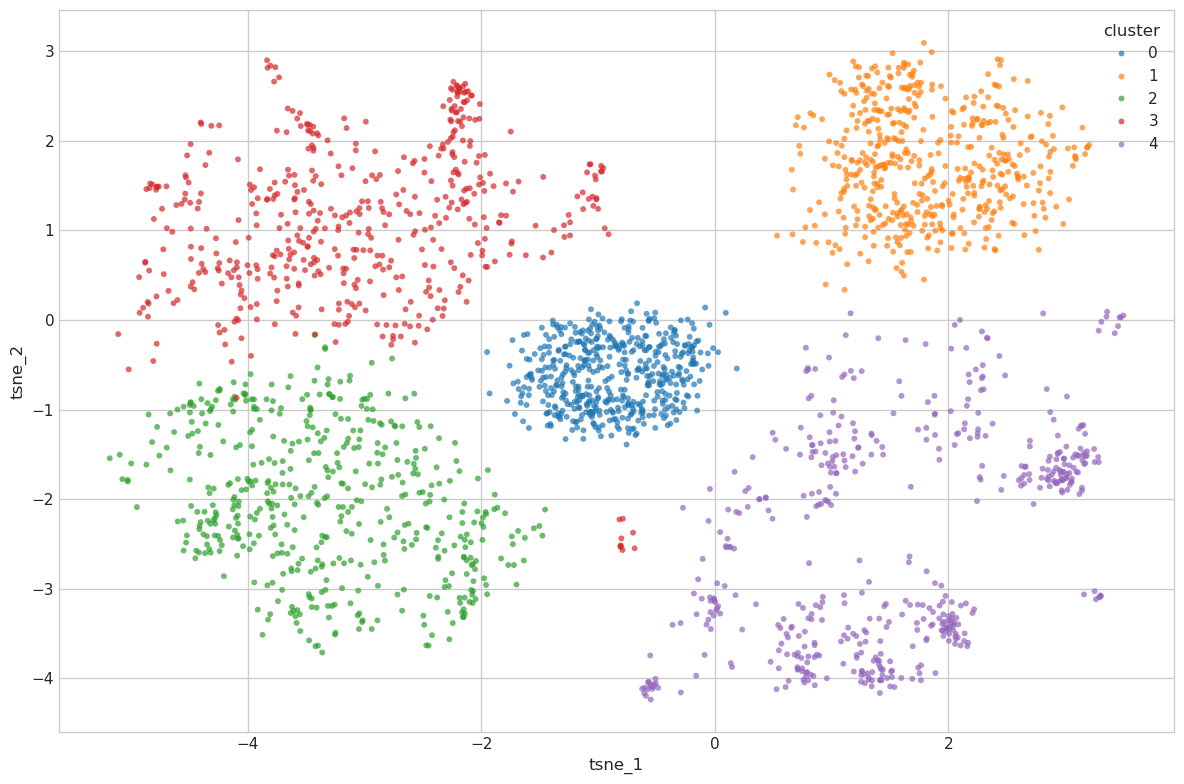

In [119]:
import re
import numpy as np
import pandas as pd

# ---------- 1) Extract from df_full ----------
# Embedding columns (z_0, z_1, ..., z_D-1)
emb_cols = sorted([c for c in df_full.columns if c.startswith("z_")],
                  key=lambda s: int(s.split("_")[1]))
assert len(emb_cols) > 0, "No z_* columns found."

# Cluster labels (handle ints or strings like "Cluster 0")
lab_ser = df_full["cluster"]

def _parse_cluster_label(s):
    if pd.api.types.is_integer_dtype(lab_ser.dtype):
        return int(s)
    m = re.search(r"-?\d+", str(s))
    if not m:
        raise ValueError(f"Cannot parse cluster id from label: {s!r}")
    return int(m.group())

labels = lab_ser.map(_parse_cluster_label).to_numpy(dtype=int)

# Embeddings and row ids
Z = df_full[emb_cols].to_numpy(dtype=np.float32)     # (N, D)
traj_ids = df_full.index.to_numpy()                  # keep the original ids

K = labels.max() + 1
print(f"N={Z.shape[0]}, D={Z.shape[1]}, K={K}")

# ---------- 2) Centroids ----------
# If you already have kmeans.cluster_centers_, use that instead.
centers = np.zeros((K, Z.shape[1]), dtype=np.float32)
for c in range(K):
    members = (labels == c)
    if members.any():
        centers[c] = Z[members].mean(axis=0)
    else:
        centers[c] = 0.0

# ---------- 3) Representatives per cluster ----------
from tqdm.auto import tqdm

def find_representatives_from_df(Z, labels, centers, m_per_cluster=500):
    reps_Z, reps_y, reps_idx, reps_dist = [], [], [], []
    for c in tqdm(range(centers.shape[0]), desc="Selecting reps"):
        idx_c = np.flatnonzero(labels == c)
        if idx_c.size == 0:
            continue
        Zc = Z[idx_c]
        d  = np.linalg.norm(Zc - centers[c], axis=1)
        finite = np.isfinite(d)
        idx_c, d = idx_c[finite], d[finite]
        k = int(min(m_per_cluster, d.size))
        if k <= 0:
            continue
        # pick k closest without sorting everything
        sel_unsorted = np.argpartition(d, k-1)[:k]
        order = np.argsort(d[sel_unsorted])
        sel_local = sel_unsorted[order]
        sel_global = idx_c[sel_local]
        reps_Z.append(Z[sel_global])
        reps_y.append(np.full(k, c, dtype=int))
        reps_idx.append(sel_global)
        reps_dist.append(d[sel_local])

    if not reps_Z:
        return (np.empty((0, Z.shape[1])), np.empty((0,), int),
                np.empty((0,), int), np.empty((0,), float))

    Z_rep   = np.vstack(reps_Z)
    y_rep   = np.concatenate(reps_y)
    idx_rep = np.concatenate(reps_idx)
    d_rep   = np.concatenate(reps_dist)
    return Z_rep, y_rep, idx_rep, d_rep

m = 500
Z_reps, labels_reps, idx_reps, d_reps = find_representatives_from_df(Z, labels, centers, m_per_cluster=m)

print("Per-cluster counts among reps:",
      pd.Series(labels_reps).value_counts().sort_index().to_dict())
print("Z_reps:", Z_reps.shape, "labels_reps:", labels_reps.shape)

# ---------- 4) Reps DataFrame (handy for saving / inspection) ----------
reps_df = df_full.iloc[idx_reps].copy()
reps_df["cluster_int"] = labels_reps
reps_df["dist_to_center"] = d_reps
# Example: save top 500 per cluster with distances
# reps_df.to_csv("representatives_by_cluster.csv")

# ---------- 5) t-SNE on representatives ----------
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

def tsne_visualize(Z, labels, out_path="tsne_reps.png", pca_dim=50,
                   perplexity=None, n_iter=2000, random_state=42):
    Z = np.asarray(Z); labels = np.asarray(labels)
    N, D = Z.shape
    Zs = StandardScaler().fit_transform(Z)
    # auto-cap PCA components
    if pca_dim is not None:
        ncomp = min(pca_dim, max(2, min(N-1, D)))
        Z_in = PCA(n_components=ncomp, random_state=random_state).fit_transform(Zs)
    else:
        Z_in = Zs
    if perplexity is None:
        perplexity = N//3+1
        #perplexity = min(perplexity, max(2, N-1))
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter,
                learning_rate='auto', init='pca', random_state=random_state)
    Y = tsne.fit_transform(Z_in)
    df = pd.DataFrame({"tsne_1":Y[:,0], "tsne_2":Y[:,1], "cluster":labels})
    K = df["cluster"].nunique()
    pal = sns.color_palette("tab10", n_colors=min(10, K)) if K<=10 else sns.color_palette("tab20", n_colors=min(20,K))
    plt.figure(figsize=(12,8))
    sns.scatterplot(data=df, x="tsne_1", y="tsne_2", hue="cluster",
                    palette=pal, s=18, alpha=0.7, linewidth=0)
    plt.tight_layout(); plt.savefig(out_path, dpi=300); plt.show()
    return df

tsne_df = tsne_visualize(Z_reps, labels_reps, out_path="./tod_cluster_results/tsne_cluster_visualization_from_df_full.png")


In [120]:
Z_reps

array([[-8.4521115e-04,  1.7247771e-04, -2.9673795e-03, ...,
         2.4908856e-03,  6.6407368e-04,  1.1953788e-03],
       [ 5.9057886e-05, -4.3437321e-04, -1.1734577e-03, ...,
         4.5015686e-03,  7.0491090e-04,  3.3572682e-03],
       [ 5.8012980e-04, -4.3950849e-03,  7.5575837e-04, ...,
         7.4094809e-03, -1.5739836e-03,  1.2193747e-03],
       ...,
       [-2.3988693e-03,  1.2344236e-03,  3.2107057e-03, ...,
         5.4190601e-03, -5.5161947e-03, -1.4785206e-02],
       [ 1.0429767e-02,  3.2688256e-03,  1.3963868e-02, ...,
        -1.7647624e-02,  9.3401730e-04, -1.2854541e-02],
       [ 6.3011665e-03,  7.6783705e-03, -6.6406368e-03, ...,
         9.2915008e-03,  1.6232923e-02, -7.1352010e-04]], dtype=float32)

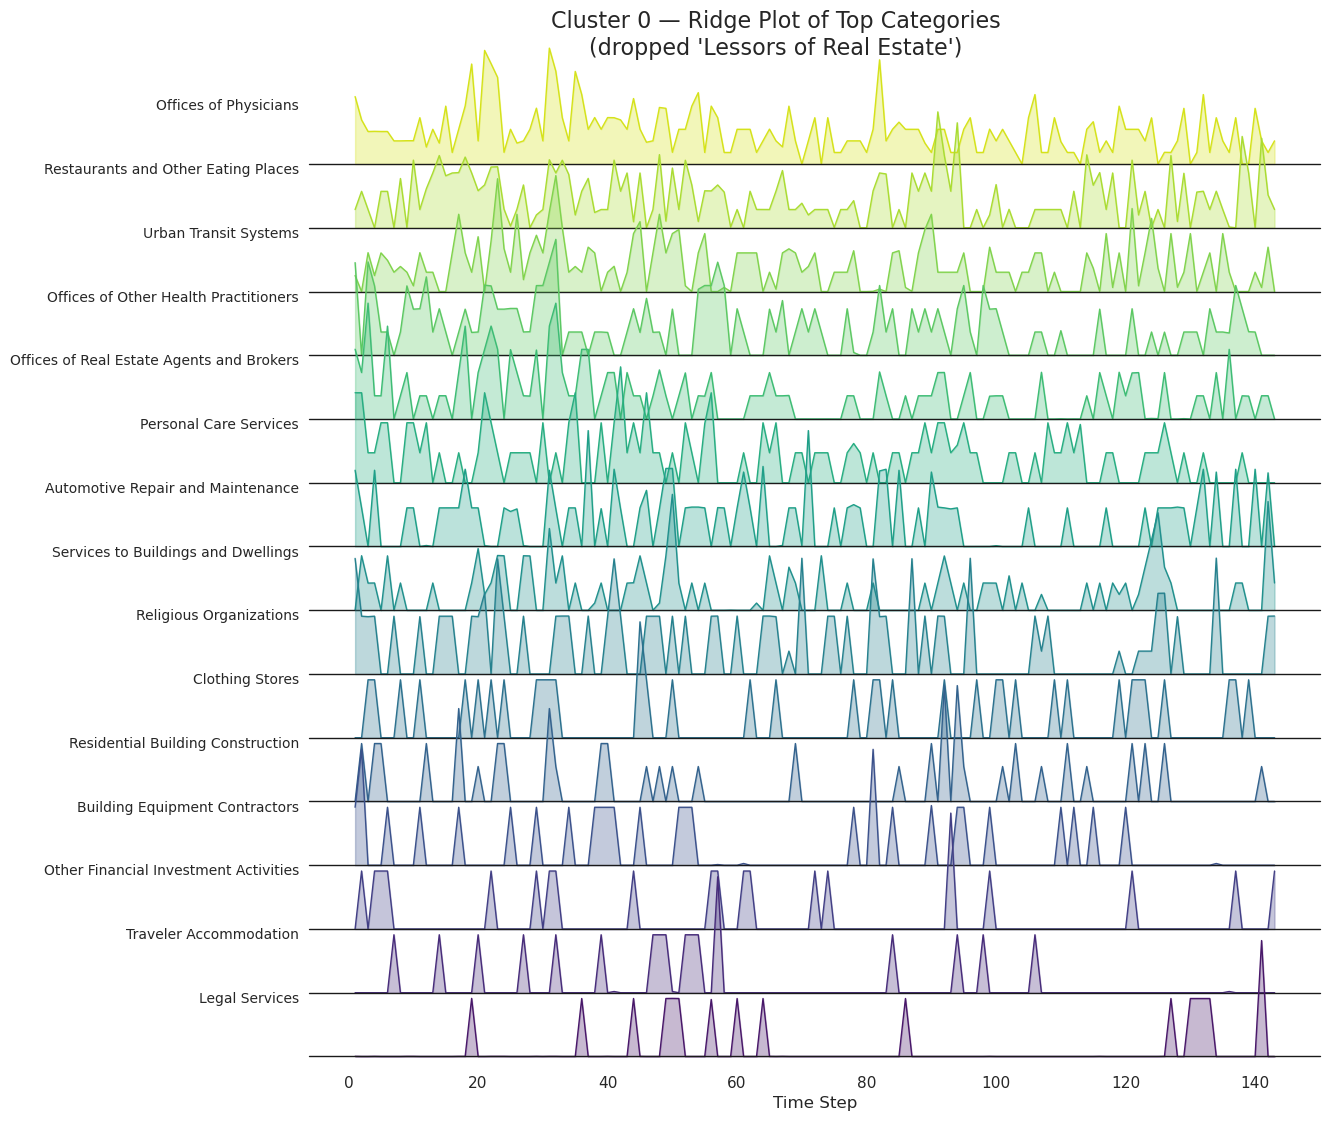

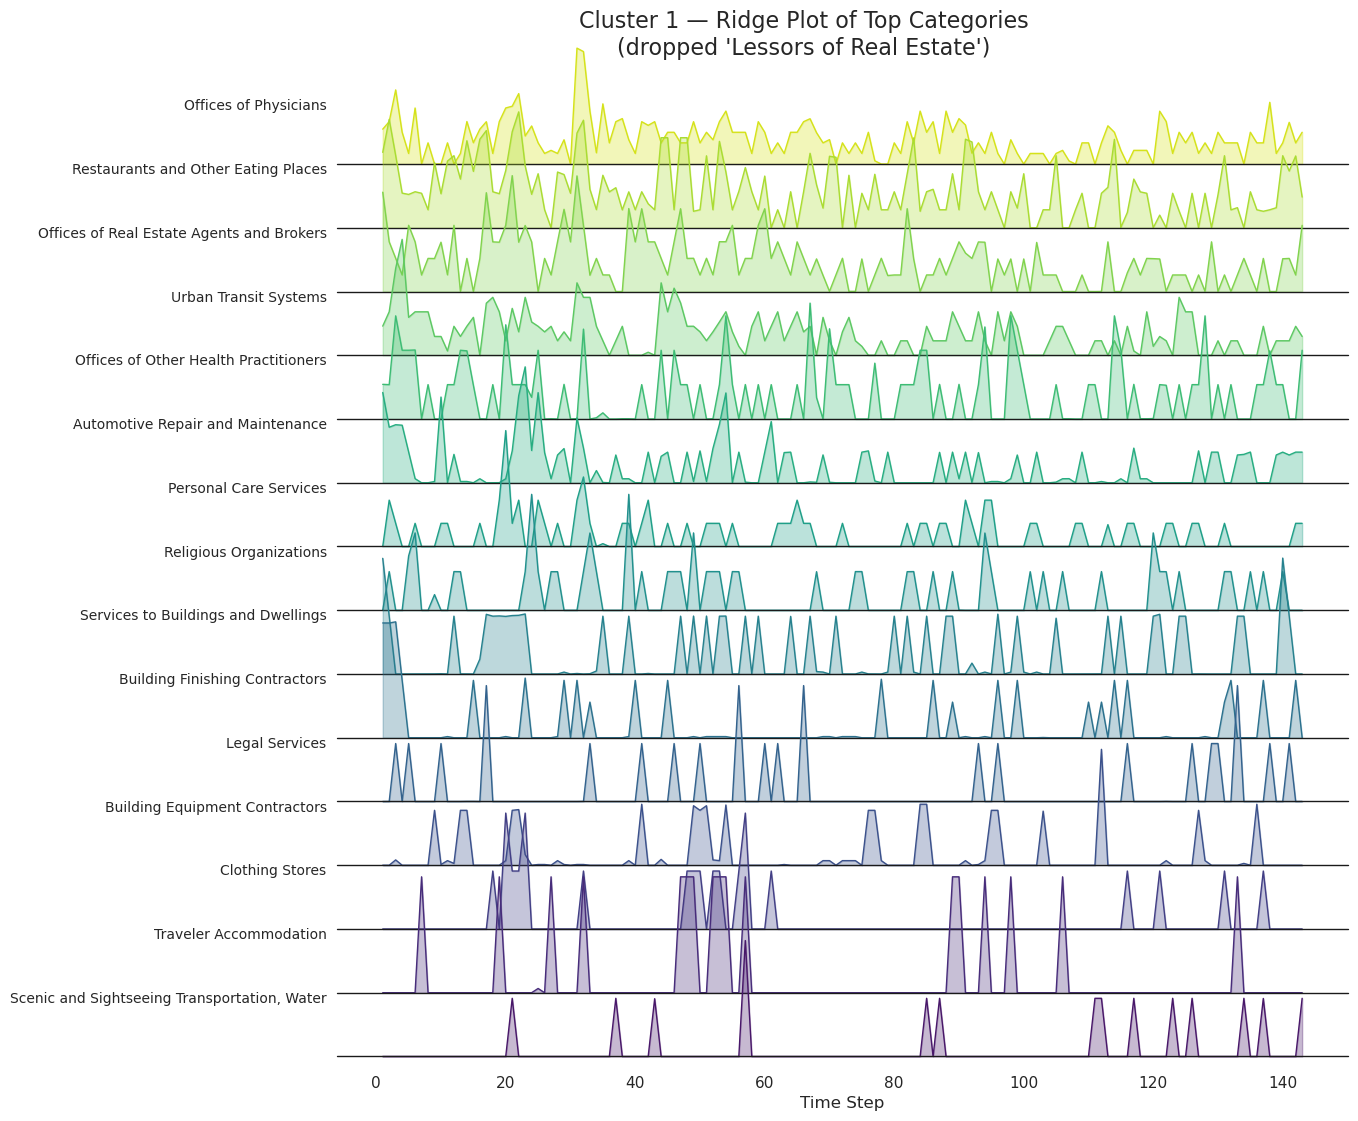

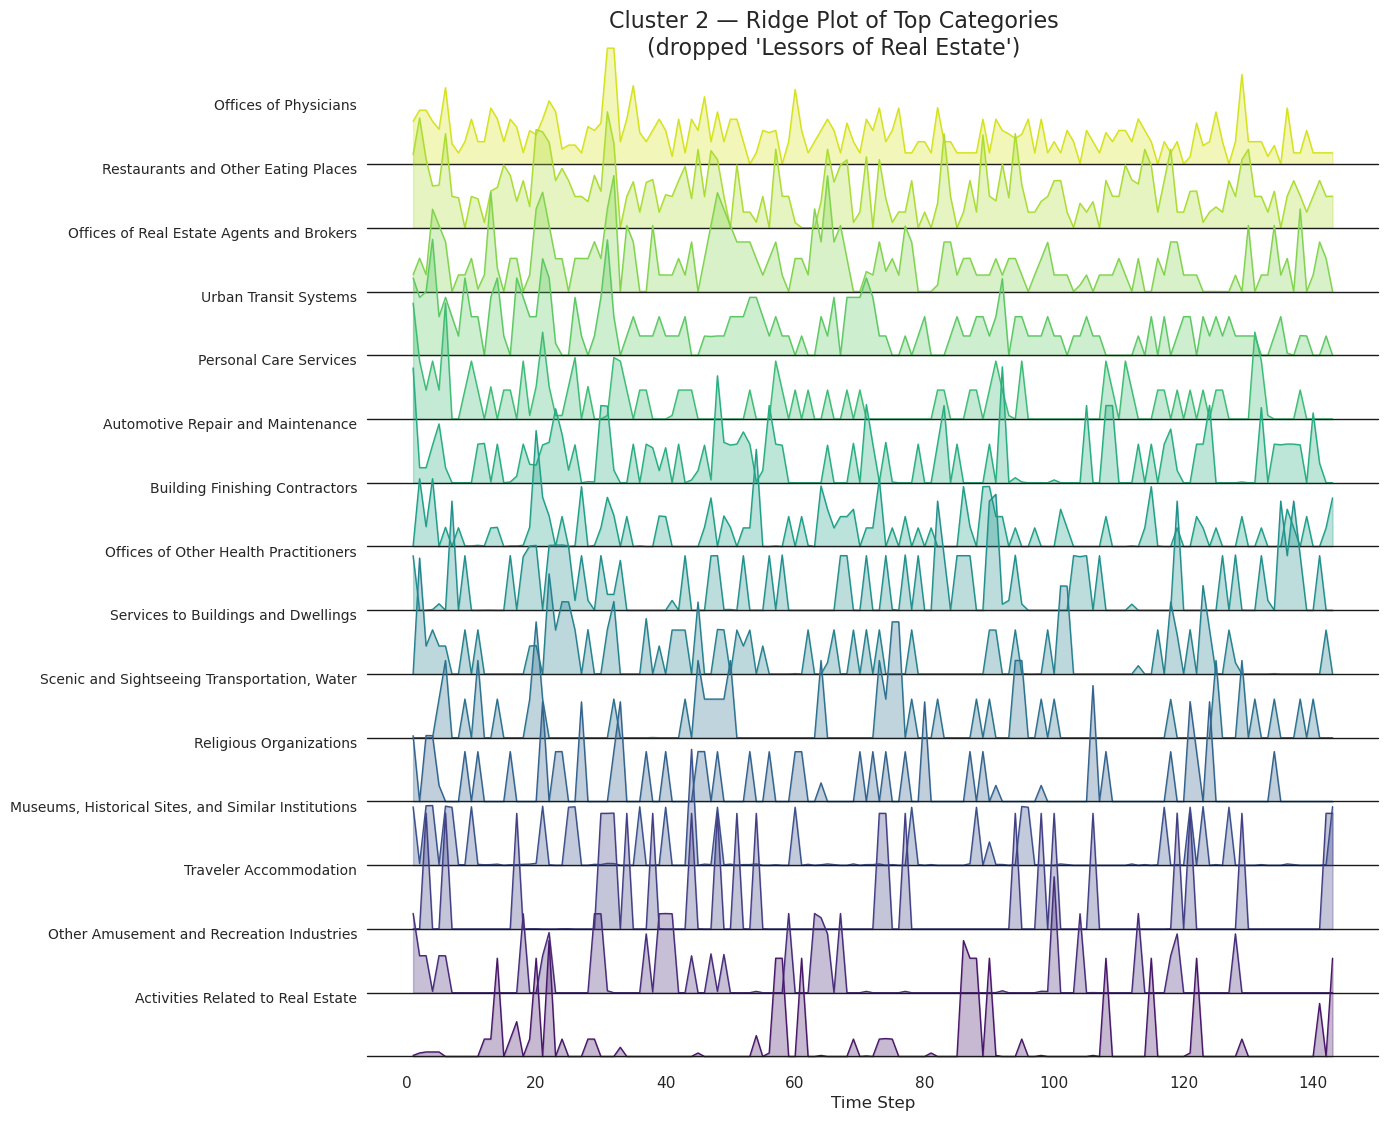

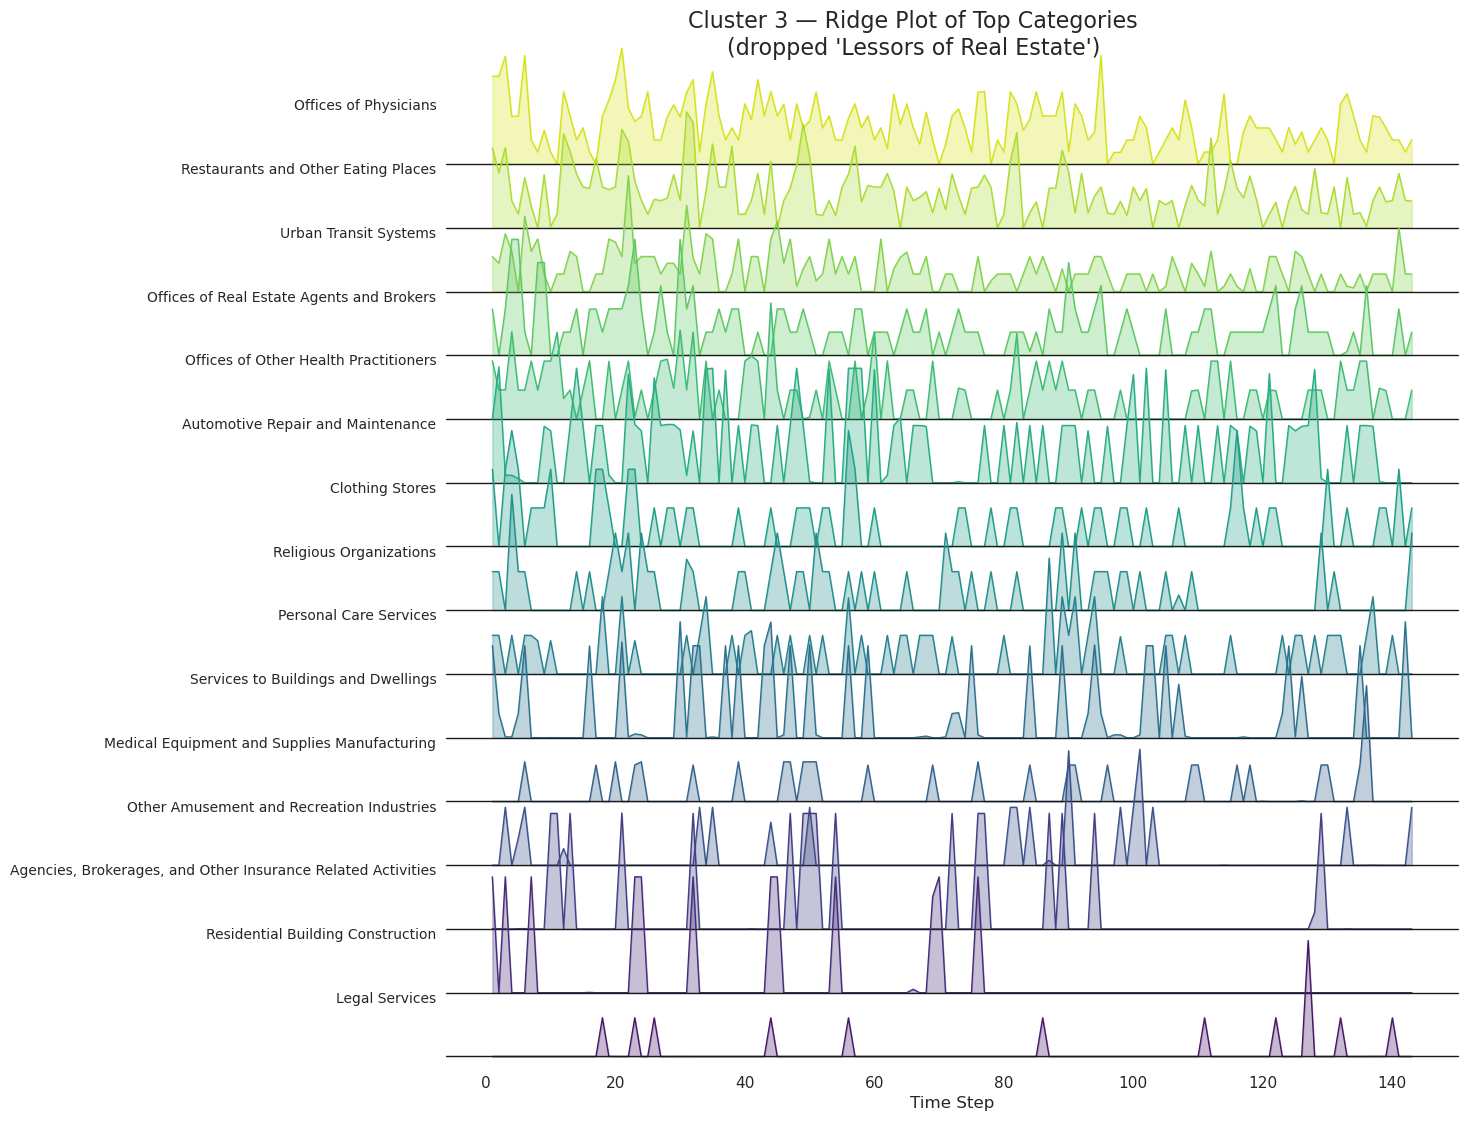

In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Full Ridge Plot Code for Top Categories by Cluster
# ---------------------------------------------------

# 0) Set the seaborn style for better aesthetics
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# 1) Assume df_counts_cat_by_cluster is already defined:
#    a dict mapping cluster index → DataFrame of shape (pt_idx × category),
#    where each cell is the (possibly normalized) count or score.

for cluster_i, df_cat in df_counts_cat_by_cluster.items():
    # 2) Pick this cluster’s own top-20 categories by total volume
    totals = df_cat.sum(axis=0)
    top_n  = min(20, len(totals))
    if top_n <= 1:
        print(f"Cluster {cluster_i} has fewer than 2 categories, skipping.")
        continue
    top20 = totals.nlargest(top_n).index.tolist()

    # 3) Drop the very most‐frequent category and keep the next 15
    most_freq = top20[0]
    selected  = top20[1:16]   # 15 categories for a cleaner ridge plot

    # 4) Subset and sort by time‐step (pt_idx)
    df_sel = df_cat[selected].sort_index()

    # 5) Column‐normalize each category so it sums to 1 over time
    df_norm = df_sel.div(df_sel.sum(axis=0).replace(0, 1), axis=1).fillna(0)

    # 6) Convert to “long” (tidy) format for seaborn
    df_long = (
        df_norm
          .reset_index()
          .melt(id_vars='pt_idx', var_name='Category', value_name='p')
          .rename(columns={'pt_idx': 'Time Step'})
    )

    # 7) Create the ridge plot with FacetGrid
    g = sns.FacetGrid(
        df_long,
        row="Category",
        hue="Category",
        aspect=15, height=0.75,
        palette="viridis_r",
        sharex=True, sharey=False
    )

    # 8) Draw each category’s curve and fill under
    g.map(sns.lineplot,  "Time Step", "p", clip_on=False, lw=1)
    g.map(plt.fill_between, "Time Step", "p", alpha=0.3)

    # 9) Add a baseline at y=0 for each subplot
    def plot_baseline(*args, **kwargs):
        plt.axhline(0, color='k', lw=1, clip_on=False)
    g.map(plot_baseline)

    # 10) Clean up the axes and add titles
    g.set_titles("")            # no subplot titles (we’ll label manually)
    g.set(yticks=[])            # remove default y‐ticks
    g.despine(left=True, bottom=True)
    g.set_axis_labels(y_var=" ")
    g.fig.suptitle(
        f"Cluster {cluster_i} — Ridge Plot of Top Categories\n"
        f"(dropped '{most_freq}')",
        y=0.995, fontsize=16
    )

    # 11) Write the category names on the left side of each row
    for ax, cat in zip(g.axes.flat, selected):
        ax.text(
            -0.01, 0.5, cat,
            transform=ax.transAxes,
            ha="right", va="center",
            fontsize=10
        )

    # 12) Adjust vertical spacing and show
    g.fig.subplots_adjust(hspace=-0.5)
    plt.show()
